In [9]:
import tensorflow as tf
import tensorflow_probability as tfp 
import tensorflow_addons as tfa
from tensorflow import keras

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest

import numpy as np
import pandas as pd
import functions
from Models.LSTM_VAE import LSTM_VAE
from Models.LSTM_AE import LSTM_AE
from Models.DAGMM import DAGMM_AE
from Models.USAD import USAD_MTS
from Models.COUTA import COUTA
from Models.CTAD import CTAD
from Models.Sklearn_models import PCA_AE_for_MTS, IsolationForest_MTS

import ast, os, gc, shutil, math
import pickle


In [10]:
# 1. TensorFlow version
print("TF version:", tf.__version__)

# 2. Is this a GPU build?
print("Built with CUDA:", tf.test.is_built_with_cuda())

# 3. Any GPUs visible?
print("Physical GPUs:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("Could not set memory growth:", e)


TF version: 2.10.0
Built with CUDA: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
WINDOW_SIZE = 100
STRIDE = 1
LATENT_DIM = 10
LSTM_H_DIM = 128
DROPOUT_RATE = 0.2
KL_BETA = 1.0
KERNEL_REGULARIZER = keras.regularizers.L2(1e-4)
SMALL=64
MED=128
LARGE=256
XLARGE=512
XXLARGE=1024
EPOCHS = 100
LEARNING_RATE = 3e-4
CLIPNORM = 10.0
EARLY_STOP_PATIENCE = 5

PCA_COMP = 10
IF_ESTIMATORS=300

# COUTA PARAM
COUTA_DIMS = [16]
COUTA_EMB_DIM = 16

# CTAD PARAM
CTAD_LSTM=64
CTAD_PROJECTION_HU=128
CTAD_LATENT_DIM=32
                 

In [12]:
class ModelGenerator():
    @staticmethod
    def get_PCA_AE(n_components=PCA_COMP, window_size=WINDOW_SIZE, use_incremental=False):
        return PCA_AE_for_MTS(n_components=n_components, window_size=window_size, use_incremental=use_incremental)
    
    @staticmethod
    def get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42):
        return IsolationForest_MTS(n_estimators=n_estimators, max_samples=max_samples, contamination=contamination, random_state=random_state)
    
    @staticmethod
    def get_LSTM_AE(timesteps=WINDOW_SIZE, n_features=None, latent_dim=LATENT_DIM, batch_size=MED):
        LSTM_AE_model = LSTM_AE(timesteps=timesteps, n_features=n_features, latent_dim=latent_dim, batch_size=batch_size)
        LSTM_AE_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
                              loss_fn=keras.losses.MeanSquaredError(), 
                              clipnorm=CLIPNORM, 
                              early_stop_patience=EARLY_STOP_PATIENCE)
        return LSTM_AE_model
    
    @staticmethod
    def get_LSTM_VAE(timesteps=WINDOW_SIZE, n_features=None, lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED):
        LSTM_VAE_model = LSTM_VAE(timesteps=timesteps, n_features=n_features, lstm_h_dim=lstm_h_dim, latent_dim=latent_dim, 
                                  dropout_rate=DROPOUT_RATE, kl_beta=KL_BETA, batch_size=batch_size)
        LSTM_VAE_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
                               clipnorm=CLIPNORM, 
                               early_stop_patience=EARLY_STOP_PATIENCE)
        return LSTM_VAE_model
    
    @staticmethod
    def get_DAGMM(timesteps=WINDOW_SIZE, n_features=None, latent_dim=LATENT_DIM, batch_size=LARGE):
        DAGMM_model = DAGMM_AE(timesteps=timesteps, n_features=n_features, latent_dim=latent_dim, batch_size=batch_size)
        DAGMM_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), clipnorm=CLIPNORM, early_stop_patience=EARLY_STOP_PATIENCE)
        return DAGMM_model
        
    @staticmethod
    def get_USAD(timesteps=WINDOW_SIZE, n_features=None, latent_dim=LATENT_DIM, batch_size = MED):
        USAD_model = USAD_MTS(timesteps=timesteps, n_features=n_features, latent_dim=latent_dim, batch_size = batch_size)
        USAD_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), clipnorm=CLIPNORM, early_stop_patience=EARLY_STOP_PATIENCE)
        return USAD_model
        
    @staticmethod
    def get_COUTA(input_dim=None, hidden_dims=[16], emb_dim = 16, dropout_rate=DROPOUT_RATE, batch_size=SMALL):
        couta_model = COUTA(input_dim=input_dim, hidden_dims=hidden_dims, emb_dim = emb_dim, dropout_rate=dropout_rate, batch_size=batch_size)
        couta_model.compile(keras.optimizers.Adam(learning_rate=LEARNING_RATE))
        return couta_model
    
    @staticmethod
    def get_CTAD(lstm_units=64, projection_hu=128, latent_dim=32, kernel_regularizer=None, dropout_rate=0.0,
                 batch_size=512, clip_val=1, patience =5, score='l2', aug_params={}):
        ctad_model = CTAD(lstm_units=lstm_units, projection_hu=projection_hu, latent_dim=latent_dim, kernel_regularizer=kernel_regularizer, dropout_rate=dropout_rate,
                 batch_size=batch_size, clip_val=clip_val, patience = patience, score=score)
        ctad_model.compile(tf.optimizers.Adam(learning_rate=1e-4))
        ctad_model.set_aug_params(nv_pos1=aug_params["nv_pos1"], nv_pos2=aug_params["nv_pos2"], nv_neg1=aug_params["nv_neg1"], nv_neg2=aug_params["nv_neg2"], 
                                p_pos1=aug_params["p_pos1"], p_pos2=aug_params["p_pos2"], p_neg1=aug_params["p_neg1"], p_neg2=aug_params["p_neg2"],
                                noise_sigma=aug_params["noise_sigma"], bias=aug_params["bias"], amp=aug_params["amp"])
        return ctad_model

In [13]:
def run_models(models, train_ds, test_ds, y_true:np.ndarray, epochs=50, verbose=1, use_timestamp_level=False, use_point_adjust=False, stride=STRIDE, frame=WINDOW_SIZE):
    preds = {}
    anom_scores = {}
    expected_anom_ratio = y_true.sum() / len(y_true)
    for model_name, model in models.items():
        print(f"\t\tTraining: {model_name}")
        if isinstance(model, (LSTM_AE, LSTM_VAE, DAGMM_AE, USAD_MTS, COUTA, CTAD)):
            model.fit_manual(train_ds, epochs=epochs, verbose=verbose)
            anom_score = model.score(test_ds)
        elif isinstance(model, (PCA_AE_for_MTS, IsolationForest_MTS)):
            model.fit(train_ds)
            anom_score = model.score(test_ds)['anomaly_score']
        else: 
            break
        
        if use_timestamp_level:
            scores = functions.timestamp_score_maxpooling(anom_score, stride=stride, n_timestamps=len(y_true), frame_length=frame)
            anom_scores[model_name] = scores
            preds[model_name] = (scores > np.percentile(scores, (1.0-expected_anom_ratio)*100)).astype(int)
            if use_point_adjust:
                if isinstance(y_true, pd.Series):
                    y_true = y_true.to_numpy()
                preds[model_name] = functions.point_adjust(y_true=y_true.reshape([-1]), y_pred=preds[model_name])
        else:
            anom_scores[model_name] = anom_score
            y_preds = (anom_score > np.percentile(anom_score, (1.0-expected_anom_ratio)*100)).astype(int)
            preds[model_name] = y_preds

    del models
    tf.keras.backend.clear_session()
    gc.collect()
    return preds, anom_scores

def train_baselines_SMD(server, m, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_baselines_PSM(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # BASELINES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_PSM_windows(scaler, window_size=window_size, frame_step=frame_step, lazy=True)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:   
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_baselines_SMAP_MSL(rover, sys, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # BASELINES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMAP_MSL dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_baselines_WADI(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_WADI_windows(scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_COUTA_SMD(server, m, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, mm_clip_scaler, window_size=window_size, frame_step=frame_step)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, 
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_COUTA_PSM(mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, lazy=True, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_PSM_windows(mm_clip_scaler, window_size=window_size, frame_step=frame_step, lazy=lazy)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=STRIDE, frame=WINDOW_SIZE)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_COUTA_SMAP_MSL(rover, sys, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, mm_clip_scaler, window_size=window_size, frame_step=frame_step)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMAP_MSL dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_COUTA_WADI(mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_WADI_windows(mm_clip_scaler, window_size=window_size, frame_step=frame_step)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_CTAD_SMD(server, m, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                    batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='l2',
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.5, "amp":2
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, 
                                                verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_CTAD_PSM(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: 
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_PSM_windows(scaler, window_size=window_size, frame_step=frame_step, lazy=True)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                            batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='l2',
                                                            aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.05, "bias":0.5, "amp":2
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_CTAD_SMAP_MSL(rover, sys, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                    batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='l2',
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.2, "amp":1.5
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMAP_MSL dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_CTAD_WADI(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_WADI_windows(scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                            batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='cosine',
                                                            aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.05, "bias":0.1, "amp":1.,
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except  tf.errors.ResourceExhaustedError as e:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue


def train_LSTM_CBCL_SMD(server, m, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    pass

def train_LSTM_CBCL_PSM(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, lazy=True, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    pass

def train_LSTM_CBCL_SMAP_MSL(rover, sys, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    pass

def train_LSTM_CBCL_WADI(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    pass



def run_results(use_timestamp_level=False, use_point_adjust=False, verbose=0):
    F1_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    roc_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    print ('Testing models on SMD dataset:')
    smd_combos = {1:[1, 5], 2:[3,4], 3:[2,10]}
    for server, machines in smd_combos.items():
        for m in machines:
            print (f"\t Server {server} - Machine {m}")
            std_scaler = StandardScaler()
            mm_scaler = MinMaxScaler()
            mm_clip_scaler = functions.MinMaxClippingScaler(4)
            preds, anom_scores, test_labels = train_baselines_SMD(server, m, std_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                                     use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            couta_preds, couta_scores, test_labels = train_COUTA_SMD(server, m, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                                        use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            ctad_preds, ctad_scores, test_labels = train_CTAD_SMD(server, m, mm_scaler, window_size=4, frame_step=STRIDE, 
                                                     use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            preds['COUTA'] = couta_preds['COUTA']
            anom_scores['COUTA'] = couta_scores['COUTA']
            preds['CTAD'] = ctad_preds['CTAD']
            anom_scores['CTAD'] = ctad_scores['CTAD']

            f1_scores = functions.display_f1_models(test_labels, preds, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_pr-bar.png')
            functions.compare_pr_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMD"]:
                    F1_scores["SMD"][model] = []
                    roc_scores["SMD"][model] = []
                F1_scores["SMD"][model].append(f1_scores[model])
                roc_scores["SMD"][model].append(roc_score[model])
            tf.keras.backend.clear_session()
            gc.collect() 
            
    print ("Testing models on PSM dataset:")
    std_scaler = StandardScaler()
    mm_scaler = MinMaxScaler()
    mm_clip_scaler = functions.MinMaxClippingScaler(4)
    preds, anom_scores, test_labels = train_baselines_PSM(std_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                             use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    couta_preds, couta_scores, test_labels = train_COUTA_PSM(mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                                 use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    ctad_preds, ctad_scores, test_labels = train_CTAD_PSM(mm_scaler, window_size=4, frame_step=STRIDE, 
                                              use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    preds['COUTA'] = couta_preds['COUTA']
    anom_scores['COUTA'] = couta_scores['COUTA']
    preds['CTAD'] = ctad_preds['CTAD']
    anom_scores['CTAD'] = ctad_scores['CTAD']
            
    f1_scores = functions.display_f1_models(test_labels, preds, save=True, save_path='Model Comparisons/PSM/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/pr-bar.png')
    functions.compare_pr_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["PSM"][model]= [f1_scores[model]]
        roc_scores["PSM"][model] = [roc_score[model]]
    tf.keras.backend.clear_session() 
    gc.collect() 
    
    
    print ("Testing models on SMAP_MSL dataset:")
    SMAP_MSL_combos = {'A':1, 'B':1, 'C':1, 'D':2, 'E':1, 'F':1, 'G':1, 'M': 2, 'P':1, 'R':1, 'S':1, 'T':2}
    print("Using window size of 10...")
    for rover, n_systems in SMAP_MSL_combos.items():
        for sys in range(1, n_systems+1):
            print (f"\t Rover {rover} - Number {sys}")
            std_scaler = StandardScaler()
            mm_scaler = MinMaxScaler()
            mm_clip_scaler = functions.MinMaxClippingScaler(4)
            preds, anom_scores, test_labels = train_baselines_SMAP_MSL(rover, sys, std_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            couta_preds, couta_scores, test_labels = train_COUTA_SMAP_MSL(rover, sys, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                                         use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            ctad_preds, ctad_scores, test_labels = train_CTAD_SMAP_MSL(rover, sys, mm_scaler, window_size=4, frame_step=STRIDE, 
                                                     use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            preds['COUTA'] = couta_preds['COUTA']
            anom_scores['COUTA'] = couta_scores['COUTA']
            preds['CTAD'] = ctad_preds['CTAD']
            anom_scores['CTAD'] = ctad_scores['CTAD']
        
            f1_scores =functions.display_f1_models(test_labels, preds, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_pr-bar.png')
            functions.compare_pr_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMAP_MSL"]:
                    F1_scores["SMAP_MSL"][model] = []
                    roc_scores["SMAP_MSL"][model] = []
                F1_scores["SMAP_MSL"][model].append(f1_scores[model])
                roc_scores["SMAP_MSL"][model].append(roc_score[model])
                
            tf.keras.backend.clear_session() 
            gc.collect() 
   
                      
    print ("Testing models on WADI dataset:")
    std_scaler = StandardScaler()
    mm_scaler = MinMaxScaler()
    mm_clip_scaler = functions.MinMaxClippingScaler(4)
    wadi_frame_l, wadi_stride = 25, 10
    preds, anom_scores, test_labels = train_baselines_WADI(std_scaler, window_size=wadi_frame_l, frame_step=wadi_stride, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    couta_preds, couta_scores, test_labels = train_COUTA_WADI(mm_clip_scaler, window_size=wadi_frame_l, frame_step=wadi_stride, 
                                                use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    ctad_preds, ctad_scores, test_labels = train_CTAD_WADI(mm_scaler, window_size=4, frame_step=wadi_stride, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    preds['COUTA'] = couta_preds['COUTA']
    anom_scores['COUTA'] = couta_scores['COUTA']
    preds['CTAD'] = ctad_preds['CTAD']
    anom_scores['CTAD'] = ctad_scores['CTAD']
    
    
    f1_scores = functions.display_f1_models(test_labels, preds, save=True, save_path='Model Comparisons/WADI/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/pr-bar.png')
    functions.compare_pr_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["WADI"][model]= [f1_scores[model]]
        roc_scores["WADI"][model] = [roc_score[model]]  
        
    tf.keras.backend.clear_session() 
    gc.collect() 
    
    avg_f1s, avg_rocs = {}, {}
    for dataset in F1_scores.keys():
        avg_f1s[dataset]={}
        print (f"Average F1 Scores for {dataset} dataset:")
        for model in F1_scores[dataset].keys():
            avg_f1 = np.mean(F1_scores[dataset][model])
            print (f"\t {model} : {avg_f1:.4f}")
            avg_f1s[dataset][model] = avg_f1
    for dataset in roc_scores.keys():
        avg_rocs[dataset]={}
        print (f"Average ROC-AUC Scores for {dataset} dataset:")
        for model in roc_scores[dataset].keys():
            avg_roc = np.mean(roc_scores[dataset][model])
            print (f"\t {model} : {avg_roc:.4f}")        
            avg_rocs[dataset][model] = avg_roc

    with open("Model Comparisons/Dataset Performance/model_f1.pkl", "wb") as f:
        pickle.dump(avg_f1s, f)
    
    with open("Model Comparisons/Dataset Performance/model_rocauc.pkl", "wb") as f:
        pickle.dump(avg_rocs, f)    
    
    functions.visualize_model_results(avg_f1s, avg_rocs, save=True, save_path='Model Comparisons/Dataset Performance/')

In [14]:
def compare_existing_scores(dir='Model Comparisons - Point Adjusted', new_f1s={}, new_rocs={}):
    with open(os.path.join(dir, 'model_f1.pkl'), 'rb') as f:
        avg_f1s = pickle.load(f)
        
    with open(os.path.join(dir, 'model_rocauc.pkl'), 'rb') as f:
        avg_rocauc = pickle.load(f)
    
    for dataset in new_f1s.keys():
        print (f"Average F1 Scores for {dataset} dataset:")
        for model in new_f1s[dataset].keys():
            avg_f1 = np.mean(new_f1s[dataset][model])
            print (f"\t {model} : {avg_f1:.4f}")
            avg_f1s[dataset][model] = avg_f1
    for dataset in new_rocs.keys():
        print (f"Average ROC-AUC Scores for {dataset} dataset:")
        for model in new_rocs[dataset].keys():
            avg_roc = np.mean(new_rocs[dataset][model])
            print (f"\t {model} : {avg_roc:.4f}")        
            avg_rocauc[dataset][model] = avg_roc

    with open(os.path.join(dir, 'model_f1.pkl'), "wb") as f:
        pickle.dump(avg_f1s, f)
    
    with open(os.path.join(dir, 'model_rocauc.pkl'), "wb") as f:
        pickle.dump(avg_rocauc, f)    
        
    functions.visualize_model_results(avg_f1s, avg_rocauc, save=True, save_path=dir)
    


In [15]:
def extra_model_results(use_timestamp_level=False, use_point_adjust=False, verbose=0):
    F1_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    roc_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    print ('Testing models on SMD dataset:')
    smd_combos = {1:[1, 5], 2:[3,4], 3:[2,10]}
    for server, machines in smd_combos.items():
        for m in machines:
            print (f"\t Server {server} - Machine {m}")
            scaler = MinMaxScaler()
            while True: # PROTOTYPES
                try:
                    break
                except tf.errors.ResourceExhaustedError as e:
                    print("OOM Error on SMD dataset, retrying...")
                    tf.keras.backend.clear_session()
                    gc.collect() 
                    continue
                                
            f1_scores = functions.display_f1_models(test_labels, preds, save=True, save_path=f'Model Logs/CTAD/SMD/{server}_{m}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Logs/CTAD/SMD/{server}_{m}_pr-bar.png')
            functions.compare_pr_models(test_labels, anom_scores, save=True, save_path=f'Model Logs/CTAD/SMD/{server}_{m}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Logs/CTAD/SMD/{server}_{m}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path=f'Model Logs/CTAD/SMD/{server}_{m}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMD"]:
                    F1_scores["SMD"][model] = []
                    roc_scores["SMD"][model] = []
                F1_scores["SMD"][model].append(f1_scores[model])
                roc_scores["SMD"][model].append(roc_score[model])
                
            tf.keras.backend.clear_session()
            gc.collect() 
            
    print ("Testing models on PSM dataset:")
    scaler = MinMaxScaler()
    lazy=False
    while True: # PROTOTYPES
        try:
            break
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            lazy=True
            tf.keras.backend.clear_session()
            gc.collect()
            continue
            
    f1_scores = functions.display_f1_models(test_labels, preds, save=True, save_path='Model Logs/CTAD/PSM/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path='Model Logs/CTAD/PSM/pr-bar.png')
    functions.compare_pr_models(test_labels, anom_scores, save=True, save_path='Model Logs/CTAD/PSM/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path='Model Logs/CTAD/PSM/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path='Model Logs/CTAD/PSM/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["PSM"][model]= [f1_scores[model]]
        roc_scores["PSM"][model] = [roc_score[model]]

    tf.keras.backend.clear_session() 
    gc.collect() 
    
    
    print ("Testing models on SMAP_MSL dataset:")
    SMAP_MSL_combos = {'A':1, 'B':1, 'C':1, 'D':2, 'E':1, 'F':1, 'G':1, 'M': 2, 'P':1, 'R':1, 'S':1, 'T':2}
    print("Using window size of 10...")
    for rover, n_systems in SMAP_MSL_combos.items():
        for sys in range(1, n_systems+1):
            print (f"\t Rover {rover} - Number {sys}")
            scaler = MinMaxScaler()
            while True: # PROTOTYPES
                try:
                    
                    break
                except tf.errors.ResourceExhaustedError as e:
                    print("OOM Error on PSM dataset")
                    tf.keras.backend.clear_session()
                    gc.collect()
                    continue
        
            f1_scores =functions.display_f1_models(test_labels, preds, save=True, save_path=f'Model Logs/CTAD/SMAP_MSL/{rover}_{sys}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Logs/CTAD/SMAP_MSL/{rover}_{sys}_pr-bar.png')
            functions.compare_pr_models(test_labels, anom_scores, save=True, save_path=f'Model Logs/CTAD/SMAP_MSL/{rover}_{sys}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Logs/CTAD/SMAP_MSL/{rover}_{sys}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path=f'Model Logs/CTAD/SMAP_MSL/{rover}_{sys}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMAP_MSL"]:
                    F1_scores["SMAP_MSL"][model] = []
                    roc_scores["SMAP_MSL"][model] = []
                F1_scores["SMAP_MSL"][model].append(f1_scores[model])
                roc_scores["SMAP_MSL"][model].append(roc_score[model])

            tf.keras.backend.clear_session() 
            gc.collect() 
   
                      
    print ("Testing models on WADI dataset:")
    scaler = MinMaxScaler()
    wadi_frame_l, wadi_stride = 4, 10
    while True:
        try:
            break
        except:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue
    
    f1_scores = functions.display_f1_models(test_labels, preds, save=True, save_path='Model Logs/CTAD/WADI/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path='Model Logs/CTAD/WADI/pr-bar.png')
    functions.compare_pr_models(test_labels, anom_scores, save=True, save_path='Model Logs/CTAD/WADI/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path='Model Logs/CTAD/WADI/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path='Model Logs/CTAD/WADI/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["WADI"][model]= [f1_scores[model]]
        roc_scores["WADI"][model] = [roc_score[model]]  
        
    tf.keras.backend.clear_session() 
    gc.collect() 
    
    avg_f1s, avg_rocs = {}, {}
    for dataset in F1_scores.keys():
        avg_f1s[dataset]={}
        print (f"Average F1 Scores for {dataset} dataset:")
        for model in F1_scores[dataset].keys():
            avg_f1 = np.mean(F1_scores[dataset][model])
            print (f"\t {model} : {avg_f1:.4f}")
            avg_f1s[dataset][model] = avg_f1
    for dataset in roc_scores.keys():
        avg_rocs[dataset]={}
        print (f"Average ROC-AUC Scores for {dataset} dataset:")
        for model in roc_scores[dataset].keys():
            avg_roc = np.mean(roc_scores[dataset][model])
            print (f"\t {model} : {avg_roc:.4f}")        
            avg_rocs[dataset][model] = avg_roc

    functions.visualize_model_results(avg_f1s, avg_rocs, save=True, save_path='Model Logs/CTAD/Dataset Performance/')
    return avg_f1s, avg_rocs

Testing models on SMD dataset:
	 Server 1 - Machine 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.443504 | Val Loss: 0.411167
Epoch 2
	 Train Loss: 0.352165 | Val Loss: 0.386053
Epoch 3
	 Train Loss: 0.326188 | Val Loss: 0.359675
Epoch 4
	 Train Loss: 0.314479 | Val Loss: 0.353166
Epoch 5
	 Train Loss: 0.306559 | Val Loss: 0.359430
Epoch 6
	 Train Loss: 0.298724 | Val Loss: 0.374993
Epoch 7
	 Train Loss: 0.287534 | Val Loss: 0.380136
Epoch 8
	 Train Loss: 0.277171 | Val Loss: 0.332240
Epoch 9
	 Train Loss: 0.268050 | Val Loss: 0.326139
Epoch 10
	 Train Loss: 0.270229 | Val Loss: 0.323794
Epoch 11
	 Train Loss: 0.259030 | Val Loss: 0.331206
Epoch 12
	 Train Loss: 0.251066 | Val Loss: 0.321977
Epoch 13
	 Train Loss: 0.247056 | Val Loss: 0.322913
Epoch 14
	 Train Loss: 0.241320 | Val Loss: 0.312027
Epoch 15
	 Train Loss: 0.238621 | Val Loss: 0.315814
Epoch 16
	 Train Loss: 0.236750 | Val Loss: 0.319570
Epoch 17
	 Train Loss: 0.233464 | Val Loss

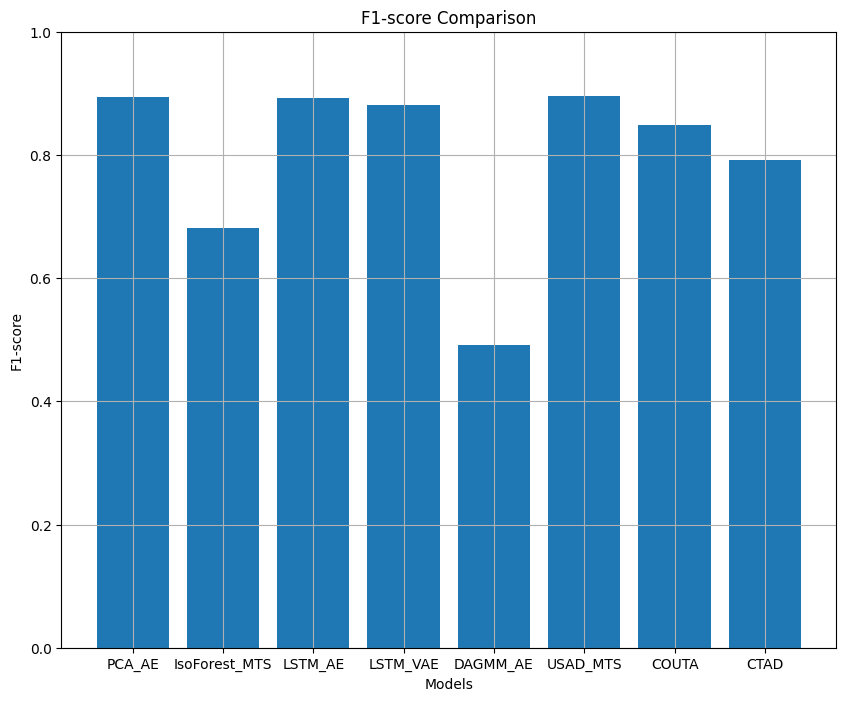

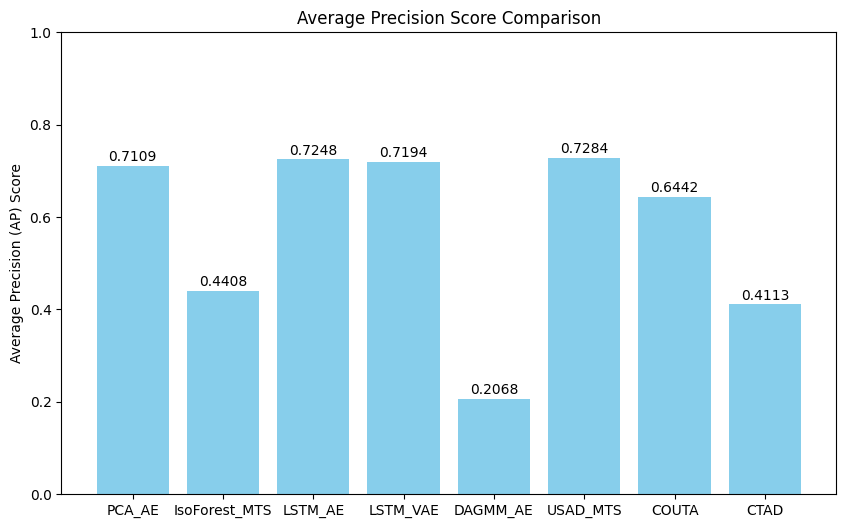

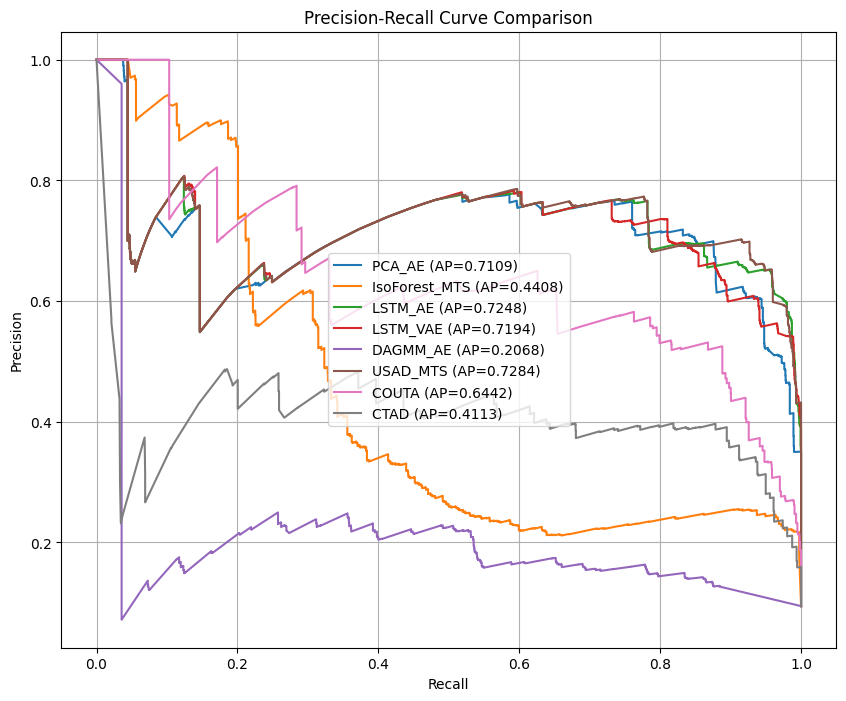

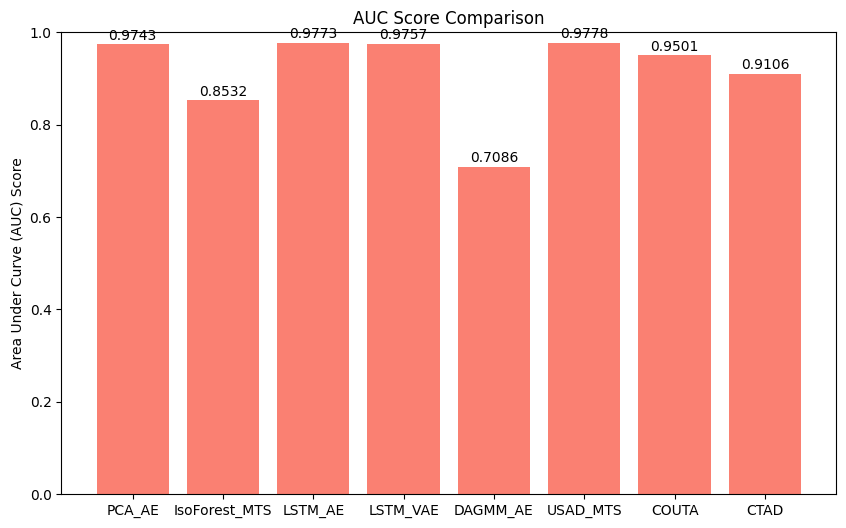

	 Server 1 - Machine 5
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.557482 | Val Loss: 0.791830
Epoch 2
	 Train Loss: 0.480534 | Val Loss: 0.761772
Epoch 3
	 Train Loss: 0.460100 | Val Loss: 0.738555
Epoch 4
	 Train Loss: 0.449657 | Val Loss: 0.723593
Epoch 5
	 Train Loss: 0.441501 | Val Loss: 0.705446
Epoch 6
	 Train Loss: 0.433244 | Val Loss: 0.693826
Epoch 7
	 Train Loss: 0.428850 | Val Loss: 0.694049
Epoch 8
	 Train Loss: 0.426478 | Val Loss: 0.688515
Epoch 9
	 Train Loss: 0.422318 | Val Loss: 0.685033
Epoch 10
	 Train Loss: 0.420062 | Val Loss: 0.682601
Epoch 11
	 Train Loss: 0.418463 | Val Loss: 0.680577
Epoch 12
	 Train Loss: 0.415767 | Val Loss: 0.674115
Epoch 13
	 Train Loss: 0.413784 | Val Loss: 0.673277
Epoch 14
	 Train Loss: 0.411799 | Val Loss: 0.674604
Epoch 15
	 Train Loss: 0.409982 | Val Loss: 0.672724
Epoch 16
	 Train Loss: 0.408070 | Val Loss: 0.666509
Epoch 17
	 Train Loss: 0.407333 | Val Loss: 0.667953
Epoch 18
	 Train Los

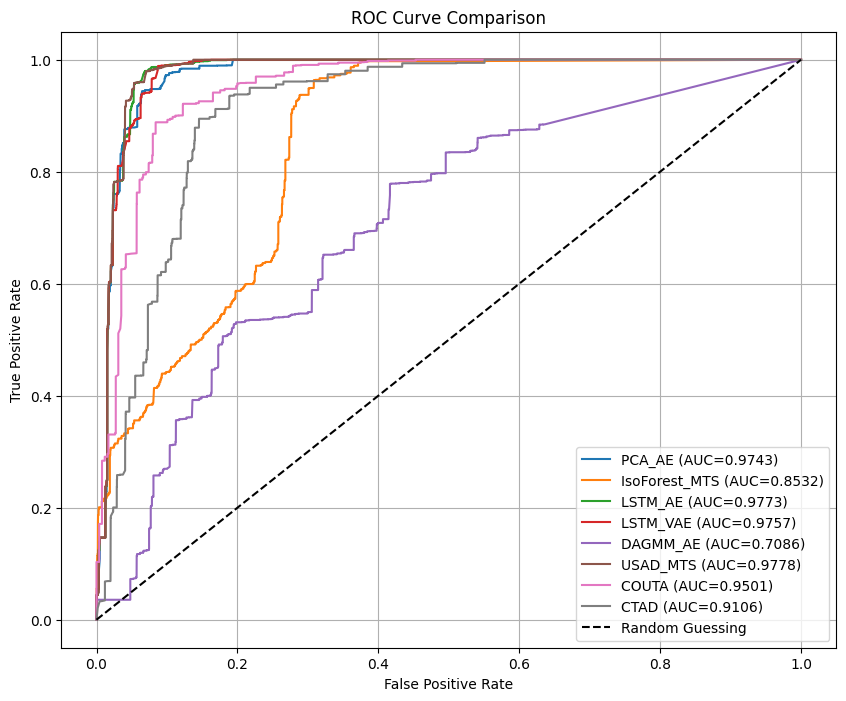

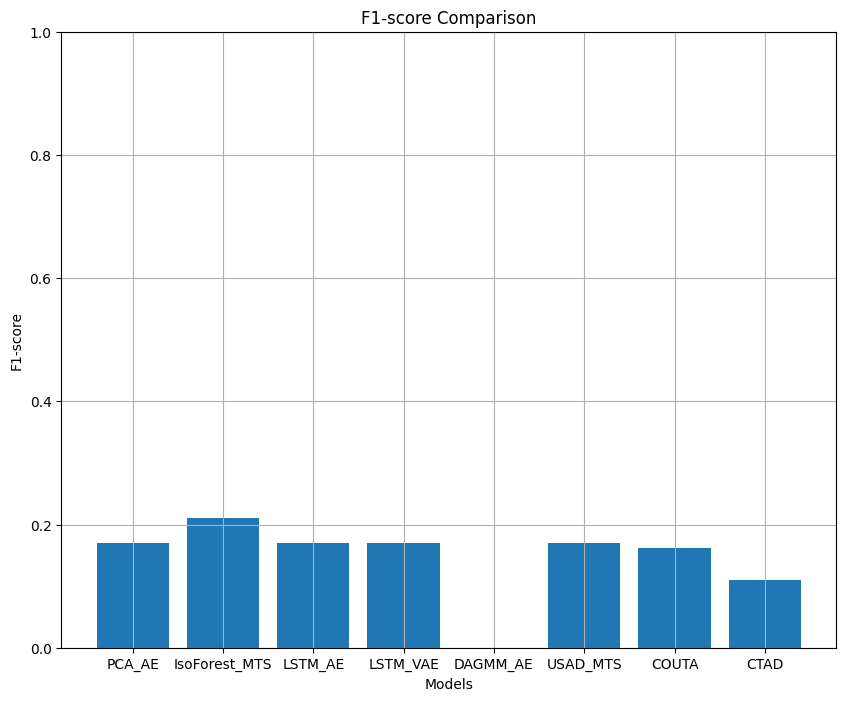

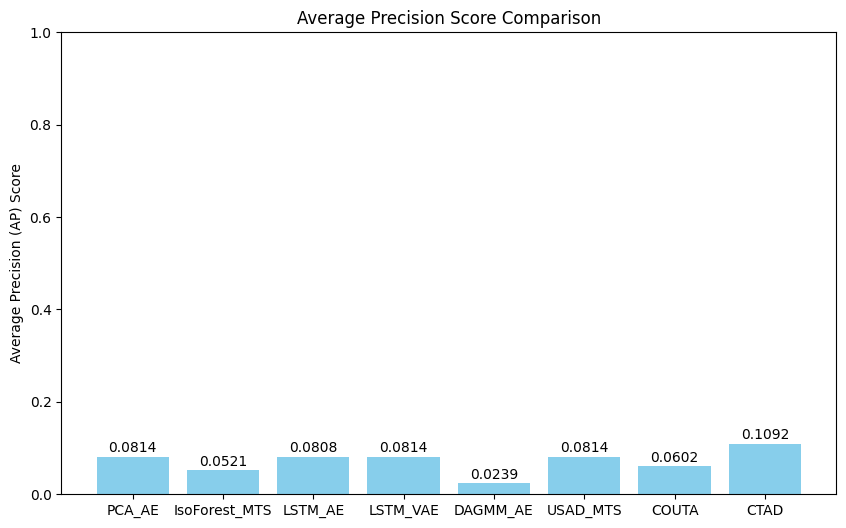

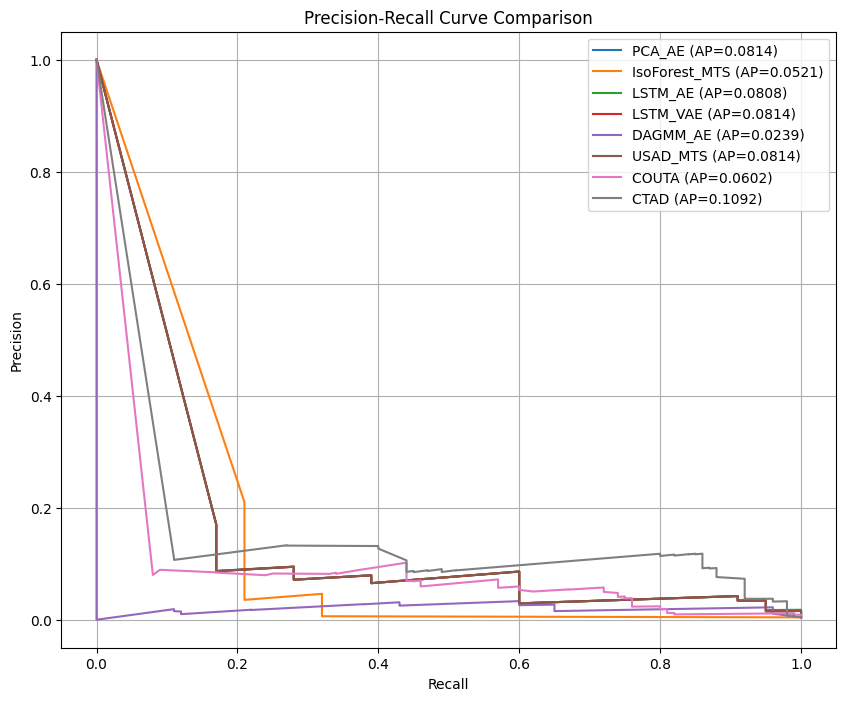

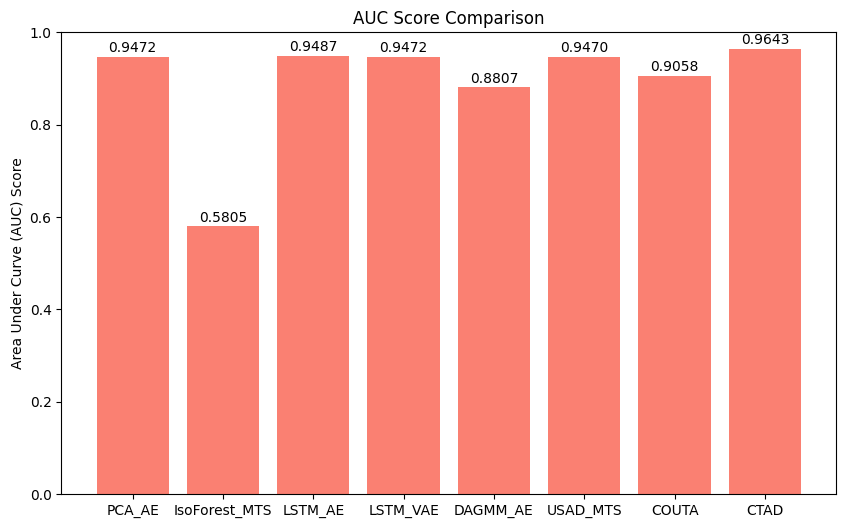

	 Server 2 - Machine 3
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.793779 | Val Loss: 0.230136
Epoch 2
	 Train Loss: 0.733221 | Val Loss: 0.225014
Epoch 3
	 Train Loss: 0.709055 | Val Loss: 0.209234
Epoch 4
	 Train Loss: 0.695309 | Val Loss: 0.202910
Epoch 5
	 Train Loss: 0.676676 | Val Loss: 0.200214
Epoch 6
	 Train Loss: 0.659073 | Val Loss: 0.197449
Epoch 7
	 Train Loss: 0.651881 | Val Loss: 0.196627
Epoch 8
	 Train Loss: 0.650218 | Val Loss: 0.192957
Epoch 9
	 Train Loss: 0.622577 | Val Loss: 0.193689
Epoch 10
	 Train Loss: 0.612039 | Val Loss: 0.185004
Epoch 11
	 Train Loss: 0.620598 | Val Loss: 0.192262
Epoch 12
	 Train Loss: 0.599929 | Val Loss: 0.187496
Epoch 13
	 Train Loss: 0.616515 | Val Loss: 0.182450
Epoch 14
	 Train Loss: 0.604854 | Val Loss: 0.180211
Epoch 15
	 Train Loss: 0.576033 | Val Loss: 0.179869
Epoch 16
	 Train Loss: 0.585719 | Val Loss: 0.178225
Epoch 17
	 Train Loss: 0.572096 | Val Loss: 0.173866
Epoch 18
	 Train Los

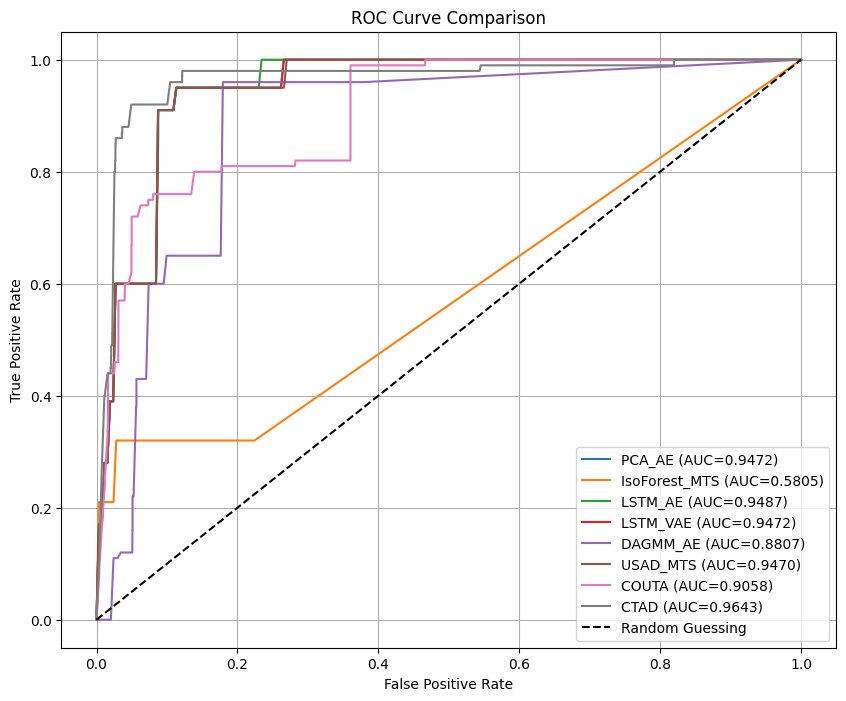

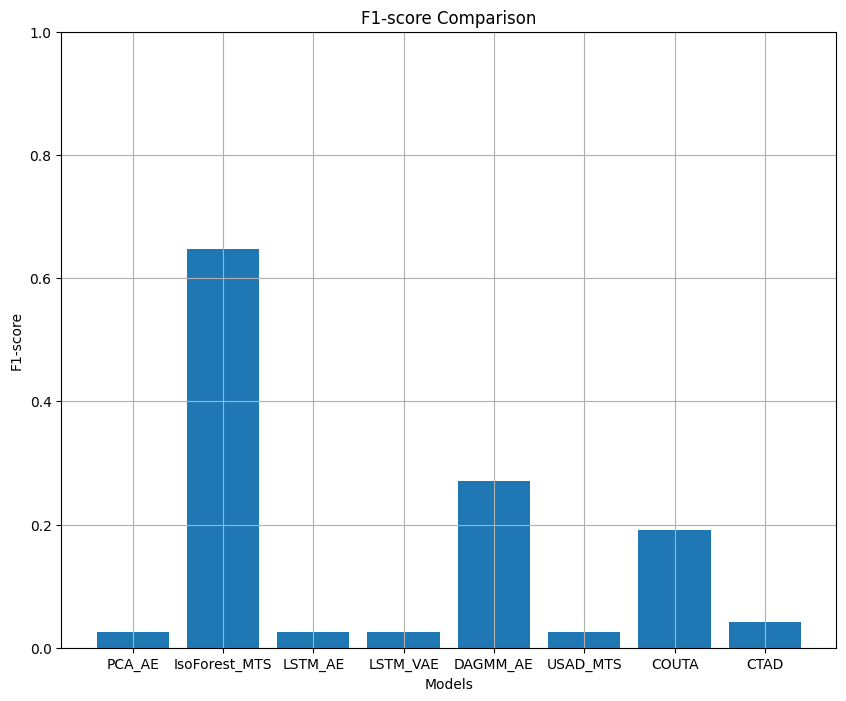

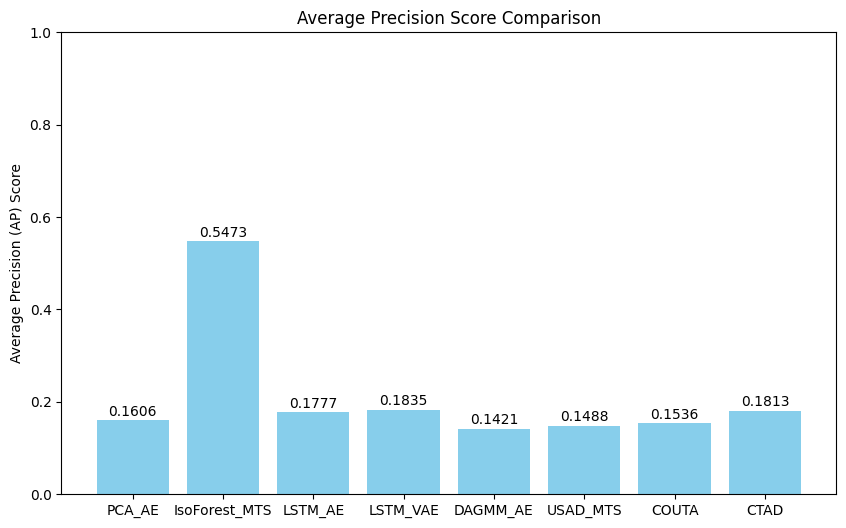

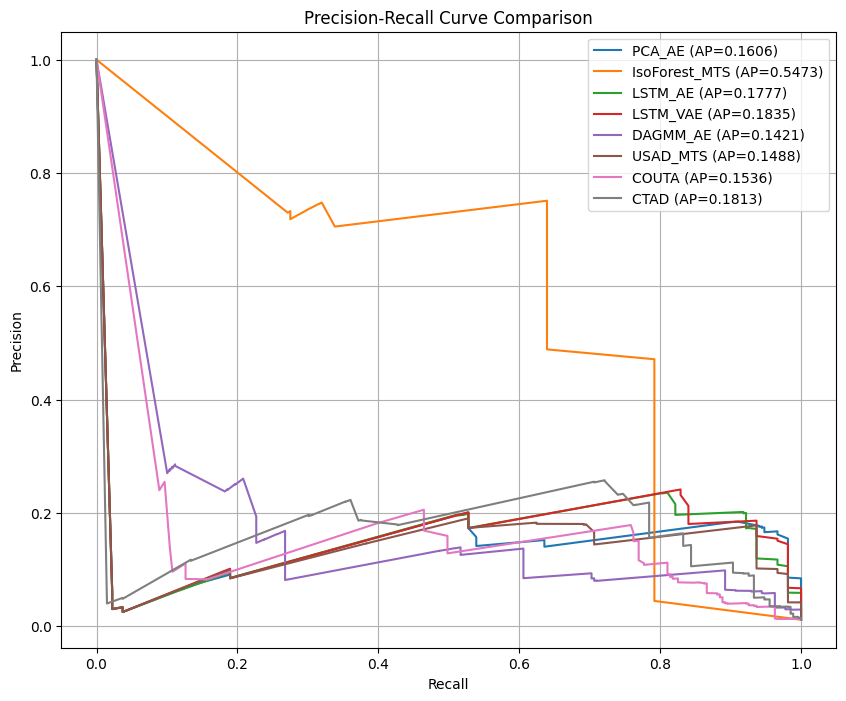

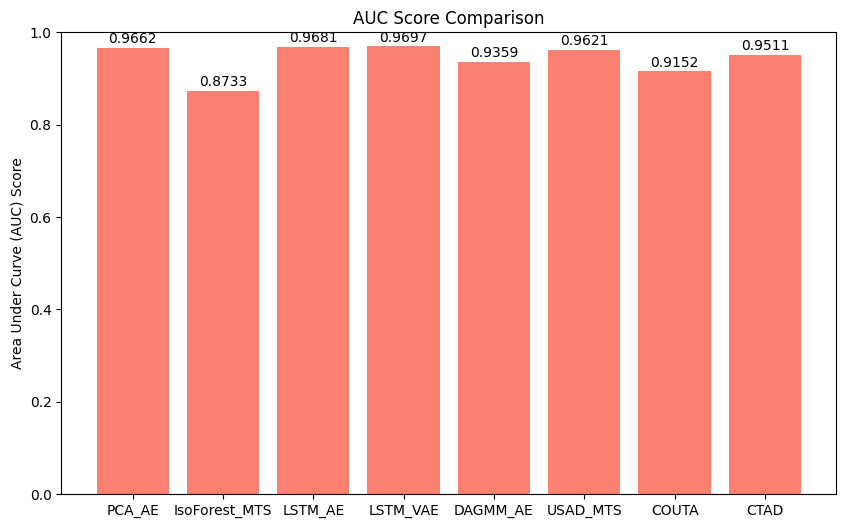

	 Server 2 - Machine 4
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.551655 | Val Loss: 0.435697
Epoch 2
	 Train Loss: 0.479412 | Val Loss: 0.430809
Epoch 3
	 Train Loss: 0.457098 | Val Loss: 0.419948
Epoch 4
	 Train Loss: 0.447923 | Val Loss: 0.419101
Epoch 5
	 Train Loss: 0.442820 | Val Loss: 0.413286
Epoch 6
	 Train Loss: 0.437210 | Val Loss: 0.397326
Epoch 7
	 Train Loss: 0.428851 | Val Loss: 0.379866
Epoch 8
	 Train Loss: 0.424442 | Val Loss: 0.368627
Epoch 9
	 Train Loss: 0.415327 | Val Loss: 0.357544
Epoch 10
	 Train Loss: 0.410824 | Val Loss: 0.345819
Epoch 11
	 Train Loss: 0.404154 | Val Loss: 0.337131
Epoch 12
	 Train Loss: 0.395028 | Val Loss: 0.335304
Epoch 13
	 Train Loss: 0.388795 | Val Loss: 0.331222
Epoch 14
	 Train Loss: 0.383260 | Val Loss: 0.327196
Epoch 15
	 Train Loss: 0.379730 | Val Loss: 0.327995
Epoch 16
	 Train Loss: 0.379678 | Val Loss: 0.332642
Epoch 17
	 Train Loss: 0.374135 | Val Loss: 0.326863
Epoch 18
	 Train Los

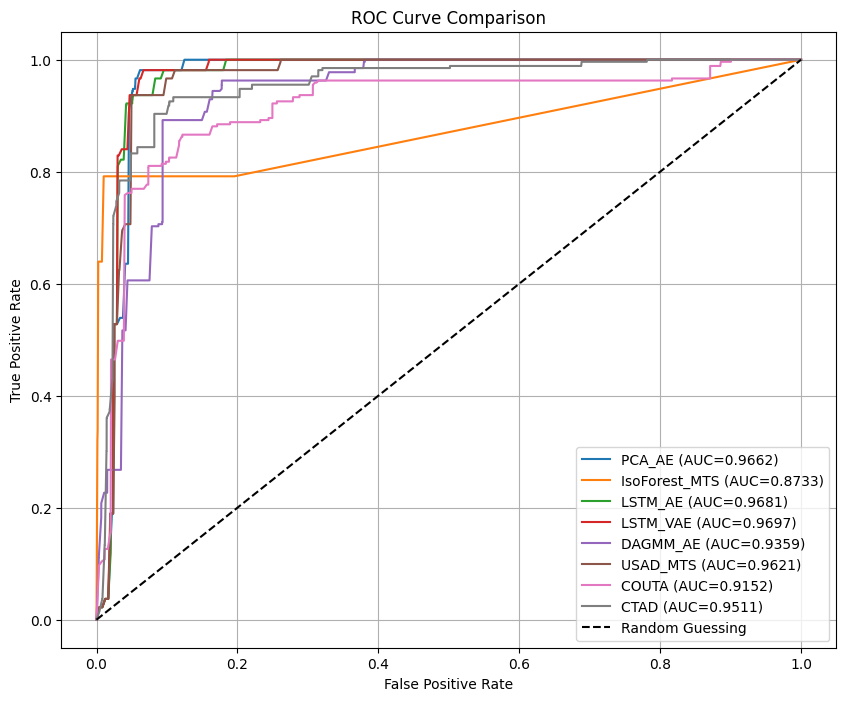

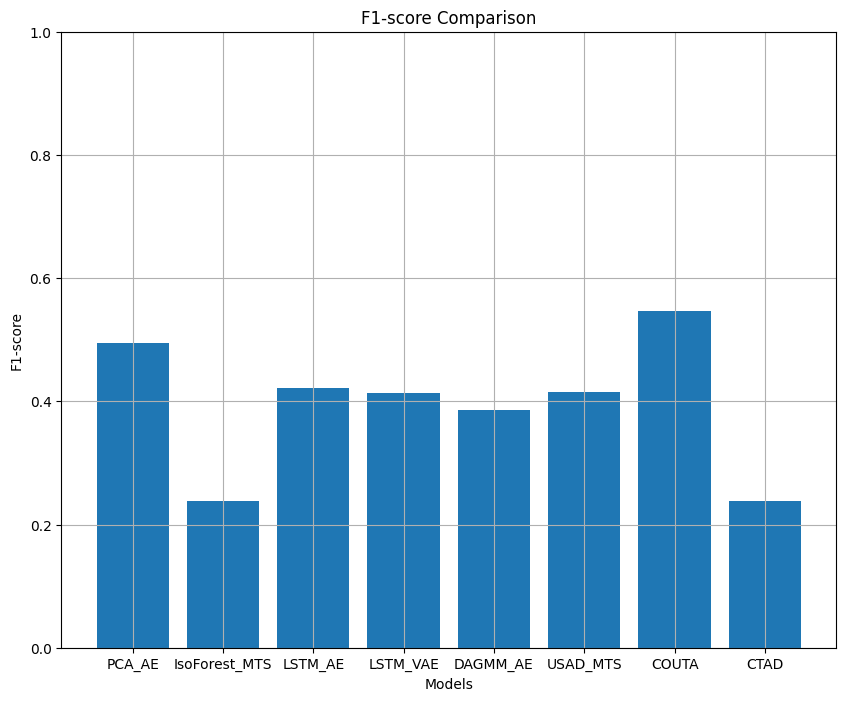

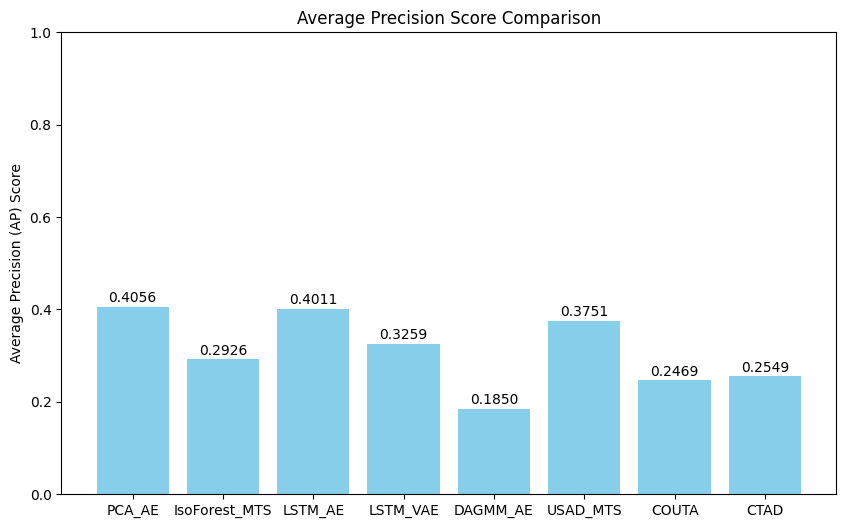

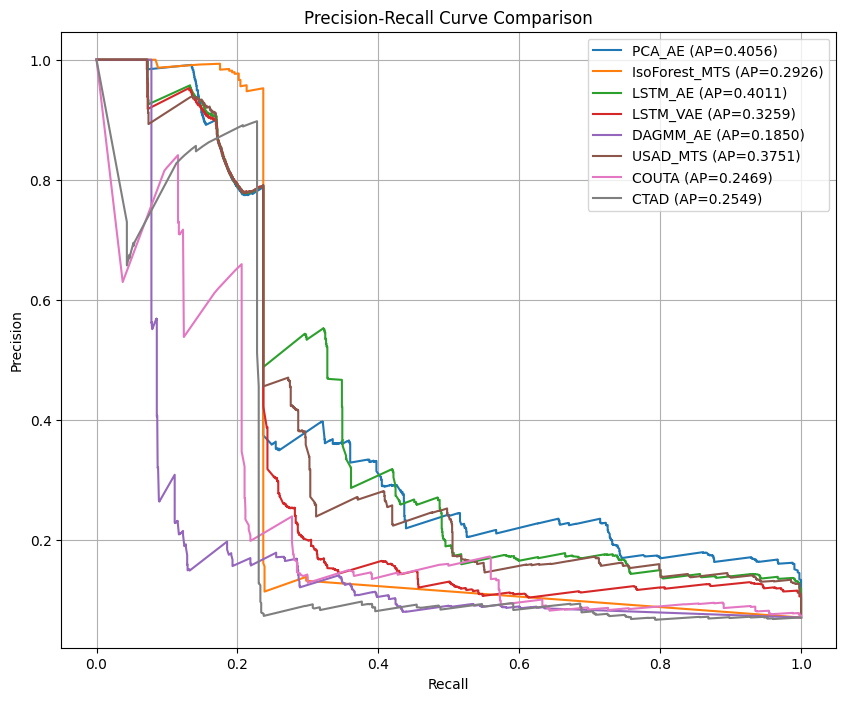

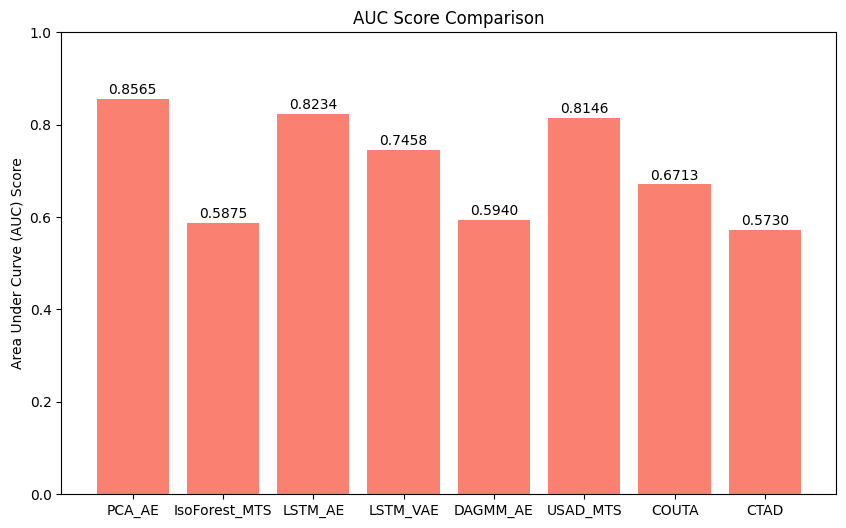

	 Server 3 - Machine 2
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.645330 | Val Loss: 0.972649
Epoch 2
	 Train Loss: 0.621728 | Val Loss: 0.943055
Epoch 3
	 Train Loss: 0.590451 | Val Loss: 0.941845
Epoch 4
	 Train Loss: 0.571461 | Val Loss: 0.968010
Epoch 5
	 Train Loss: 0.562135 | Val Loss: 0.956419
Epoch 6
	 Train Loss: 0.557312 | Val Loss: 0.950892
Epoch 7
	 Train Loss: 0.553213 | Val Loss: 0.957884
Epoch 8
	 Train Loss: 0.550236 | Val Loss: 0.957872
Early stopping ... 
		Training: LSTM_VAE
Epoch 1
	 Train Loss: 0.662540 | Val Loss: 1.023242
Epoch 2
	 Train Loss: 0.678153 | Val Loss: 1.037508
Epoch 3
	 Train Loss: 0.673345 | Val Loss: 1.025667
Epoch 4
	 Train Loss: 0.688309 | Val Loss: 1.061419
Epoch 5
	 Train Loss: 0.704923 | Val Loss: 1.067259
Epoch 6
	 Train Loss: 0.716236 | Val Loss: 1.088883
Early stopping ... 
		Training: DAGMM_AE
Epoch 1 completed.
	 Train Loss: 2789.540283 | Val Loss: 3890.291016
Epoch 2 completed.
	 Train Loss: 

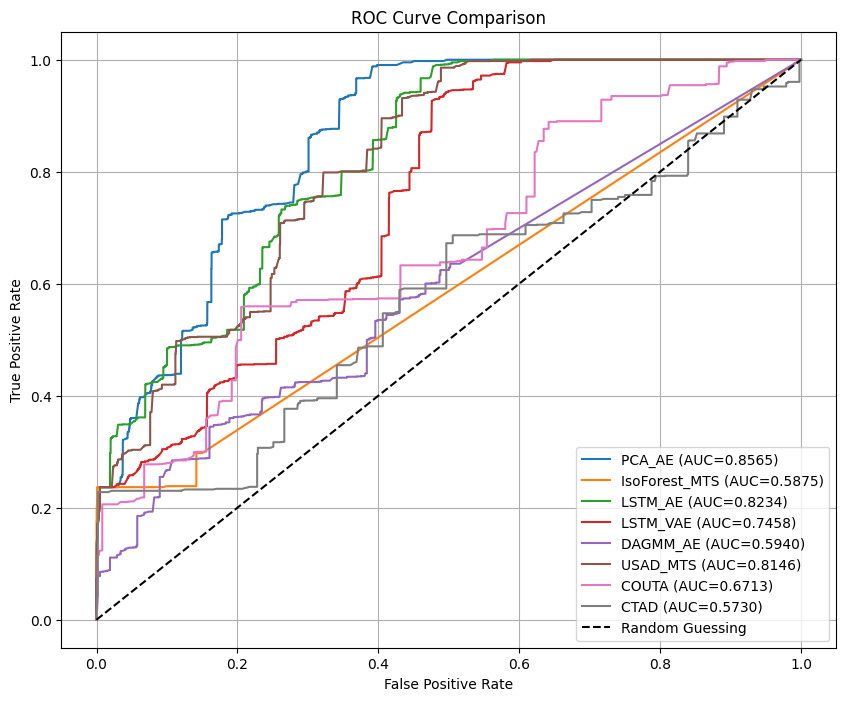

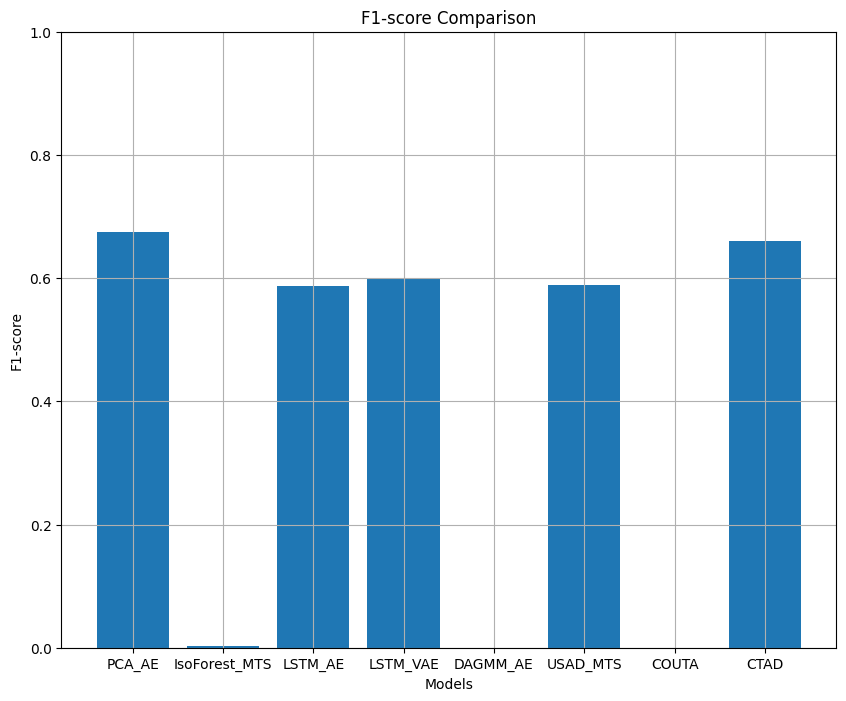

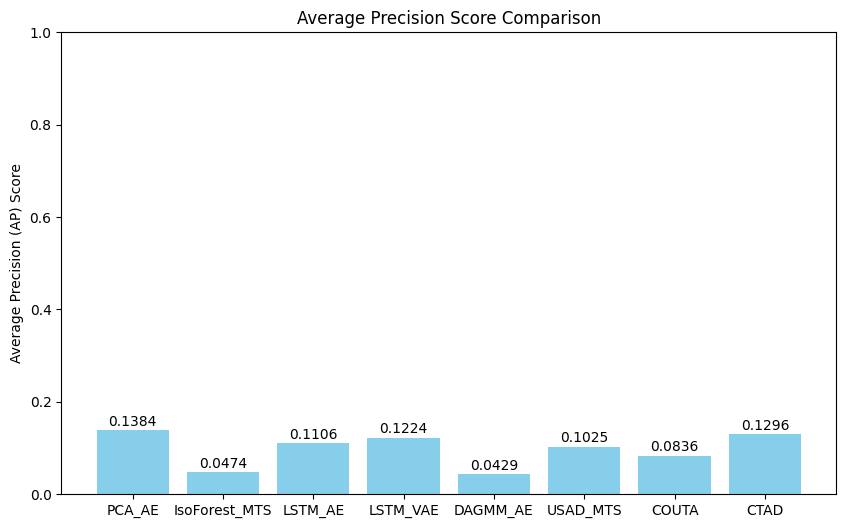

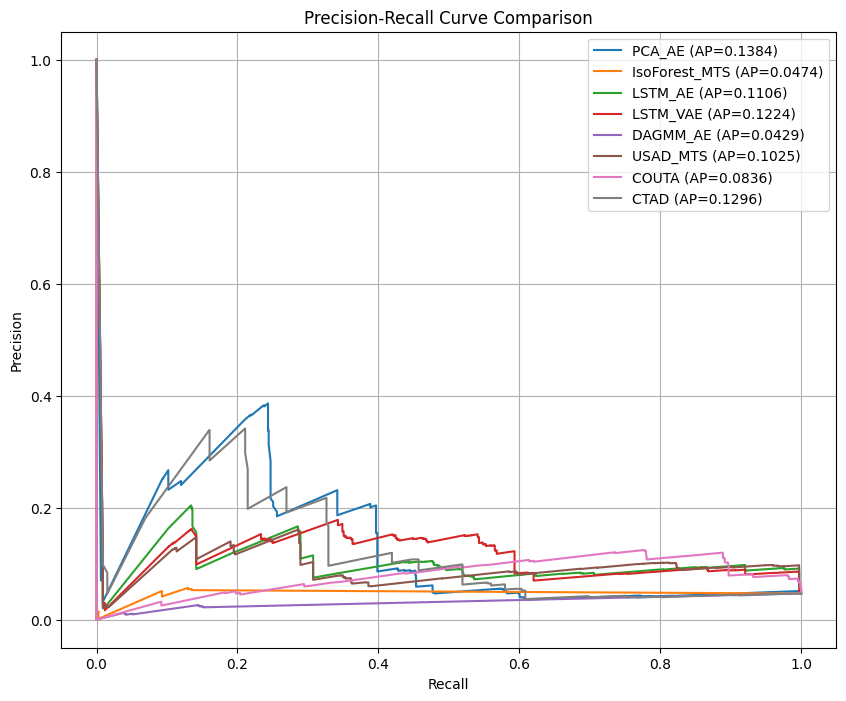

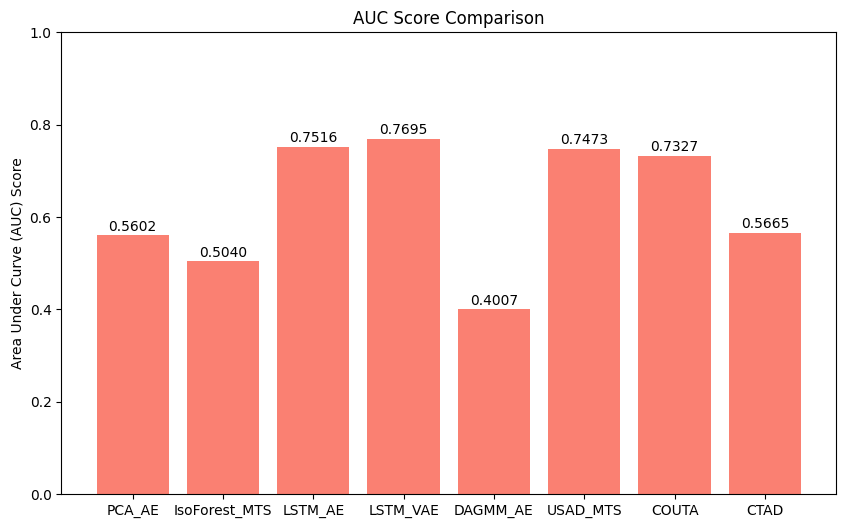

	 Server 3 - Machine 10
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.652309 | Val Loss: 0.283378
Epoch 2
	 Train Loss: 0.537245 | Val Loss: 0.295834
Epoch 3
	 Train Loss: 0.467939 | Val Loss: 0.358938
Epoch 4
	 Train Loss: 0.420983 | Val Loss: 0.313775
Epoch 5
	 Train Loss: 0.394051 | Val Loss: 0.298138
Epoch 6
	 Train Loss: 0.372916 | Val Loss: 0.254453
Epoch 7
	 Train Loss: 0.361082 | Val Loss: 0.262520
Epoch 8
	 Train Loss: 0.352147 | Val Loss: 0.212773
Epoch 9
	 Train Loss: 0.345111 | Val Loss: 0.193775
Epoch 10
	 Train Loss: 0.341914 | Val Loss: 0.186556
Epoch 11
	 Train Loss: 0.338716 | Val Loss: 0.177346
Epoch 12
	 Train Loss: 0.334404 | Val Loss: 0.172418
Epoch 13
	 Train Loss: 0.330199 | Val Loss: 0.168655
Epoch 14
	 Train Loss: 0.327782 | Val Loss: 0.161459
Epoch 15
	 Train Loss: 0.324143 | Val Loss: 0.154115
Epoch 16
	 Train Loss: 0.321925 | Val Loss: 0.149905
Epoch 17
	 Train Loss: 0.318539 | Val Loss: 0.148953
Epoch 18
	 Train Lo

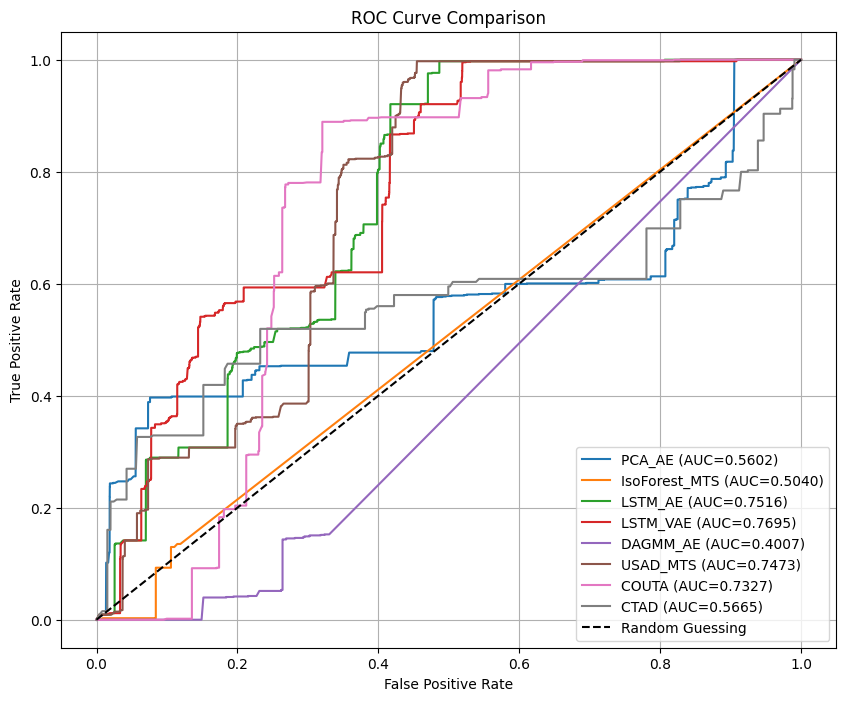

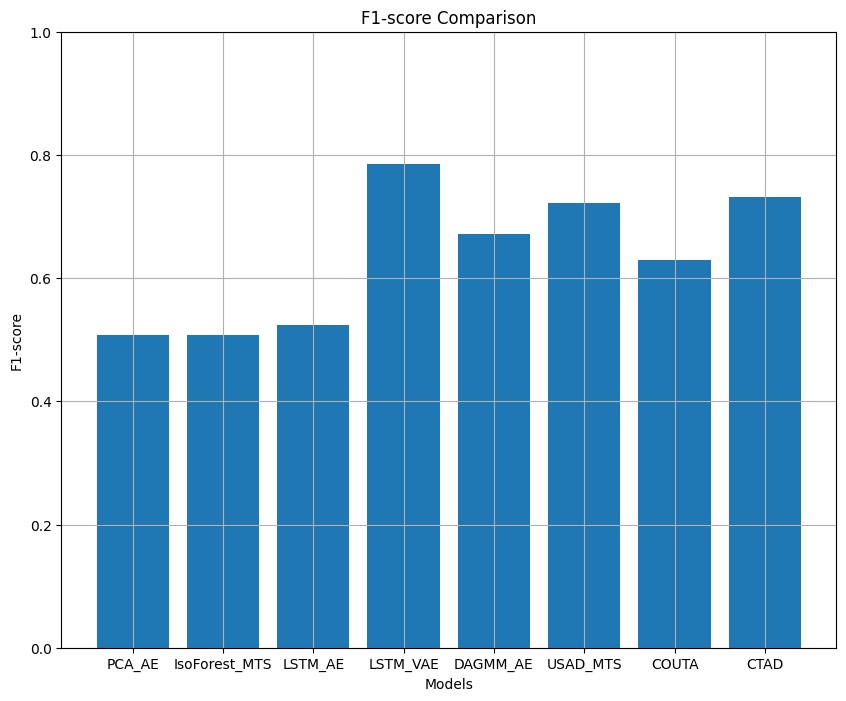

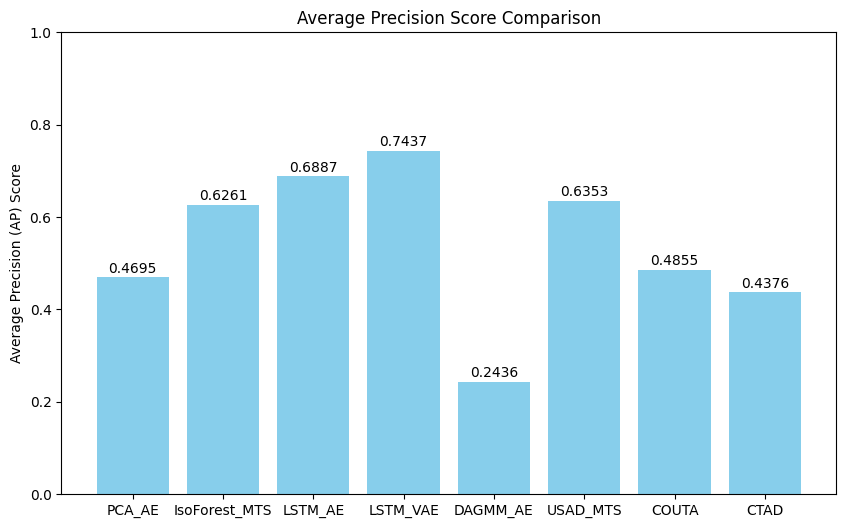

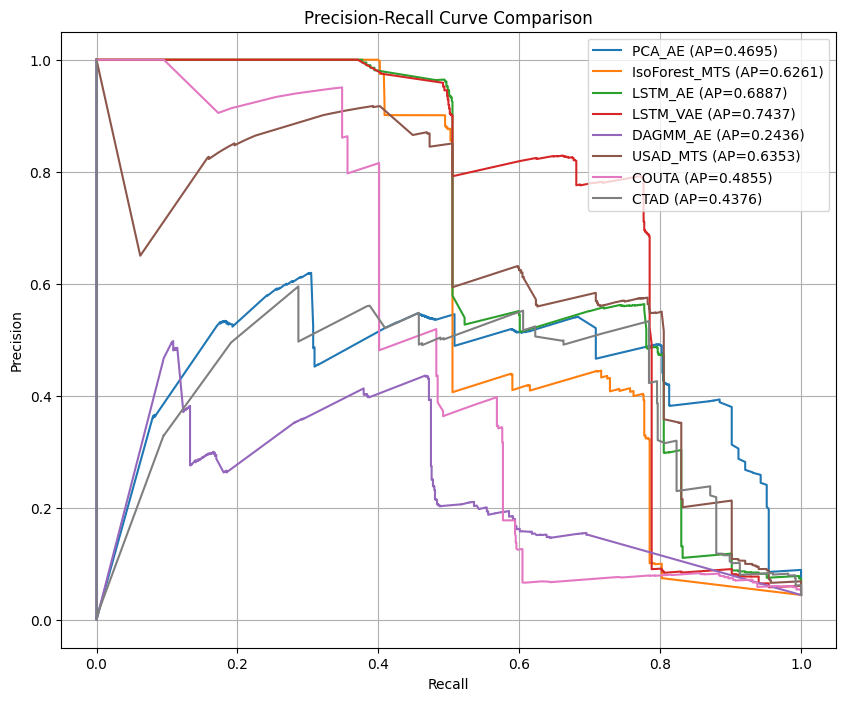

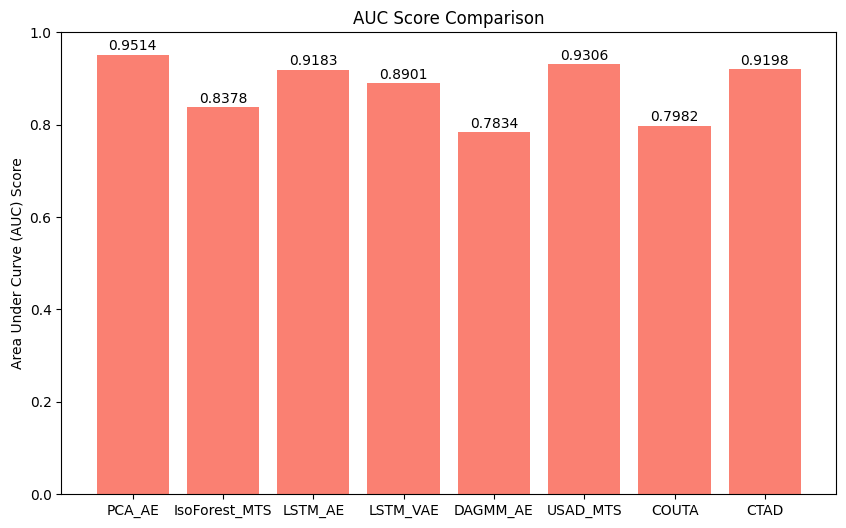

Testing models on PSM dataset:
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.293903 | Val Loss: 0.473324
Epoch 2
	 Train Loss: 0.226661 | Val Loss: 0.461061
Epoch 3
	 Train Loss: 0.206626 | Val Loss: 0.441655
Epoch 4
	 Train Loss: 0.193773 | Val Loss: 0.422857
Epoch 5
	 Train Loss: 0.185054 | Val Loss: 0.397756
Epoch 6
	 Train Loss: 0.175849 | Val Loss: 0.394871
Epoch 7
	 Train Loss: 0.170527 | Val Loss: 0.368472
Epoch 8
	 Train Loss: 0.162651 | Val Loss: 0.367582
Epoch 9
	 Train Loss: 0.158462 | Val Loss: 0.352870
Epoch 10
	 Train Loss: 0.154982 | Val Loss: 0.355810
Epoch 11
	 Train Loss: 0.154617 | Val Loss: 0.340411
Epoch 12
	 Train Loss: 0.149635 | Val Loss: 0.337763
Epoch 13
	 Train Loss: 0.147290 | Val Loss: 0.329945
Epoch 14
	 Train Loss: 0.145903 | Val Loss: 0.323945
Epoch 15
	 Train Loss: 0.143101 | Val Loss: 0.320112
Epoch 16
	 Train Loss: 0.141646 | Val Loss: 0.312022
Epoch 17
	 Train Loss: 0.139468 | Val Loss: 0.312586
Epoch 18
	 T

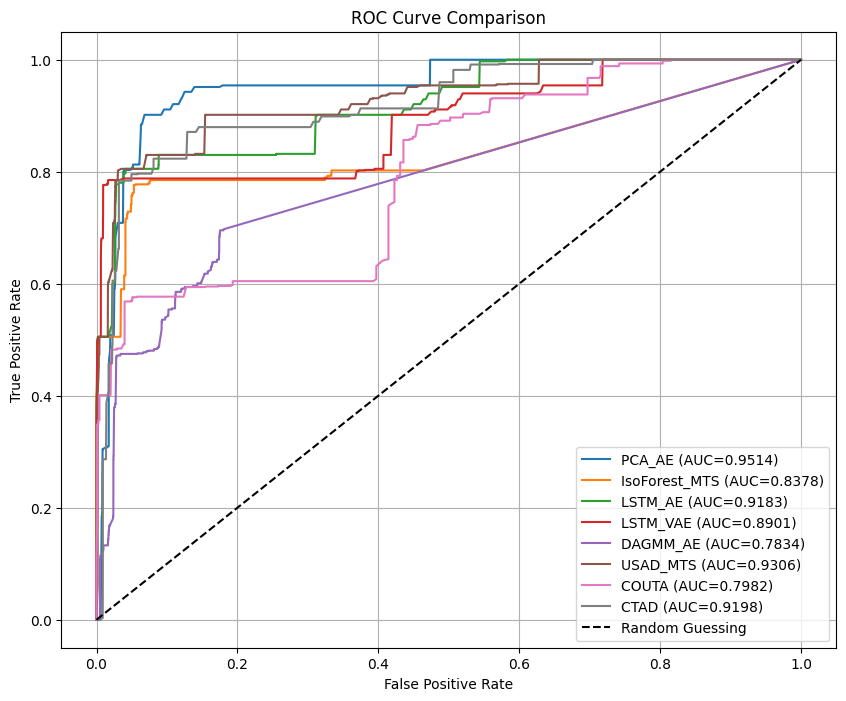

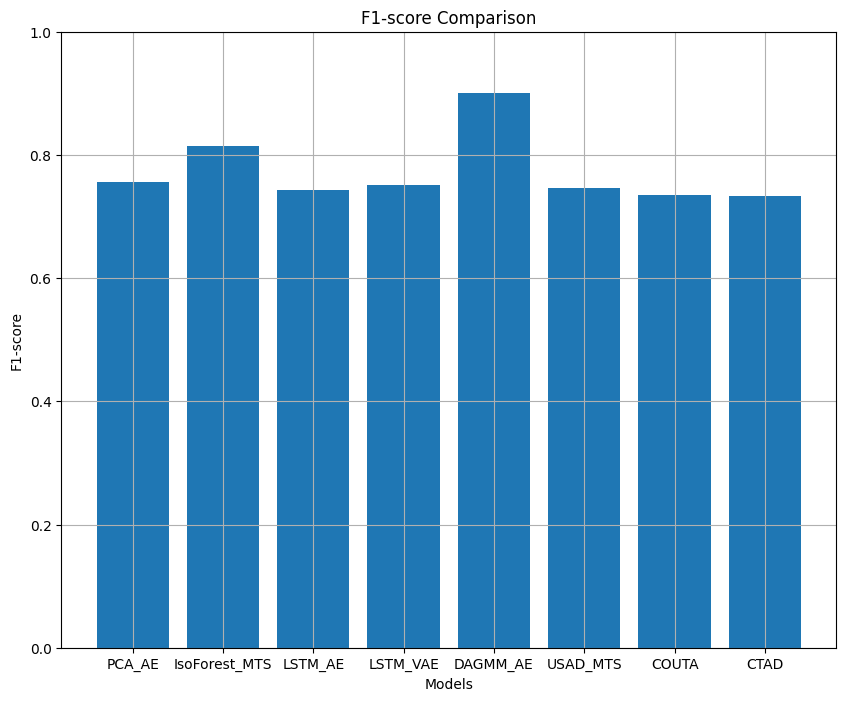

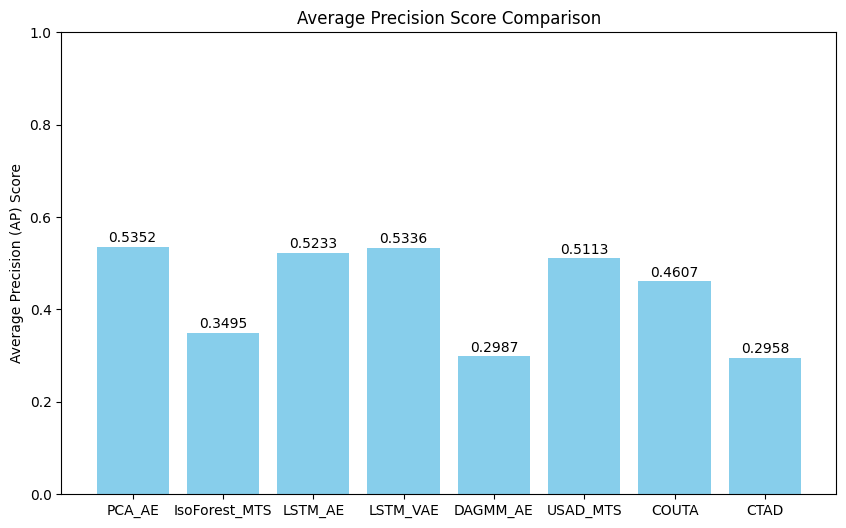

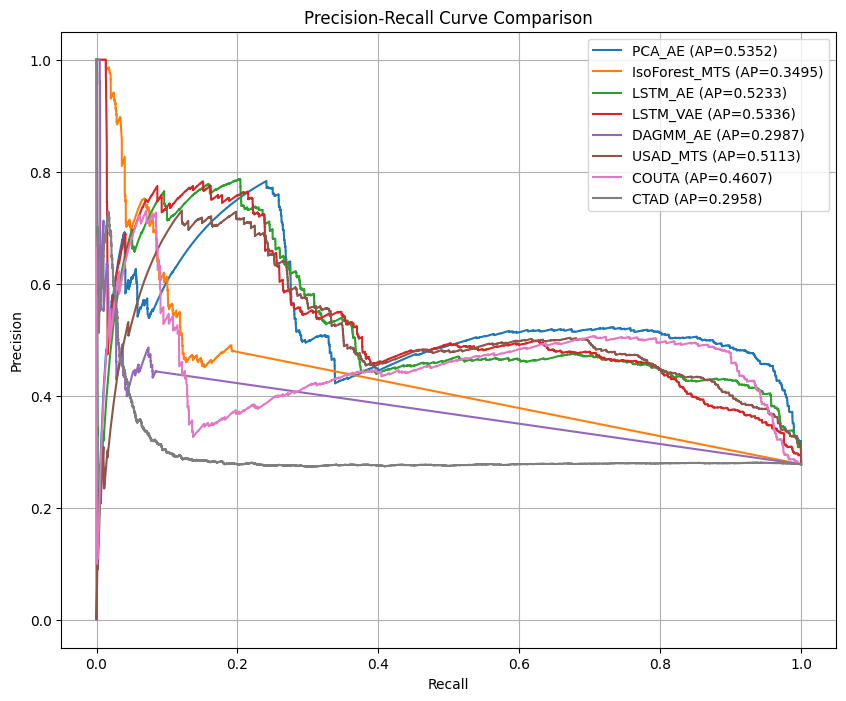

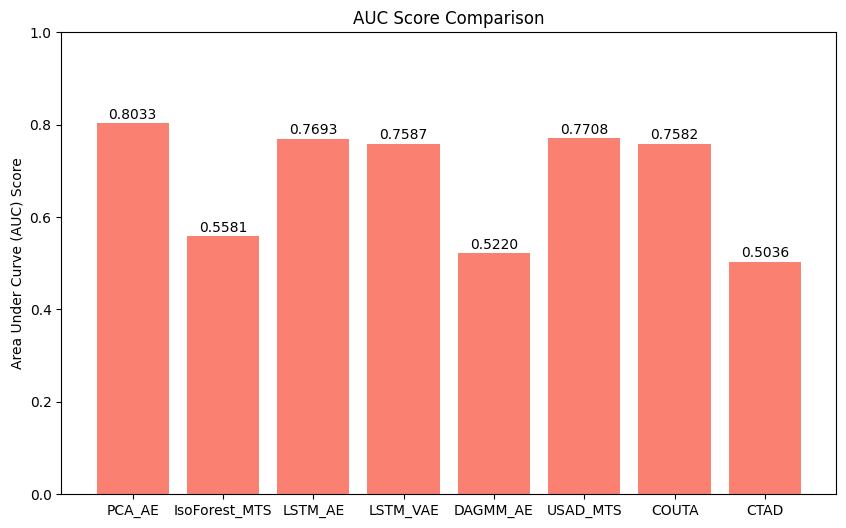

Testing models on SMAP_MSL dataset:
Using window size of 10...
	 Rover A - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.772222 | Val Loss: 0.525822
Epoch 2
	 Train Loss: 0.770581 | Val Loss: 0.521281
Epoch 3
	 Train Loss: 0.770915 | Val Loss: 0.516231
Epoch 4
	 Train Loss: 0.761415 | Val Loss: 0.512630
Epoch 5
	 Train Loss: 0.761030 | Val Loss: 0.509393
Epoch 6
	 Train Loss: 0.759506 | Val Loss: 0.505649
Epoch 7
	 Train Loss: 0.753711 | Val Loss: 0.501871
Epoch 8
	 Train Loss: 0.746579 | Val Loss: 0.499583
Epoch 9
	 Train Loss: 0.746376 | Val Loss: 0.497082
Epoch 10
	 Train Loss: 0.744797 | Val Loss: 0.495176
Epoch 11
	 Train Loss: 0.736361 | Val Loss: 0.493958
Epoch 12
	 Train Loss: 0.743828 | Val Loss: 0.491729
Epoch 13
	 Train Loss: 0.740101 | Val Loss: 0.490452
Epoch 14
	 Train Loss: 0.740315 | Val Loss: 0.489251
Epoch 15
	 Train Loss: 0.737433 | Val Loss: 0.489132
Epoch 16
	 Train Loss: 0.740461 | Val Loss: 0.489886
Epoch 17
	 T

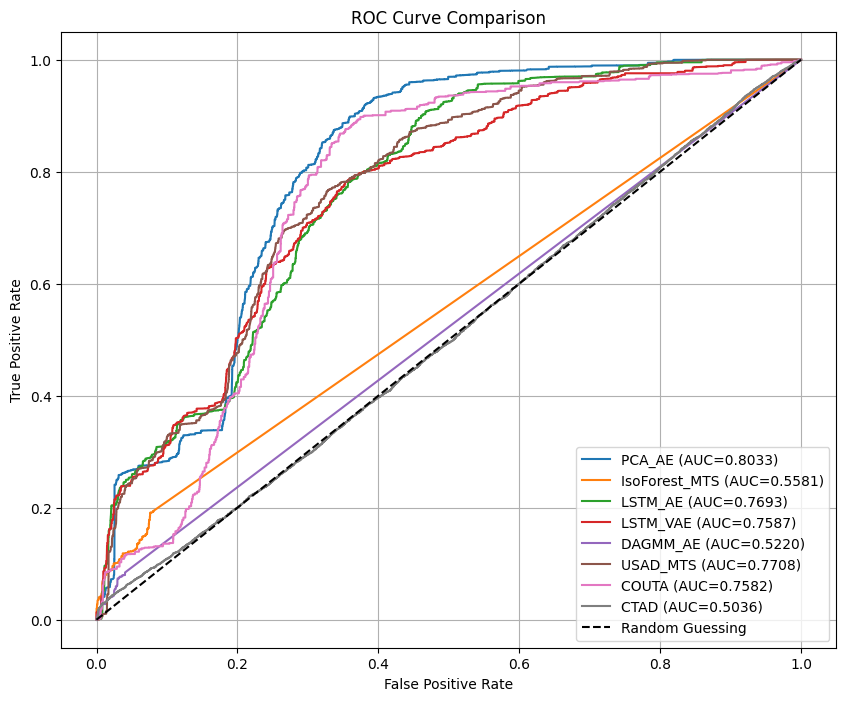

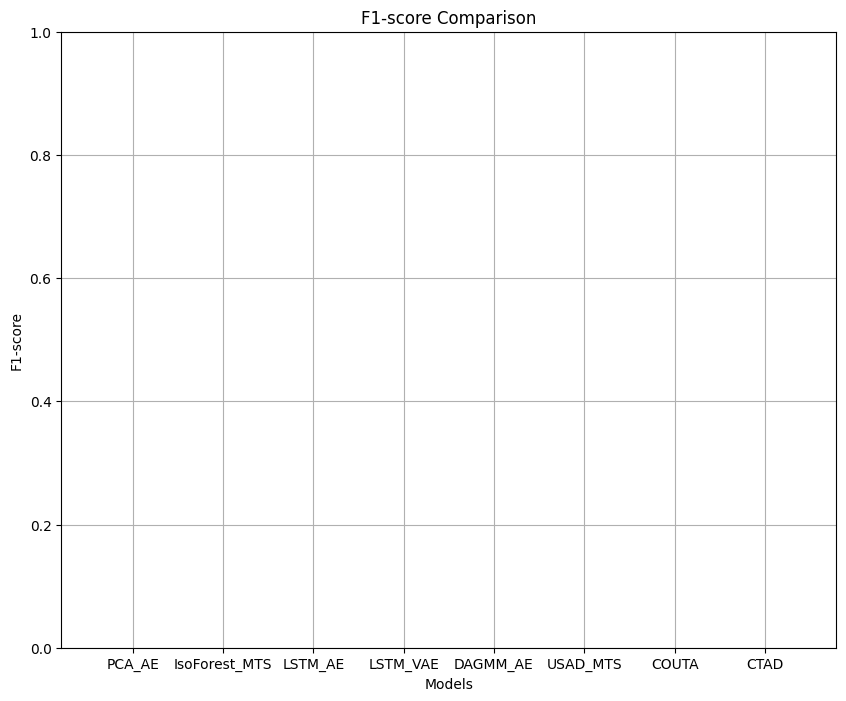

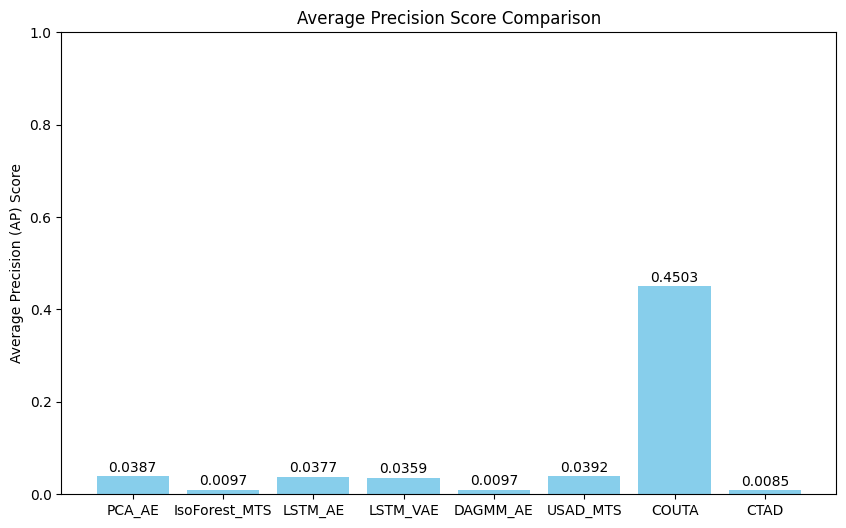

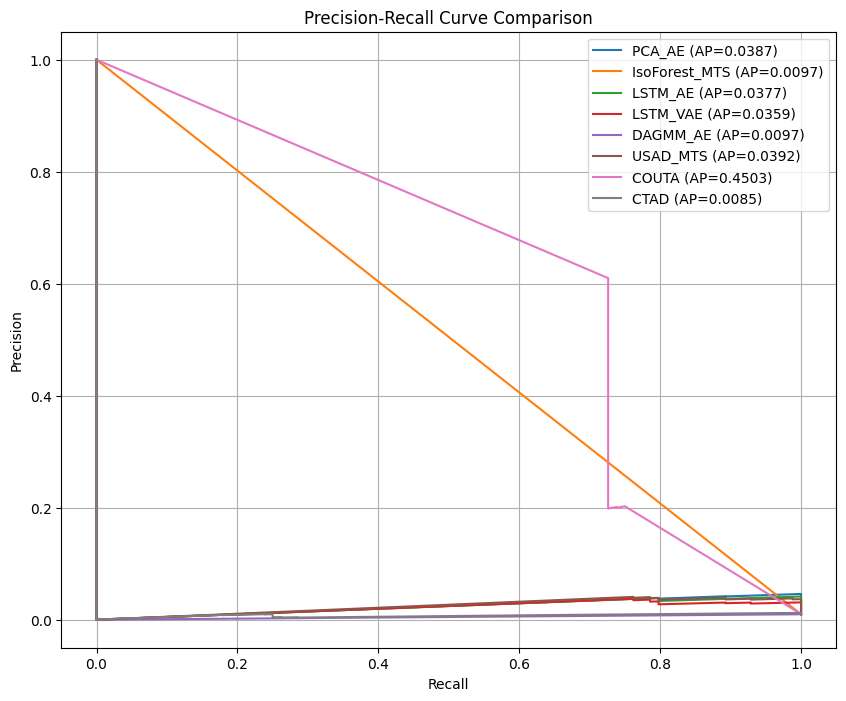

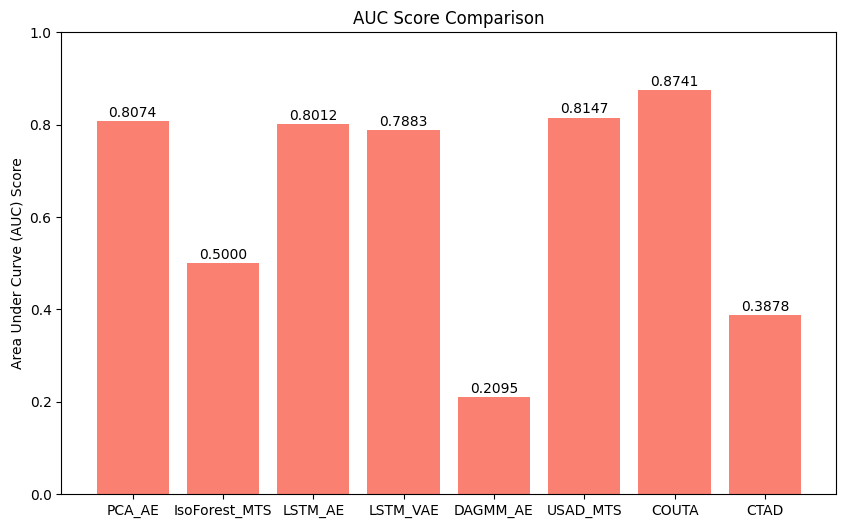

	 Rover B - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.465447 | Val Loss: 0.031664
Epoch 2
	 Train Loss: 0.446607 | Val Loss: 0.028791
Epoch 3
	 Train Loss: 0.438512 | Val Loss: 0.025736
Epoch 4
	 Train Loss: 0.434494 | Val Loss: 0.023442
Epoch 5
	 Train Loss: 0.433362 | Val Loss: 0.021409
Epoch 6
	 Train Loss: 0.426988 | Val Loss: 0.019574
Epoch 7
	 Train Loss: 0.425969 | Val Loss: 0.017931
Epoch 8
	 Train Loss: 0.425896 | Val Loss: 0.016475
Epoch 9
	 Train Loss: 0.426662 | Val Loss: 0.015154
Epoch 10
	 Train Loss: 0.424453 | Val Loss: 0.013983
Epoch 11
	 Train Loss: 0.423795 | Val Loss: 0.012950
Epoch 12
	 Train Loss: 0.419016 | Val Loss: 0.012022
Epoch 13
	 Train Loss: 0.420460 | Val Loss: 0.011218
Epoch 14
	 Train Loss: 0.423636 | Val Loss: 0.010464
Epoch 15
	 Train Loss: 0.422625 | Val Loss: 0.009810
Epoch 16
	 Train Loss: 0.426058 | Val Loss: 0.009199
Epoch 17
	 Train Loss: 0.417525 | Val Loss: 0.008667
Epoch 18
	 Train Loss:

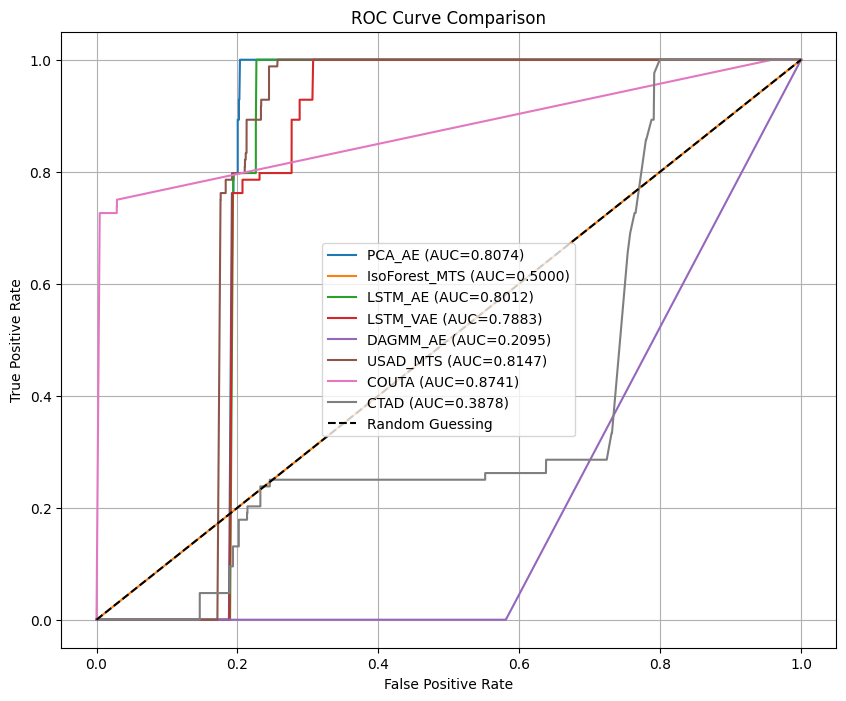

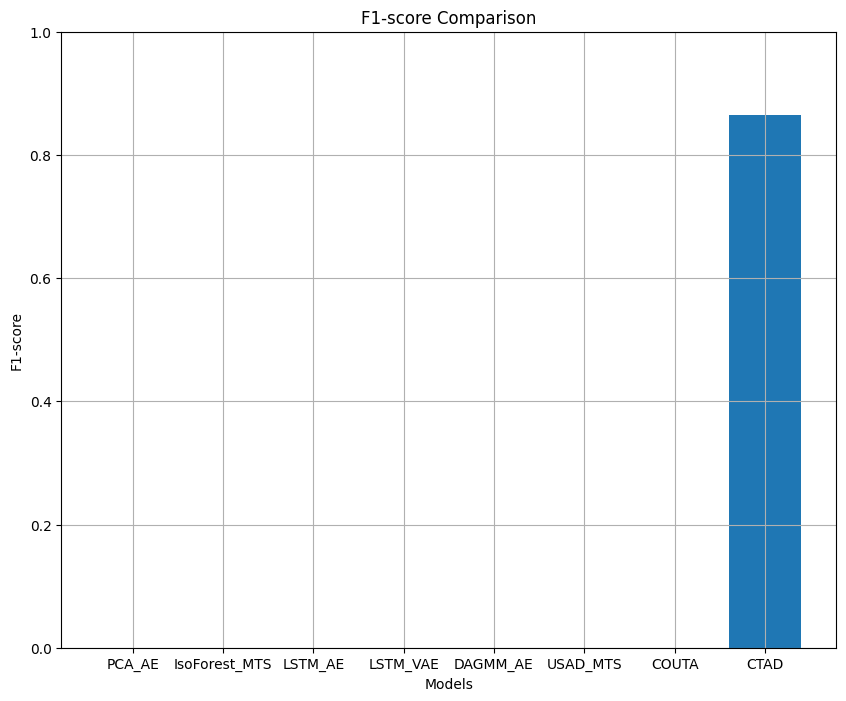

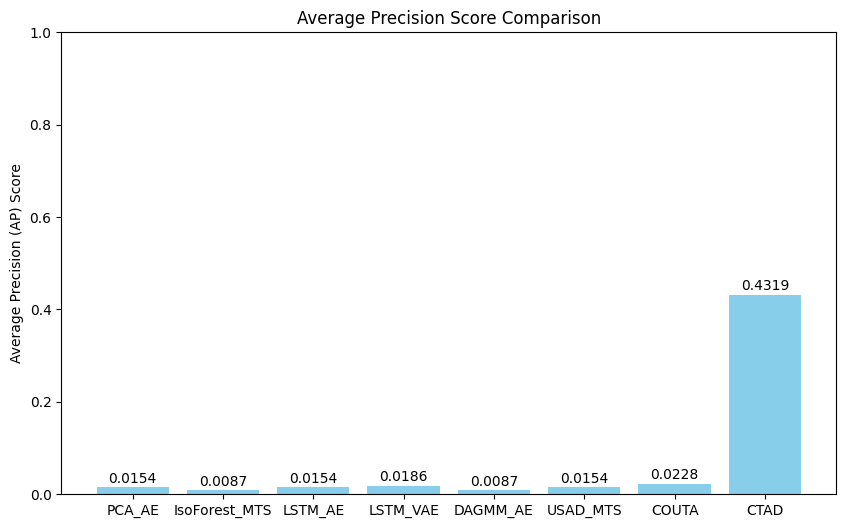

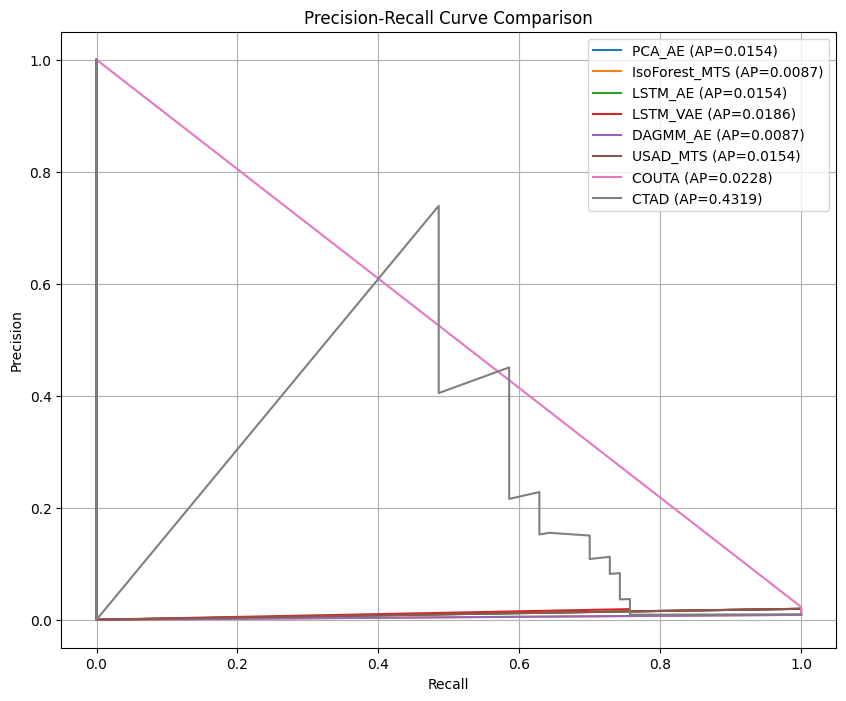

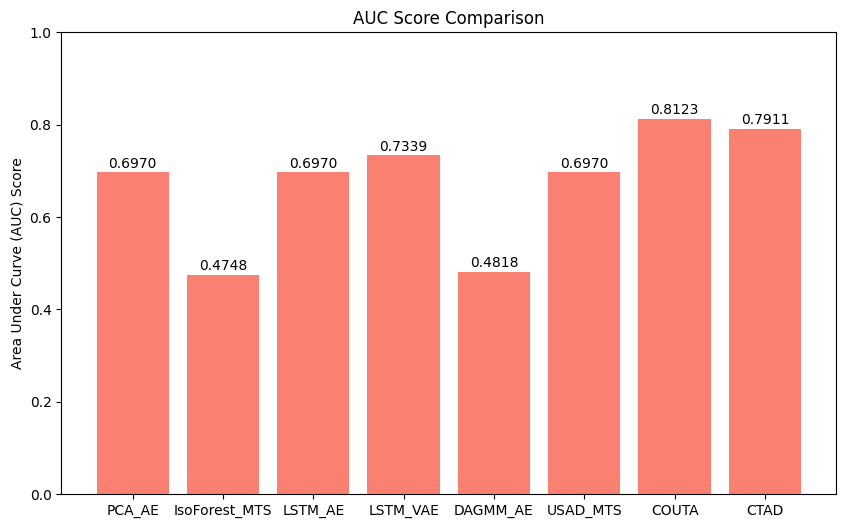

	 Rover C - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.313790 | Val Loss: 0.161457
Epoch 2
	 Train Loss: 0.309733 | Val Loss: 0.156863
Epoch 3
	 Train Loss: 0.305426 | Val Loss: 0.153476
Epoch 4
	 Train Loss: 0.301416 | Val Loss: 0.150311
Epoch 5
	 Train Loss: 0.298101 | Val Loss: 0.147426
Epoch 6
	 Train Loss: 0.296019 | Val Loss: 0.145697
Epoch 7
	 Train Loss: 0.294005 | Val Loss: 0.143789
Epoch 8
	 Train Loss: 0.291887 | Val Loss: 0.142291
Epoch 9
	 Train Loss: 0.290296 | Val Loss: 0.140956
Epoch 10
	 Train Loss: 0.288684 | Val Loss: 0.140012
Epoch 11
	 Train Loss: 0.287668 | Val Loss: 0.138850
Epoch 12
	 Train Loss: 0.285329 | Val Loss: 0.137803
Epoch 13
	 Train Loss: 0.283377 | Val Loss: 0.136482
Epoch 14
	 Train Loss: 0.281383 | Val Loss: 0.135036
Epoch 15
	 Train Loss: 0.279435 | Val Loss: 0.134363
Epoch 16
	 Train Loss: 0.278335 | Val Loss: 0.133420
Epoch 17
	 Train Loss: 0.277062 | Val Loss: 0.132577
Epoch 18
	 Train Loss:

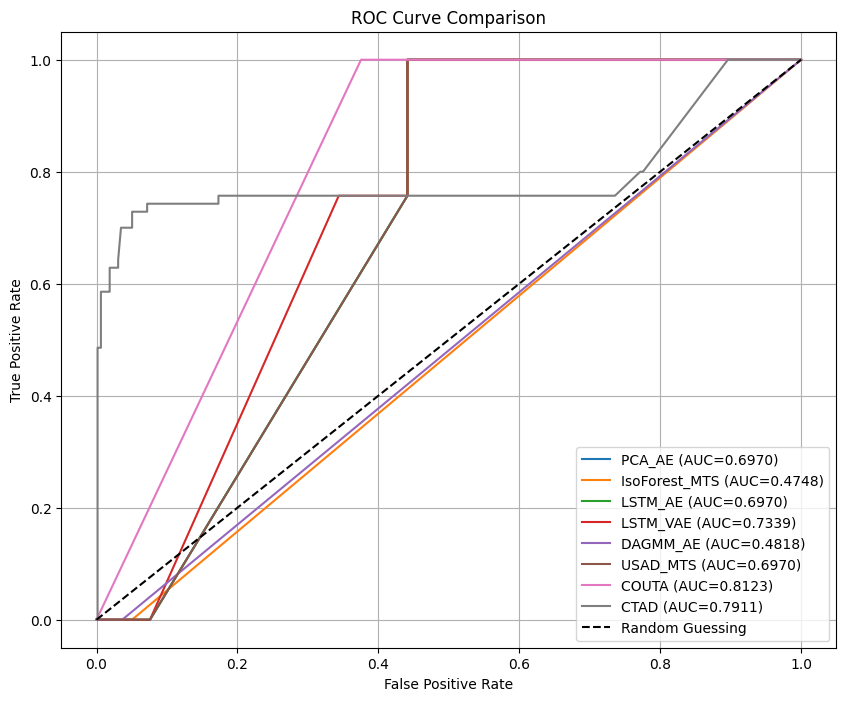

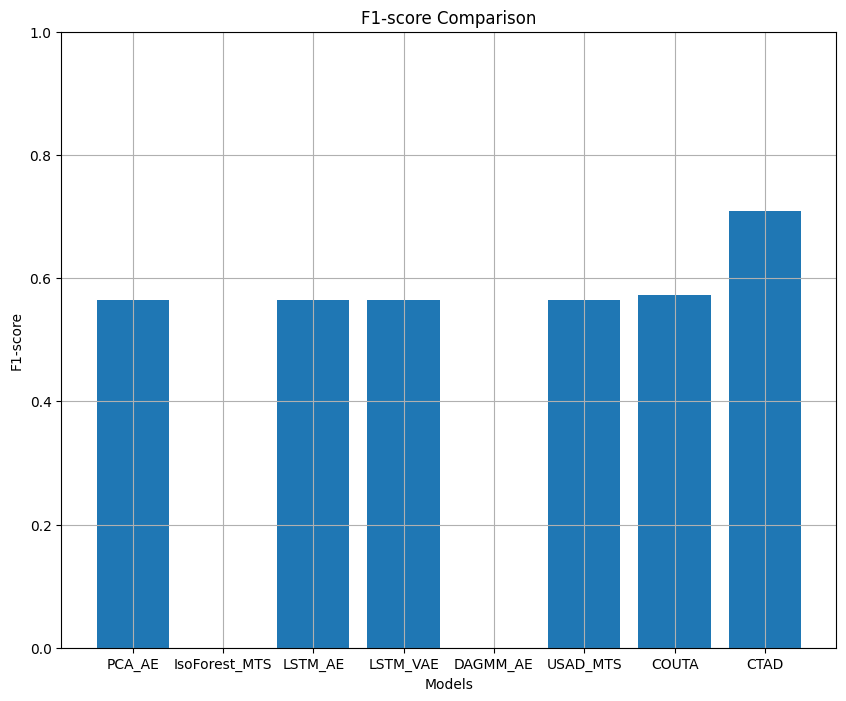

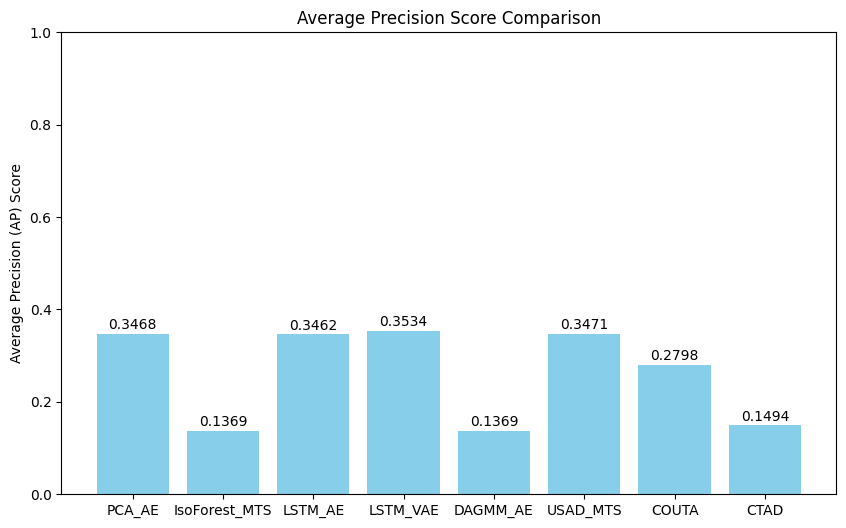

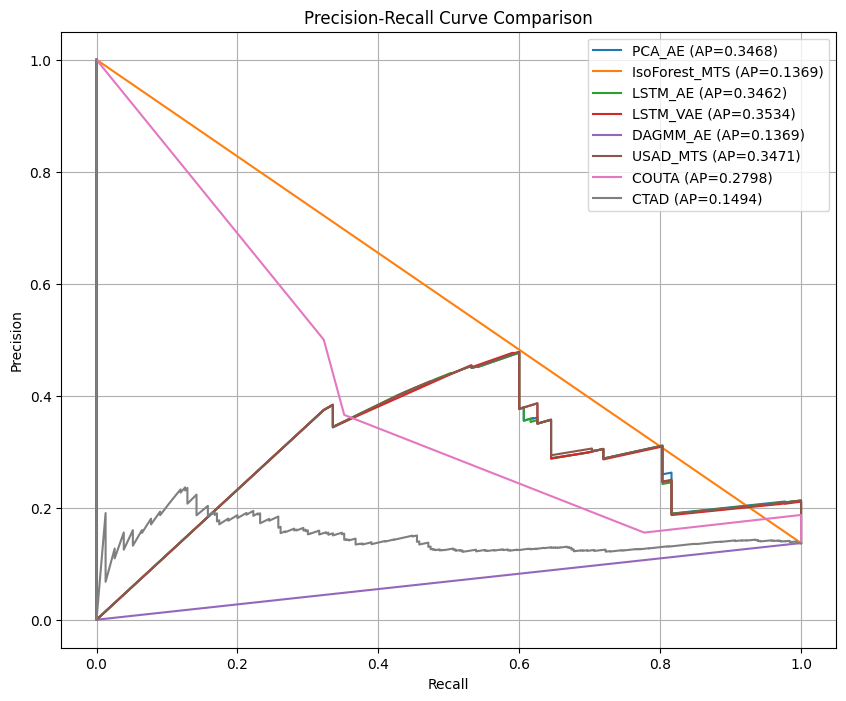

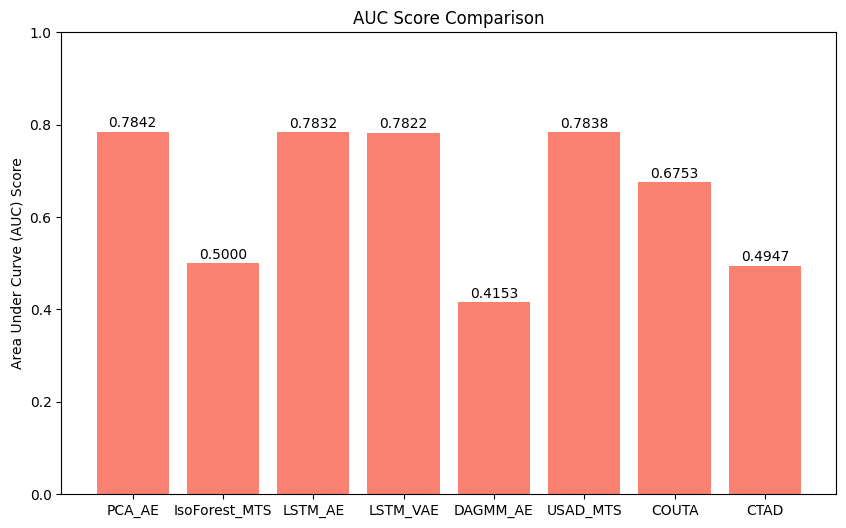

	 Rover D - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.730821 | Val Loss: 0.648718
Epoch 2
	 Train Loss: 0.739426 | Val Loss: 0.638794
Epoch 3
	 Train Loss: 0.715202 | Val Loss: 0.633875
Epoch 4
	 Train Loss: 0.718985 | Val Loss: 0.630362
Epoch 5
	 Train Loss: 0.717973 | Val Loss: 0.627308
Epoch 6
	 Train Loss: 0.708360 | Val Loss: 0.622996
Epoch 7
	 Train Loss: 0.695907 | Val Loss: 0.615250
Epoch 8
	 Train Loss: 0.703022 | Val Loss: 0.611859
Epoch 9
	 Train Loss: 0.695783 | Val Loss: 0.610487
Epoch 10
	 Train Loss: 0.696762 | Val Loss: 0.607157
Epoch 11
	 Train Loss: 0.694349 | Val Loss: 0.601473
Epoch 12
	 Train Loss: 0.682872 | Val Loss: 0.595860
Epoch 13
	 Train Loss: 0.675673 | Val Loss: 0.592612
Epoch 14
	 Train Loss: 0.675316 | Val Loss: 0.591373
Epoch 15
	 Train Loss: 0.673897 | Val Loss: 0.593781
Epoch 16
	 Train Loss: 0.667609 | Val Loss: 0.589079
Epoch 17
	 Train Loss: 0.666962 | Val Loss: 0.584725
Epoch 18
	 Train Loss:

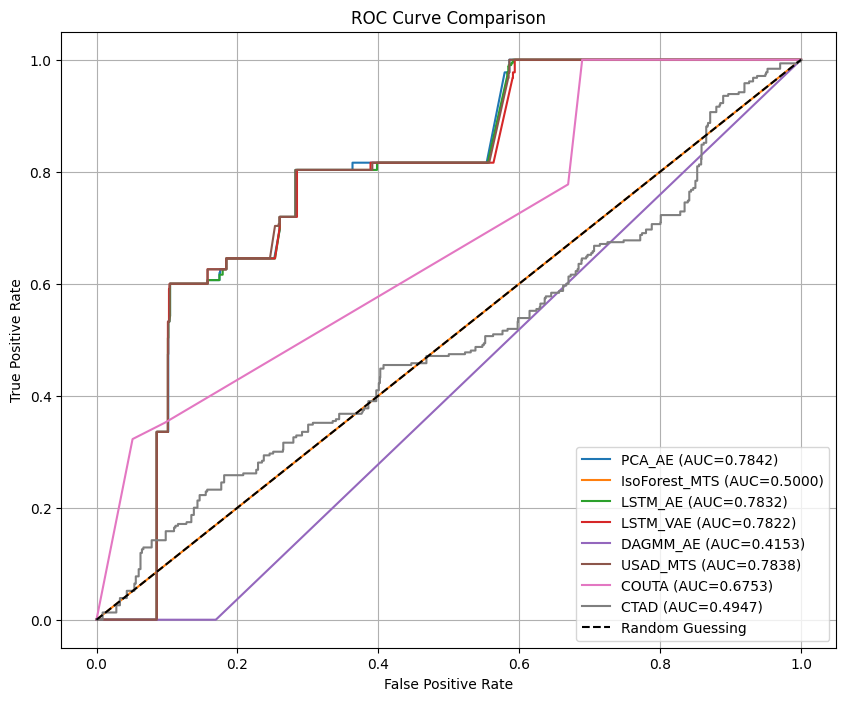

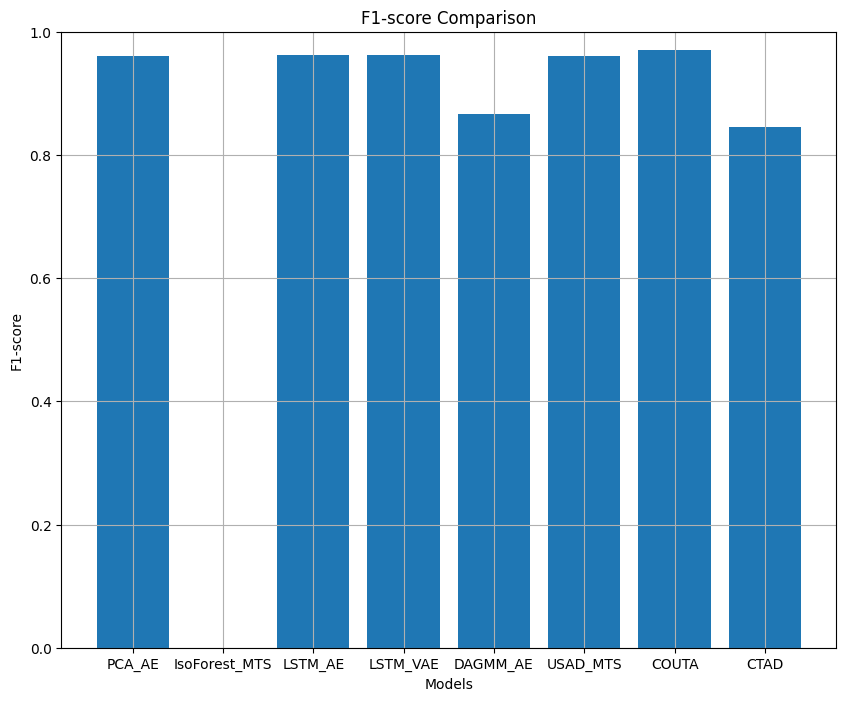

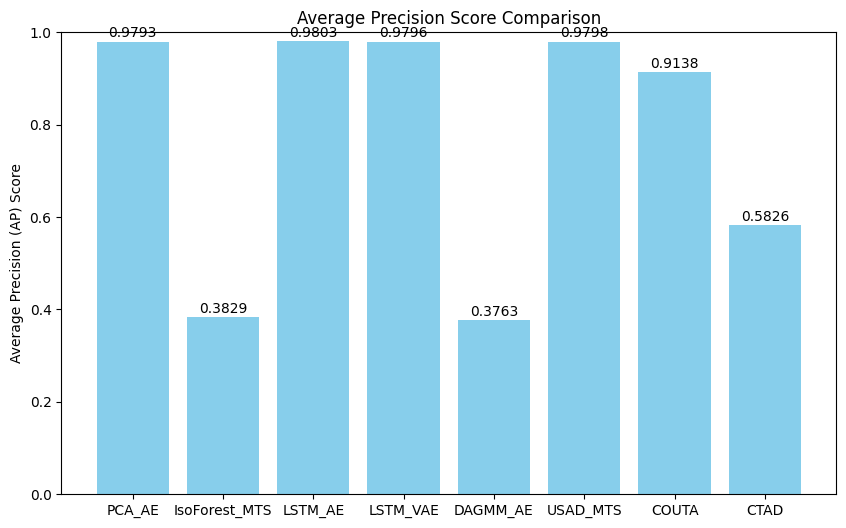

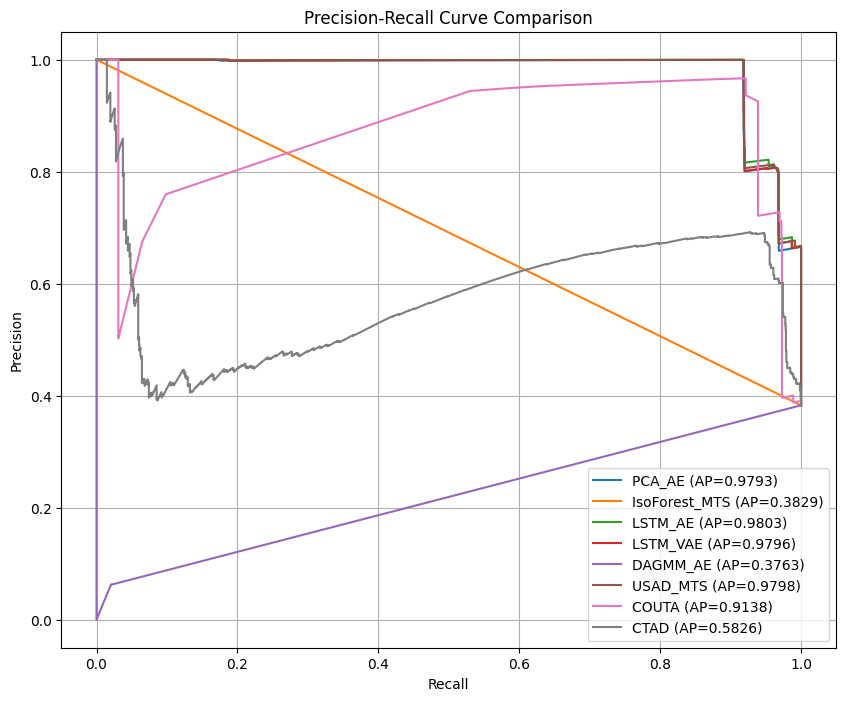

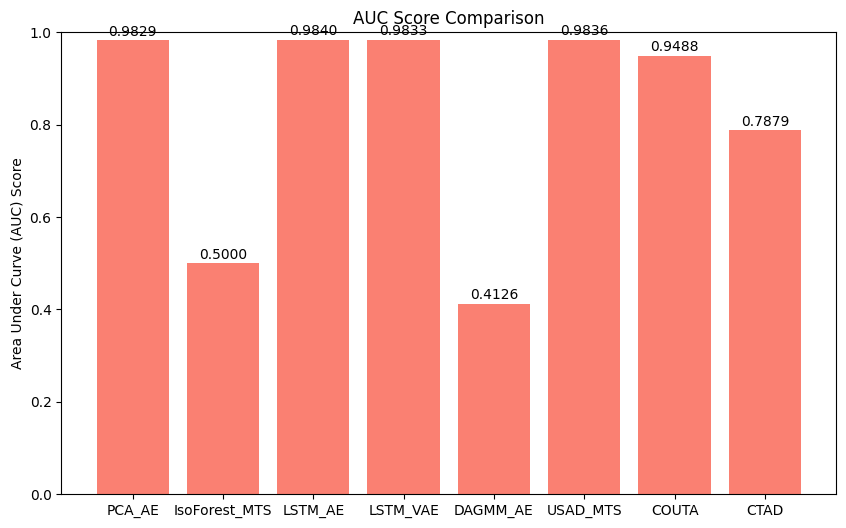

	 Rover D - Number 2
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.784462 | Val Loss: 0.862436
Epoch 2
	 Train Loss: 0.776413 | Val Loss: 0.857535
Epoch 3
	 Train Loss: 0.776542 | Val Loss: 0.853301
Epoch 4
	 Train Loss: 0.769306 | Val Loss: 0.849329
Epoch 5
	 Train Loss: 0.771637 | Val Loss: 0.844070
Epoch 6
	 Train Loss: 0.758412 | Val Loss: 0.839437
Epoch 7
	 Train Loss: 0.758532 | Val Loss: 0.836040
Epoch 8
	 Train Loss: 0.758633 | Val Loss: 0.833617
Epoch 9
	 Train Loss: 0.749091 | Val Loss: 0.831935
Epoch 10
	 Train Loss: 0.746750 | Val Loss: 0.830332
Epoch 11
	 Train Loss: 0.748688 | Val Loss: 0.829032
Epoch 12
	 Train Loss: 0.746265 | Val Loss: 0.825848
Epoch 13
	 Train Loss: 0.749864 | Val Loss: 0.824545
Epoch 14
	 Train Loss: 0.748164 | Val Loss: 0.822695
Epoch 15
	 Train Loss: 0.752114 | Val Loss: 0.821860
Epoch 16
	 Train Loss: 0.742406 | Val Loss: 0.820775
Epoch 17
	 Train Loss: 0.740906 | Val Loss: 0.821091
Epoch 18
	 Train Loss:

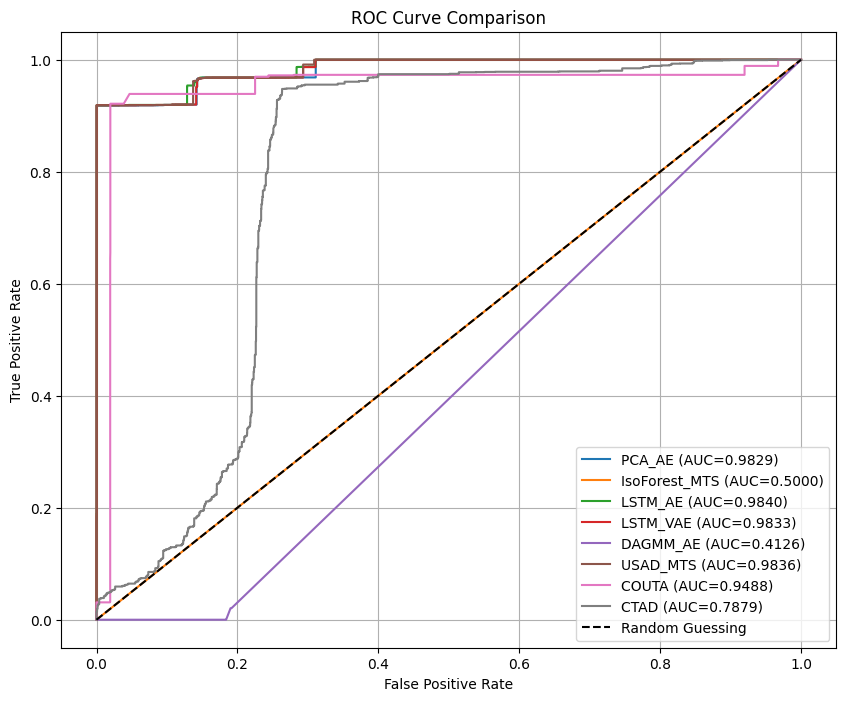

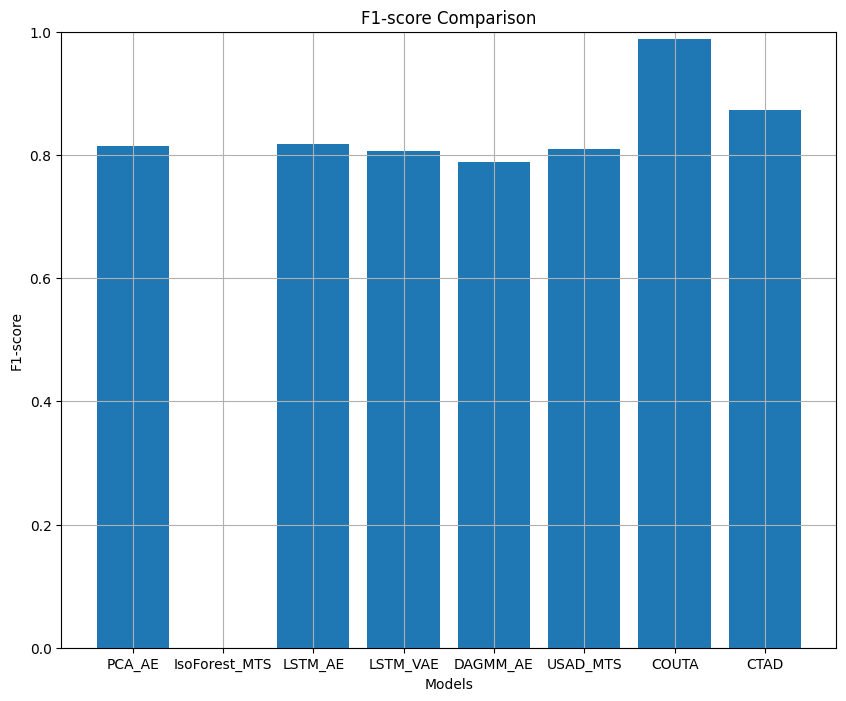

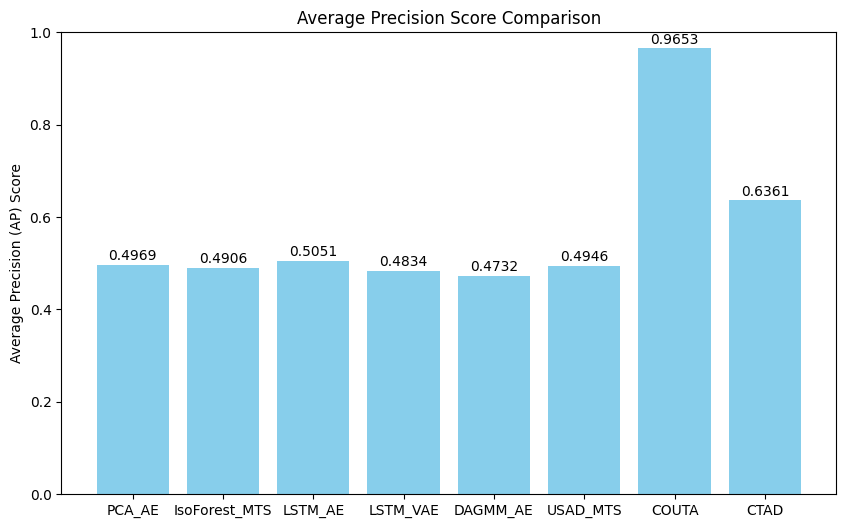

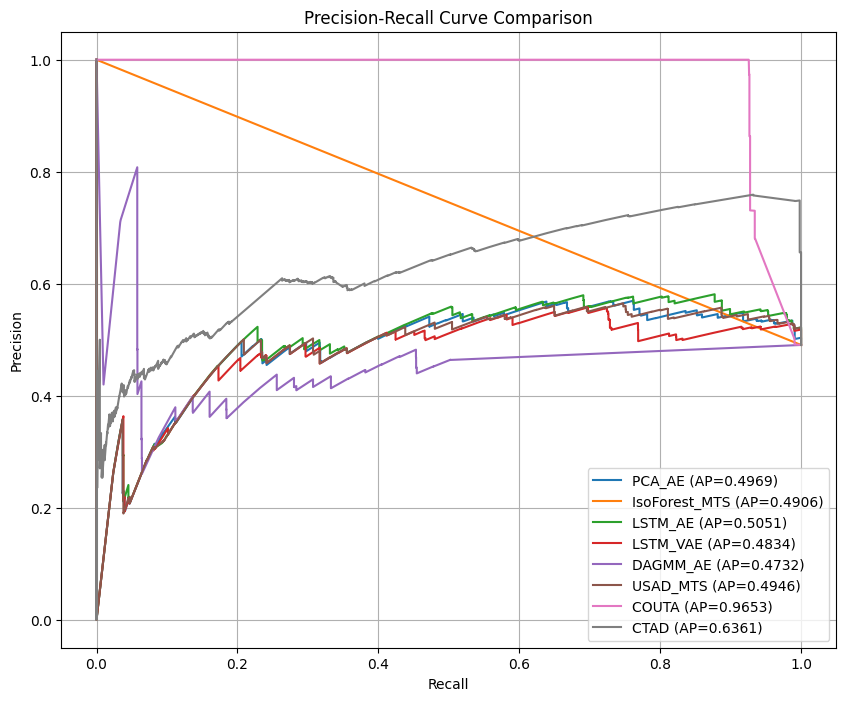

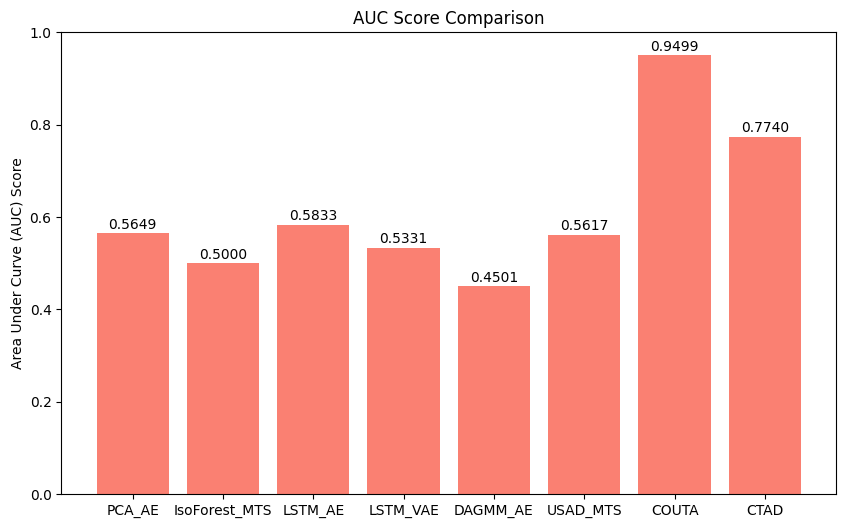

	 Rover E - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.742363 | Val Loss: 0.616997
Epoch 2
	 Train Loss: 0.736068 | Val Loss: 0.611675
Epoch 3
	 Train Loss: 0.728844 | Val Loss: 0.605549
Epoch 4
	 Train Loss: 0.726894 | Val Loss: 0.602123
Epoch 5
	 Train Loss: 0.720416 | Val Loss: 0.598244
Epoch 6
	 Train Loss: 0.715139 | Val Loss: 0.595363
Epoch 7
	 Train Loss: 0.713823 | Val Loss: 0.593078
Epoch 8
	 Train Loss: 0.718962 | Val Loss: 0.590649
Epoch 9
	 Train Loss: 0.710529 | Val Loss: 0.588361
Epoch 10
	 Train Loss: 0.711493 | Val Loss: 0.587040
Epoch 11
	 Train Loss: 0.703100 | Val Loss: 0.585587
Epoch 12
	 Train Loss: 0.711355 | Val Loss: 0.583146
Epoch 13
	 Train Loss: 0.701030 | Val Loss: 0.581348
Epoch 14
	 Train Loss: 0.700202 | Val Loss: 0.580819
Epoch 15
	 Train Loss: 0.702574 | Val Loss: 0.577893
Epoch 16
	 Train Loss: 0.703963 | Val Loss: 0.580304
Epoch 17
	 Train Loss: 0.704580 | Val Loss: 0.577057
Epoch 18
	 Train Loss:

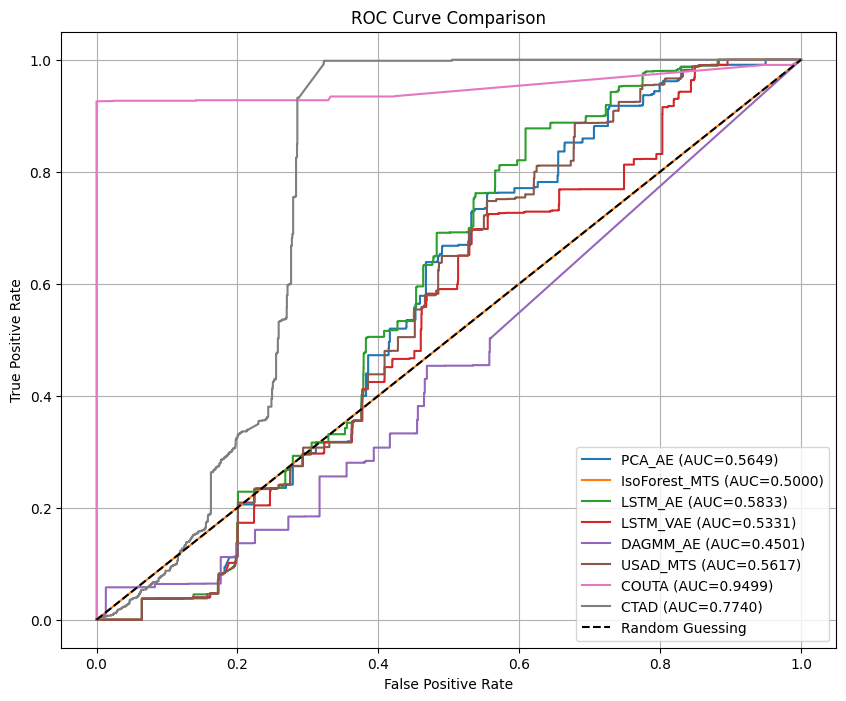

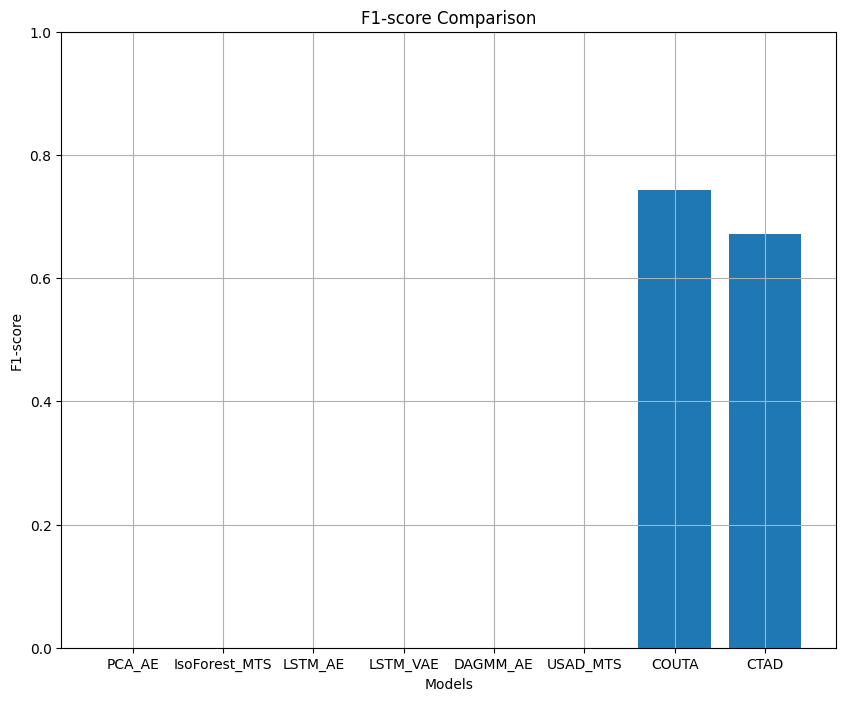

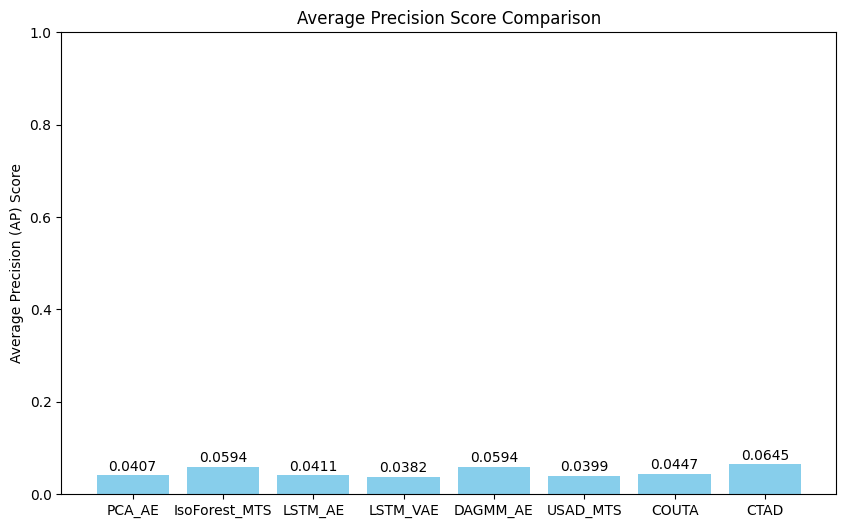

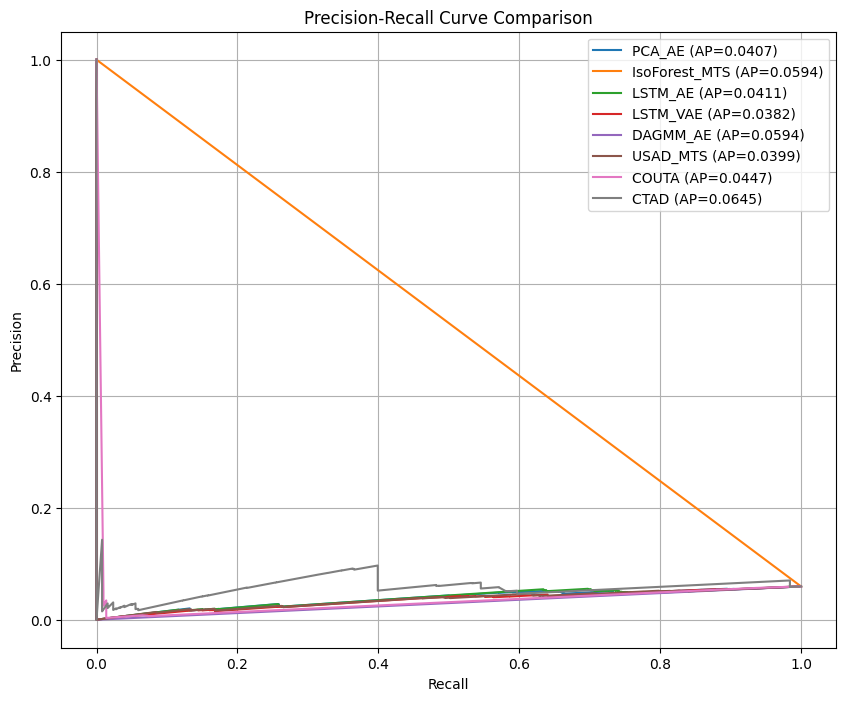

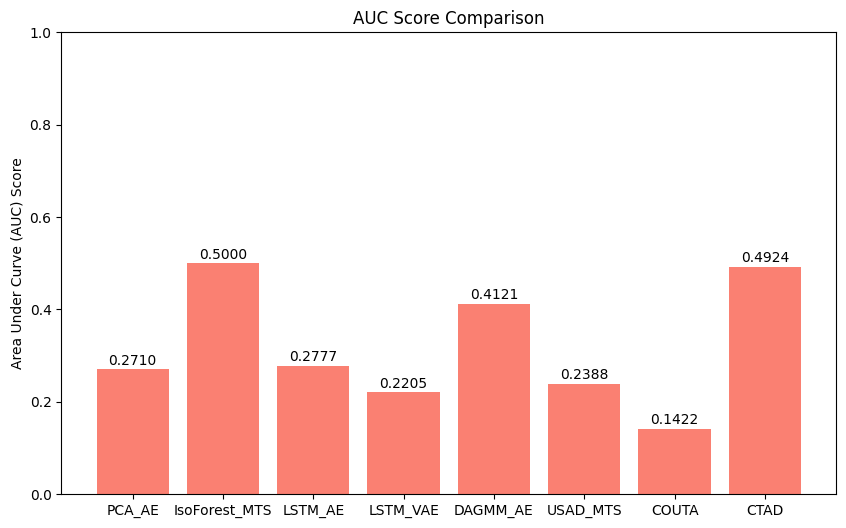

	 Rover F - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.709741 | Val Loss: 0.649524
Epoch 2
	 Train Loss: 0.705005 | Val Loss: 0.644577
Epoch 3
	 Train Loss: 0.699680 | Val Loss: 0.639575
Epoch 4
	 Train Loss: 0.692820 | Val Loss: 0.636188
Epoch 5
	 Train Loss: 0.693943 | Val Loss: 0.630917
Epoch 6
	 Train Loss: 0.685832 | Val Loss: 0.627446
Epoch 7
	 Train Loss: 0.689138 | Val Loss: 0.624960
Epoch 8
	 Train Loss: 0.678542 | Val Loss: 0.621960
Epoch 9
	 Train Loss: 0.682136 | Val Loss: 0.620821
Epoch 10
	 Train Loss: 0.674644 | Val Loss: 0.619444
Epoch 11
	 Train Loss: 0.674342 | Val Loss: 0.618978
Epoch 12
	 Train Loss: 0.676806 | Val Loss: 0.617473
Epoch 13
	 Train Loss: 0.676963 | Val Loss: 0.616066
Epoch 14
	 Train Loss: 0.675705 | Val Loss: 0.616120
Epoch 15
	 Train Loss: 0.666747 | Val Loss: 0.614679
Epoch 16
	 Train Loss: 0.676622 | Val Loss: 0.616974
Epoch 17
	 Train Loss: 0.672390 | Val Loss: 0.613963
Epoch 18
	 Train Loss:

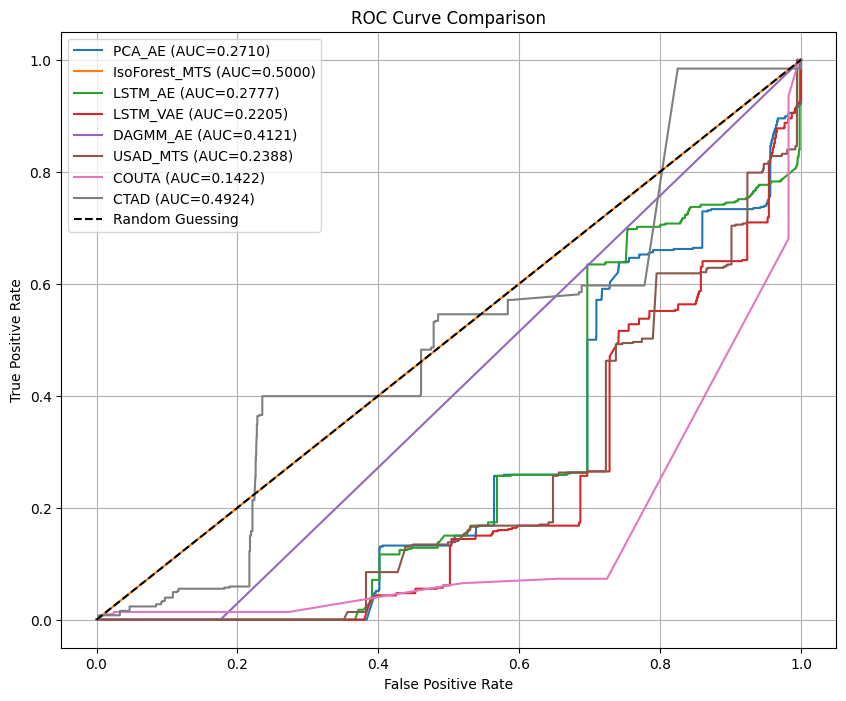

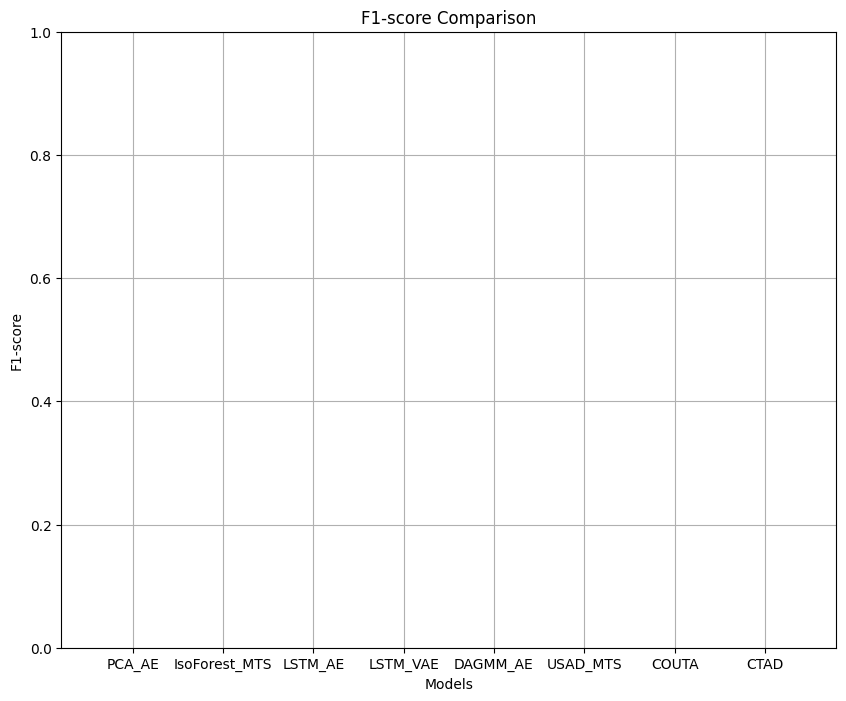

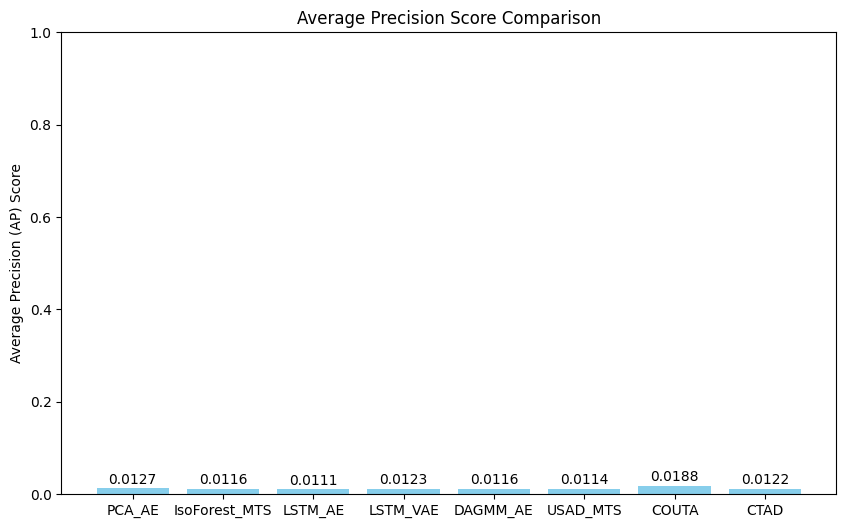

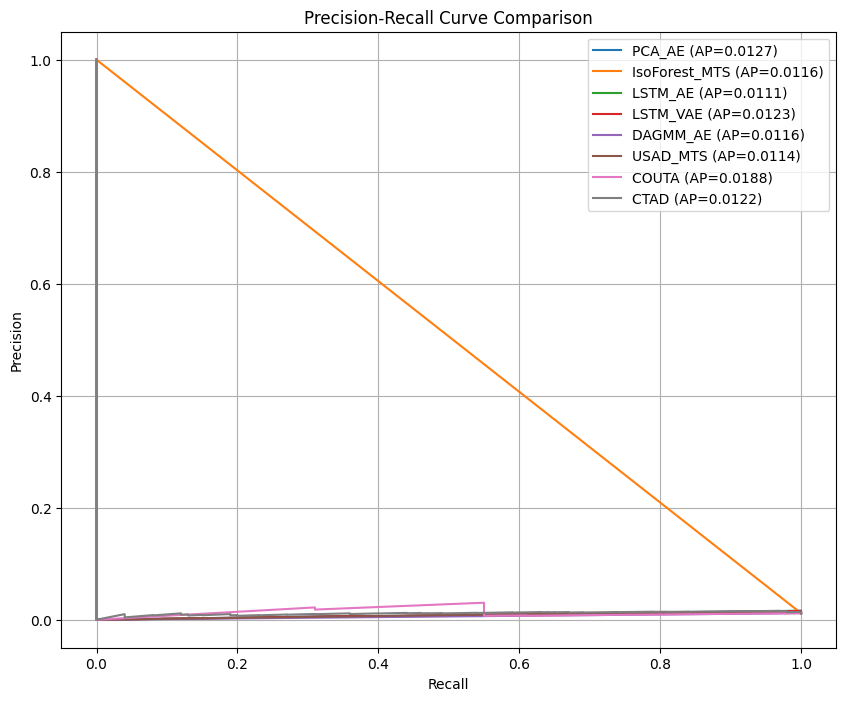

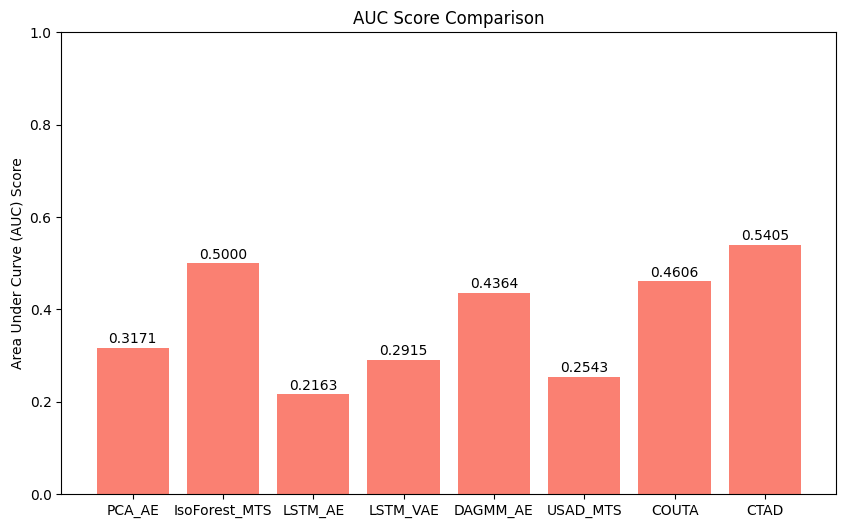

	 Rover G - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.793079 | Val Loss: 0.554976
Epoch 2
	 Train Loss: 0.785494 | Val Loss: 0.550453
Epoch 3
	 Train Loss: 0.780512 | Val Loss: 0.540607
Epoch 4
	 Train Loss: 0.776336 | Val Loss: 0.537270
Epoch 5
	 Train Loss: 0.772709 | Val Loss: 0.533076
Epoch 6
	 Train Loss: 0.769805 | Val Loss: 0.529674
Epoch 7
	 Train Loss: 0.766839 | Val Loss: 0.525545
Epoch 8
	 Train Loss: 0.763505 | Val Loss: 0.518953
Epoch 9
	 Train Loss: 0.760048 | Val Loss: 0.519680
Epoch 10
	 Train Loss: 0.756775 | Val Loss: 0.518791
Epoch 11
	 Train Loss: 0.754137 | Val Loss: 0.515564
Epoch 12
	 Train Loss: 0.751132 | Val Loss: 0.515960
Epoch 13
	 Train Loss: 0.744368 | Val Loss: 0.512579
Epoch 14
	 Train Loss: 0.736409 | Val Loss: 0.508391
Epoch 15
	 Train Loss: 0.730164 | Val Loss: 0.510813
Epoch 16
	 Train Loss: 0.721508 | Val Loss: 0.516926
Epoch 17
	 Train Loss: 0.716186 | Val Loss: 0.525033
Epoch 18
	 Train Loss:

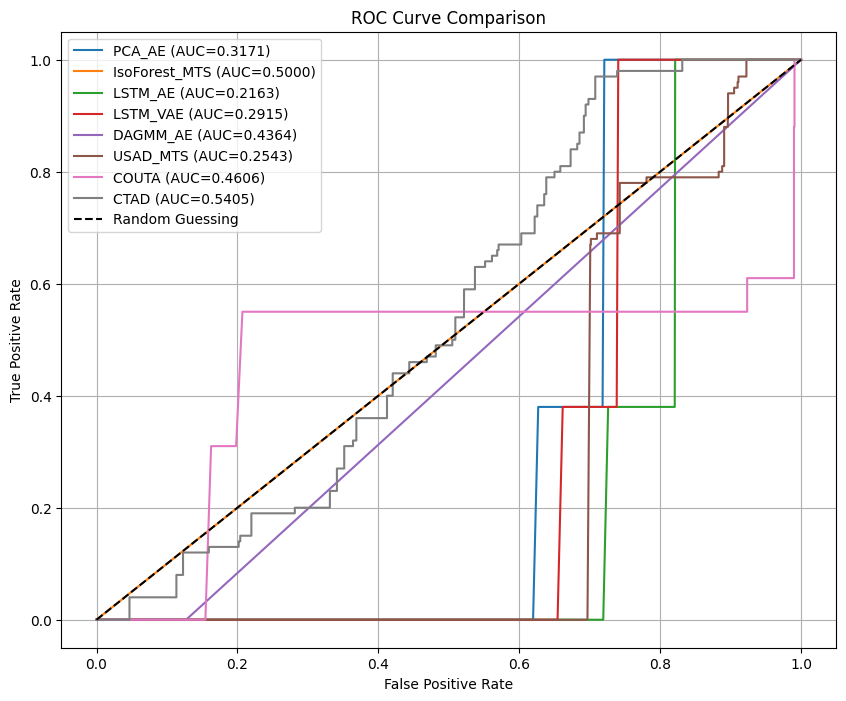

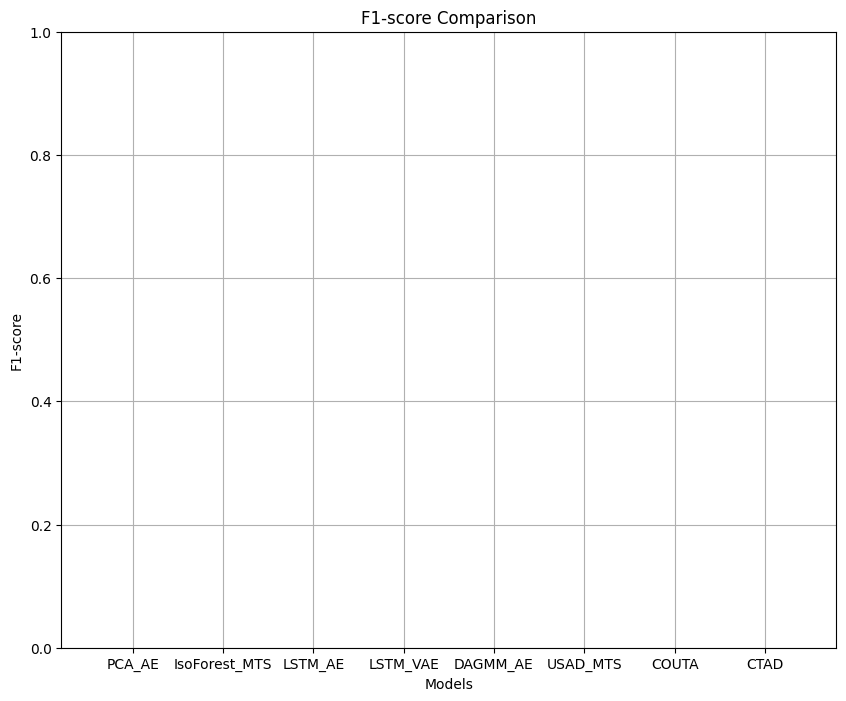

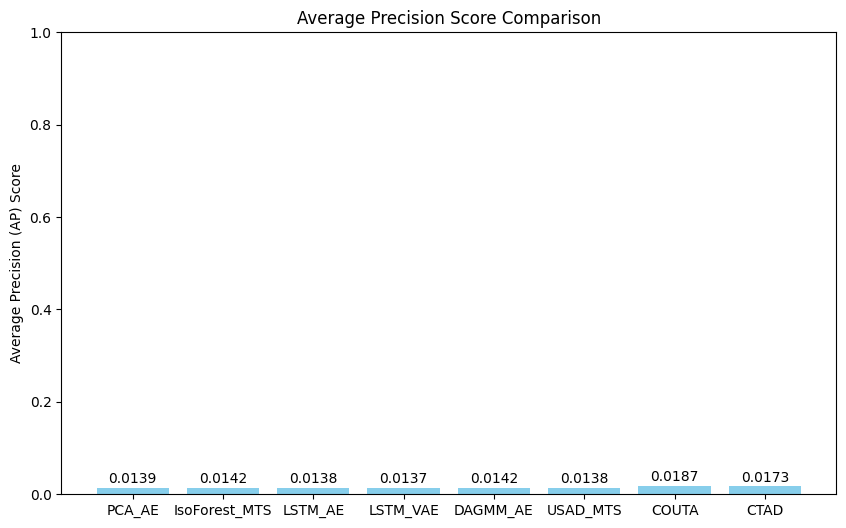

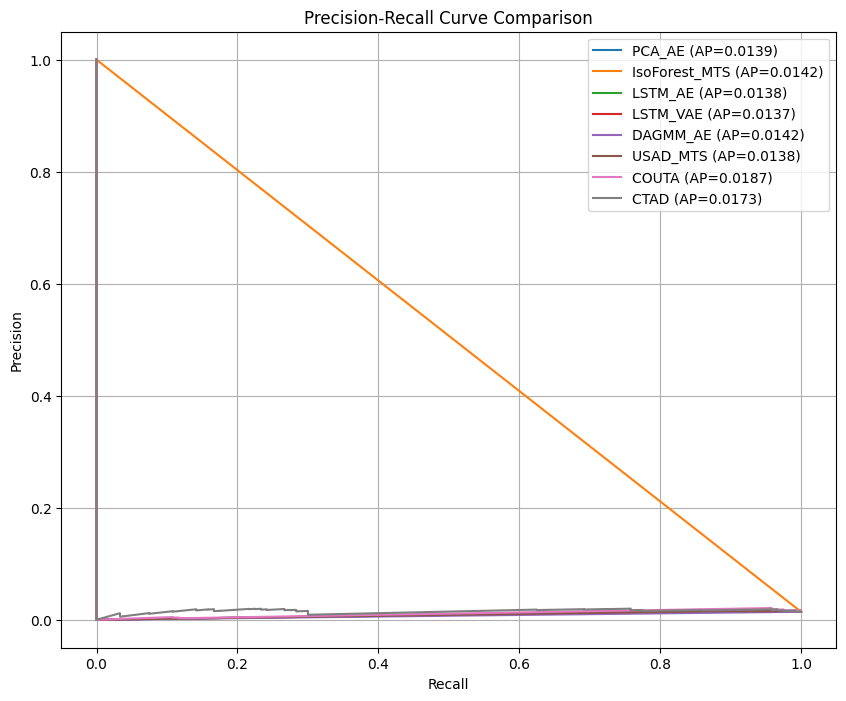

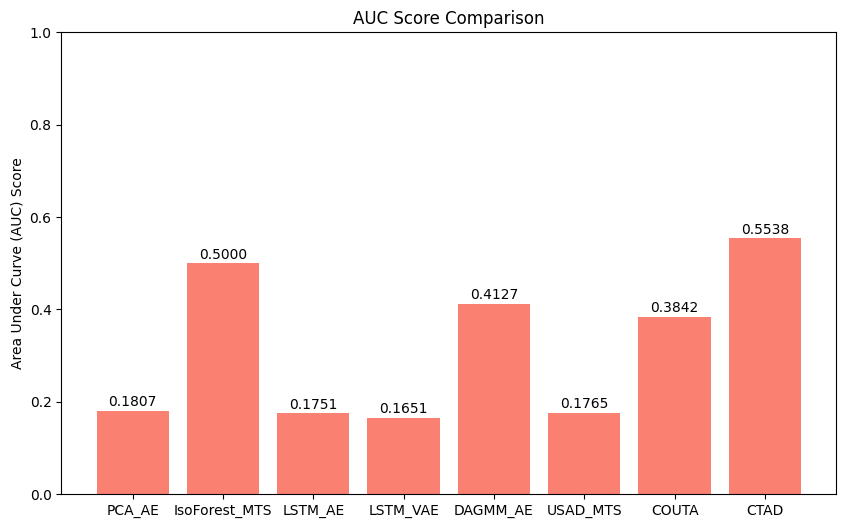

	 Rover M - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.278500 | Val Loss: 0.221894
Epoch 2
	 Train Loss: 0.275517 | Val Loss: 0.215794
Epoch 3
	 Train Loss: 0.271782 | Val Loss: 0.212850
Epoch 4
	 Train Loss: 0.268165 | Val Loss: 0.210437
Epoch 5
	 Train Loss: 0.264168 | Val Loss: 0.207031
Epoch 6
	 Train Loss: 0.261074 | Val Loss: 0.204047
Epoch 7
	 Train Loss: 0.258351 | Val Loss: 0.202015
Epoch 8
	 Train Loss: 0.259327 | Val Loss: 0.200528
Epoch 9
	 Train Loss: 0.258226 | Val Loss: 0.199208
Epoch 10
	 Train Loss: 0.251651 | Val Loss: 0.197888
Epoch 11
	 Train Loss: 0.254361 | Val Loss: 0.196673
Epoch 12
	 Train Loss: 0.250887 | Val Loss: 0.195806
Epoch 13
	 Train Loss: 0.253842 | Val Loss: 0.194894
Epoch 14
	 Train Loss: 0.251381 | Val Loss: 0.194164
Epoch 15
	 Train Loss: 0.250111 | Val Loss: 0.193470
Epoch 16
	 Train Loss: 0.248611 | Val Loss: 0.192991
Epoch 17
	 Train Loss: 0.249501 | Val Loss: 0.192374
Epoch 18
	 Train Loss:

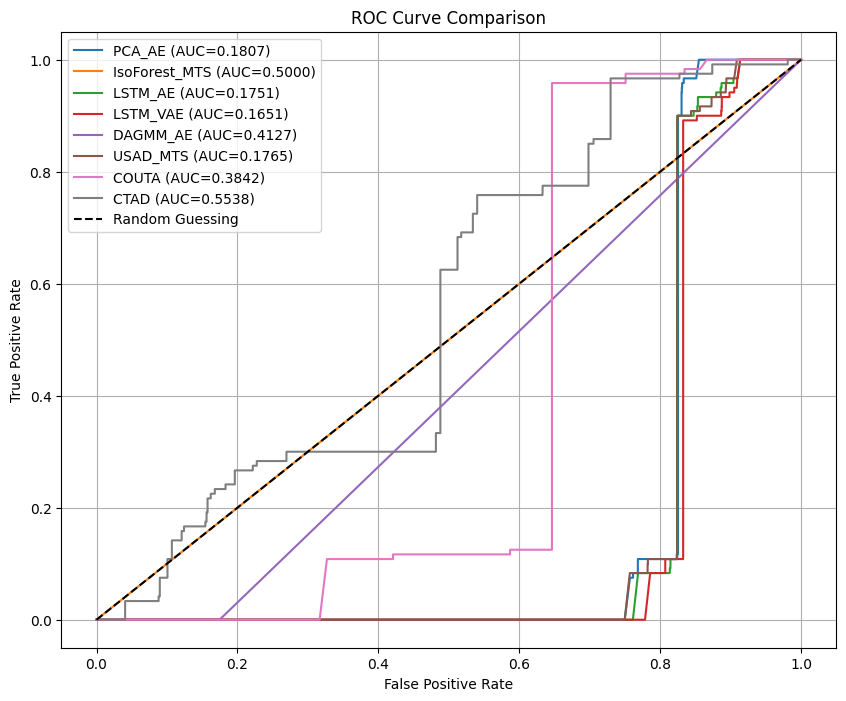

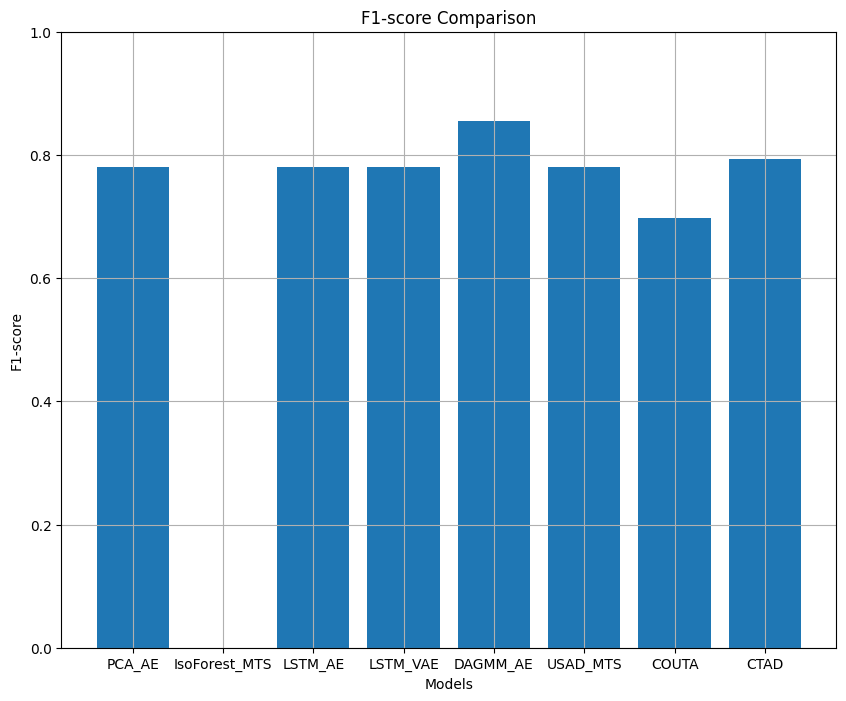

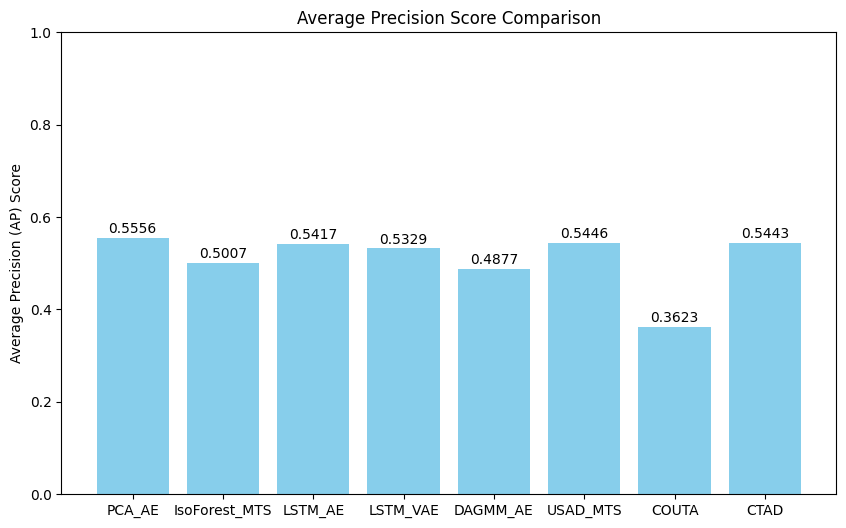

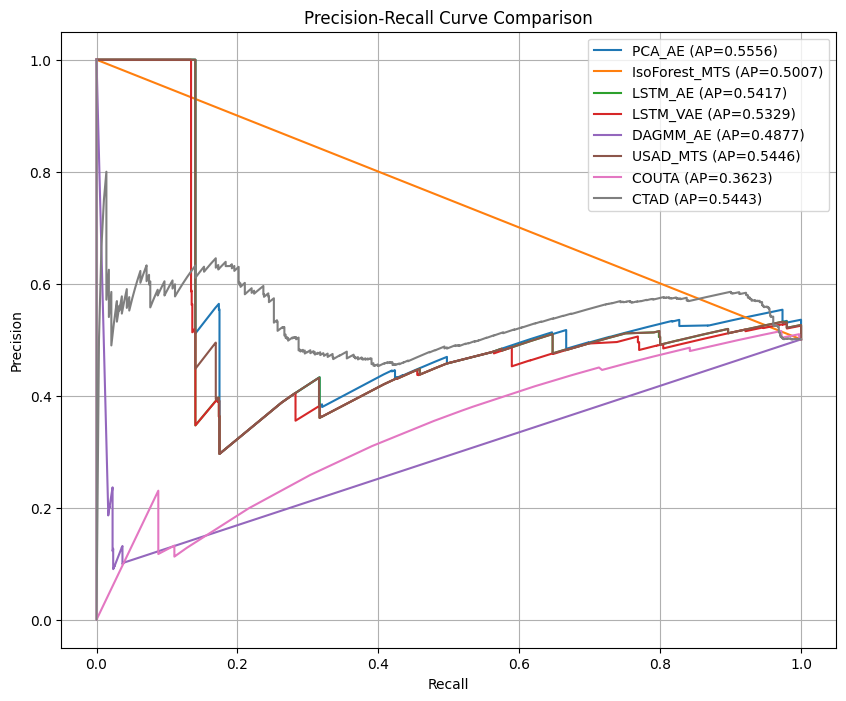

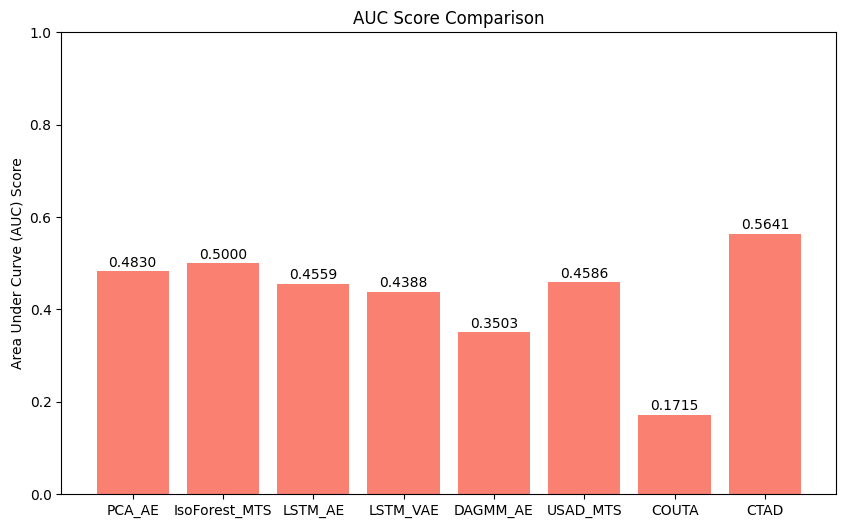

	 Rover M - Number 2
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.273951 | Val Loss: 0.249240
Epoch 2
	 Train Loss: 0.266383 | Val Loss: 0.240819
Epoch 3
	 Train Loss: 0.265938 | Val Loss: 0.231667
Epoch 4
	 Train Loss: 0.264555 | Val Loss: 0.221961
Epoch 5
	 Train Loss: 0.259681 | Val Loss: 0.217021
Epoch 6
	 Train Loss: 0.258636 | Val Loss: 0.213154
Epoch 7
	 Train Loss: 0.255200 | Val Loss: 0.210736
Epoch 8
	 Train Loss: 0.252797 | Val Loss: 0.209733
Epoch 9
	 Train Loss: 0.251933 | Val Loss: 0.207850
Epoch 10
	 Train Loss: 0.249526 | Val Loss: 0.207089
Epoch 11
	 Train Loss: 0.251380 | Val Loss: 0.205150
Epoch 12
	 Train Loss: 0.247898 | Val Loss: 0.204893
Epoch 13
	 Train Loss: 0.248221 | Val Loss: 0.204244
Epoch 14
	 Train Loss: 0.243174 | Val Loss: 0.203867
Epoch 15
	 Train Loss: 0.246319 | Val Loss: 0.203660
Epoch 16
	 Train Loss: 0.246874 | Val Loss: 0.201631
Epoch 17
	 Train Loss: 0.243309 | Val Loss: 0.202401
Epoch 18
	 Train Loss:

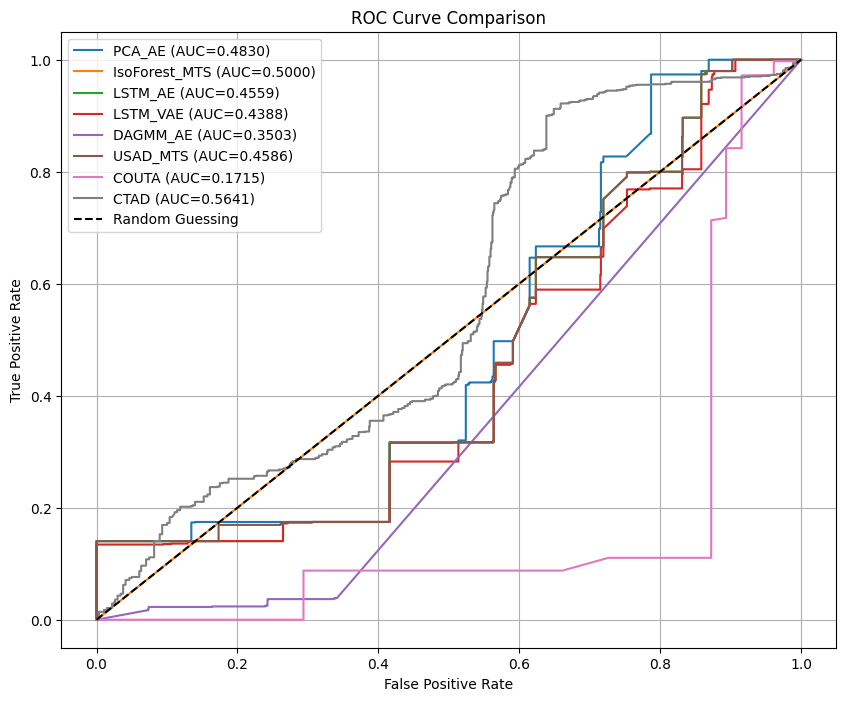

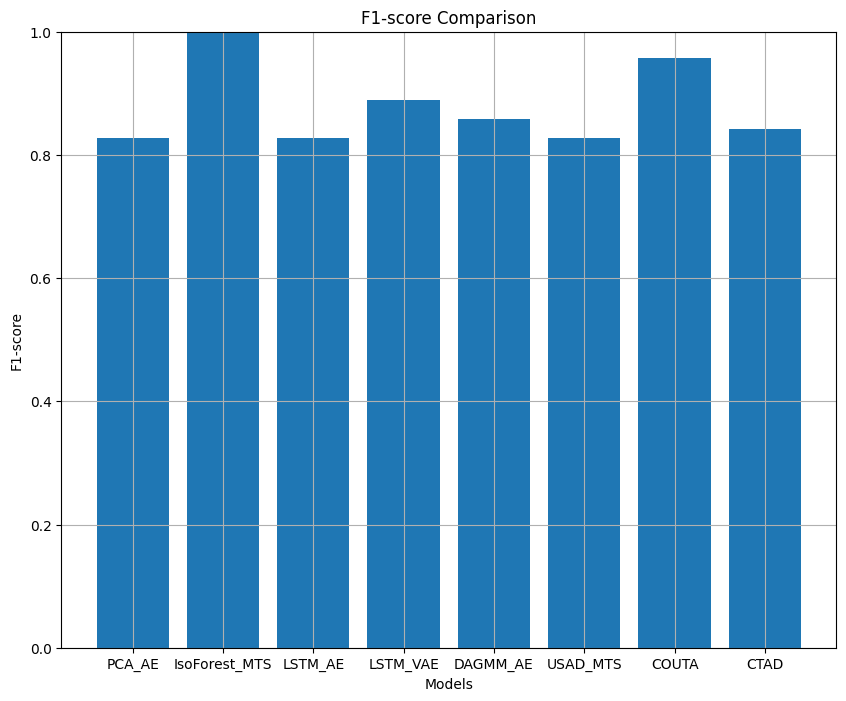

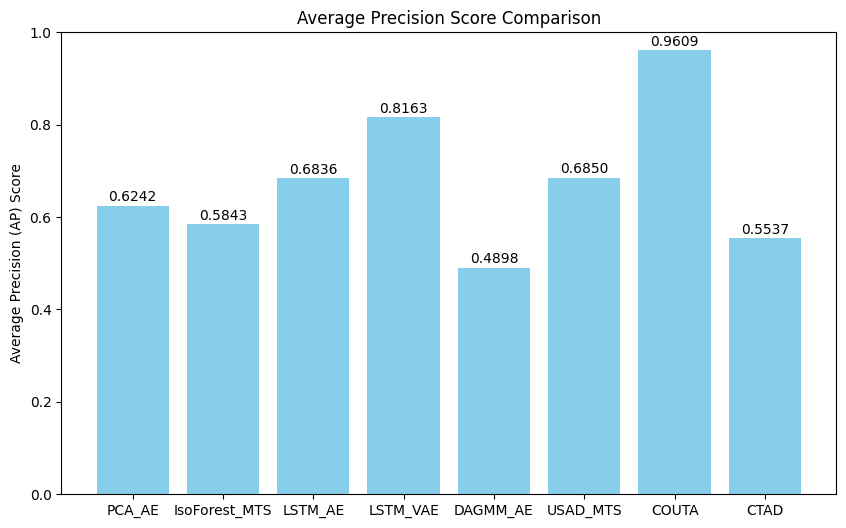

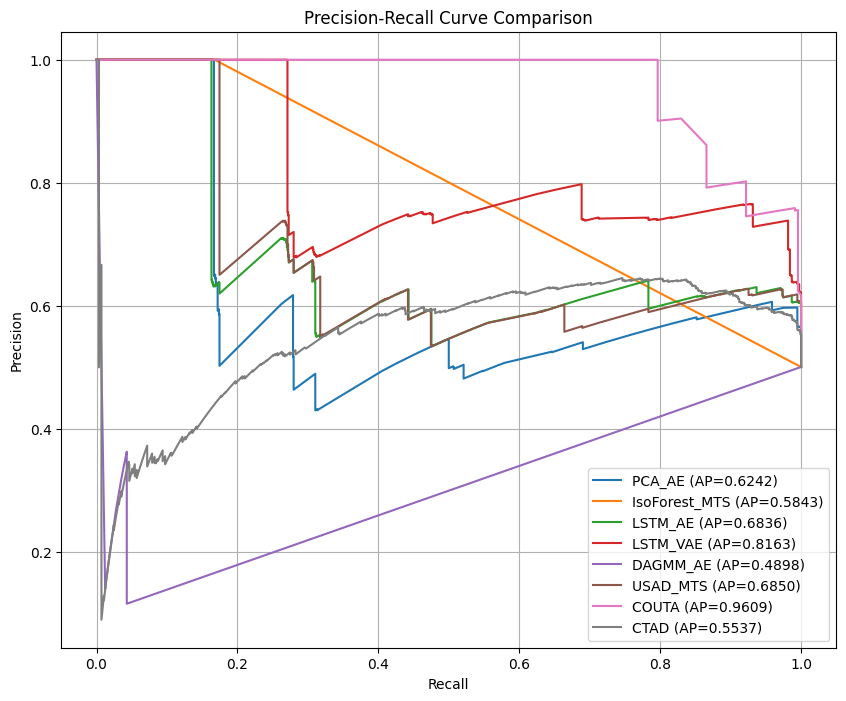

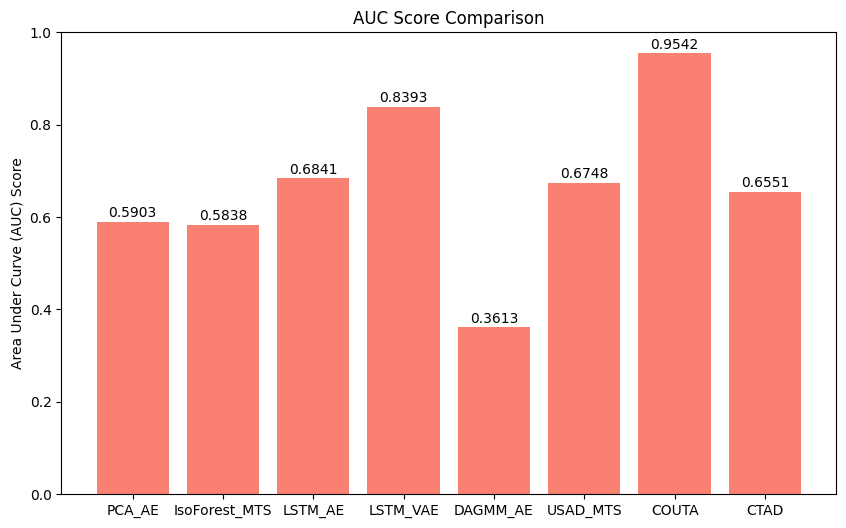

	 Rover P - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.636253 | Val Loss: 0.959932
Epoch 2
	 Train Loss: 0.633671 | Val Loss: 0.955645
Epoch 3
	 Train Loss: 0.632236 | Val Loss: 0.950920
Epoch 4
	 Train Loss: 0.619180 | Val Loss: 0.944574
Epoch 5
	 Train Loss: 0.613014 | Val Loss: 0.941573
Epoch 6
	 Train Loss: 0.616863 | Val Loss: 0.938682
Epoch 7
	 Train Loss: 0.608059 | Val Loss: 0.937019
Epoch 8
	 Train Loss: 0.611701 | Val Loss: 0.936191
Epoch 9
	 Train Loss: 0.612302 | Val Loss: 0.935440
Epoch 10
	 Train Loss: 0.608481 | Val Loss: 0.934255
Epoch 11
	 Train Loss: 0.600653 | Val Loss: 0.932972
Epoch 12
	 Train Loss: 0.603601 | Val Loss: 0.932446
Epoch 13
	 Train Loss: 0.599110 | Val Loss: 0.930298
Epoch 14
	 Train Loss: 0.597265 | Val Loss: 0.930675
Epoch 15
	 Train Loss: 0.594122 | Val Loss: 0.928518
Epoch 16
	 Train Loss: 0.590338 | Val Loss: 0.929947
Epoch 17
	 Train Loss: 0.586666 | Val Loss: 0.922714
Epoch 18
	 Train Loss:

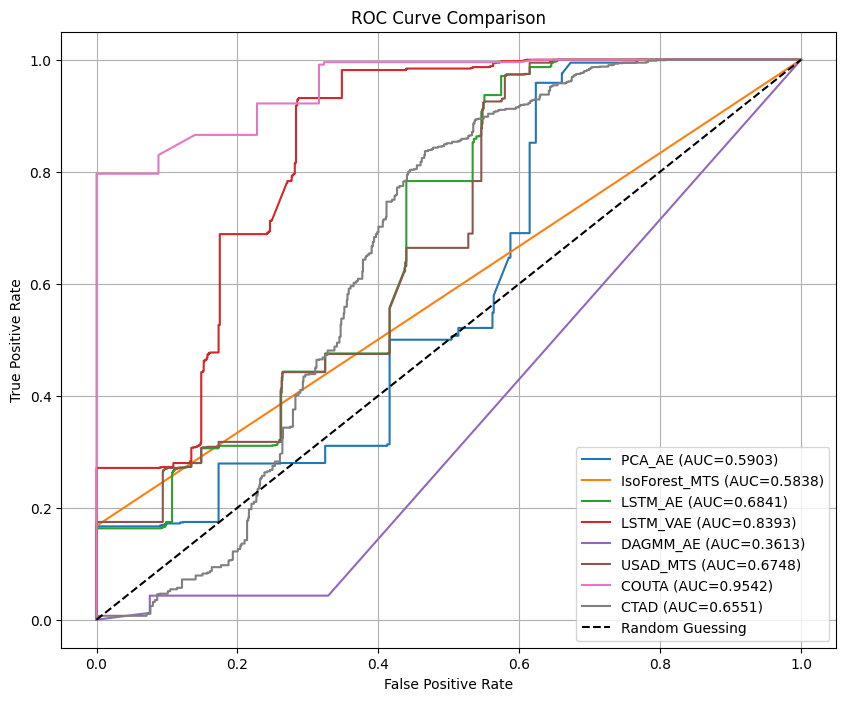

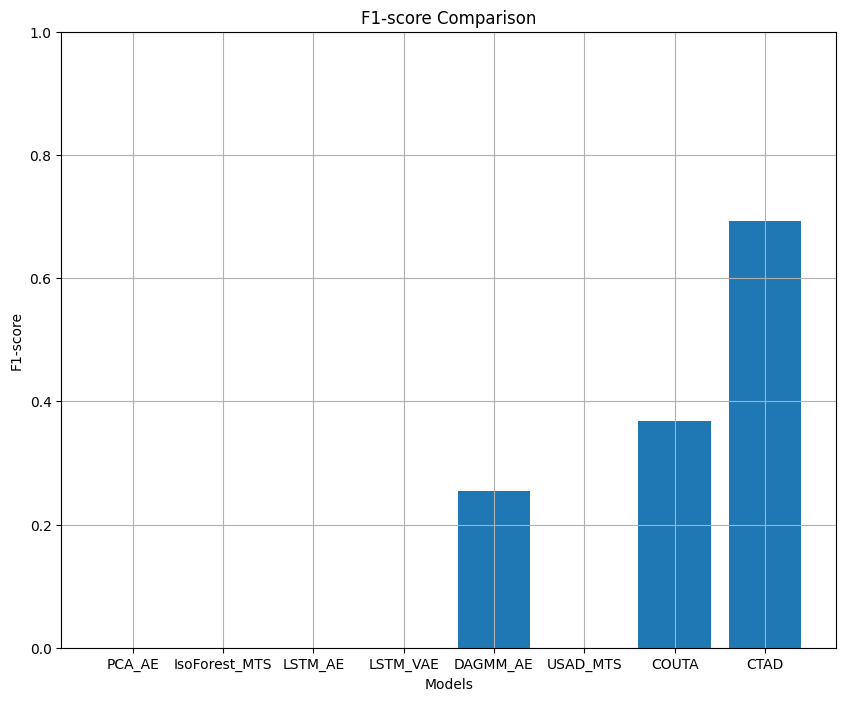

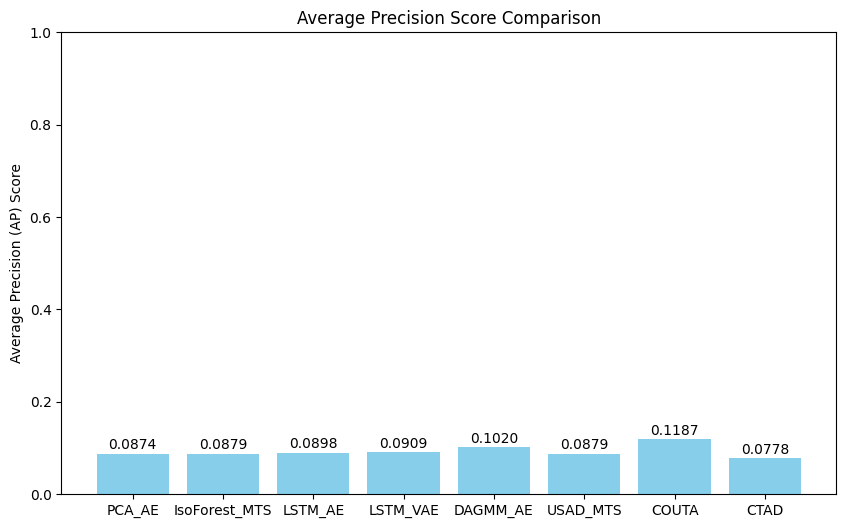

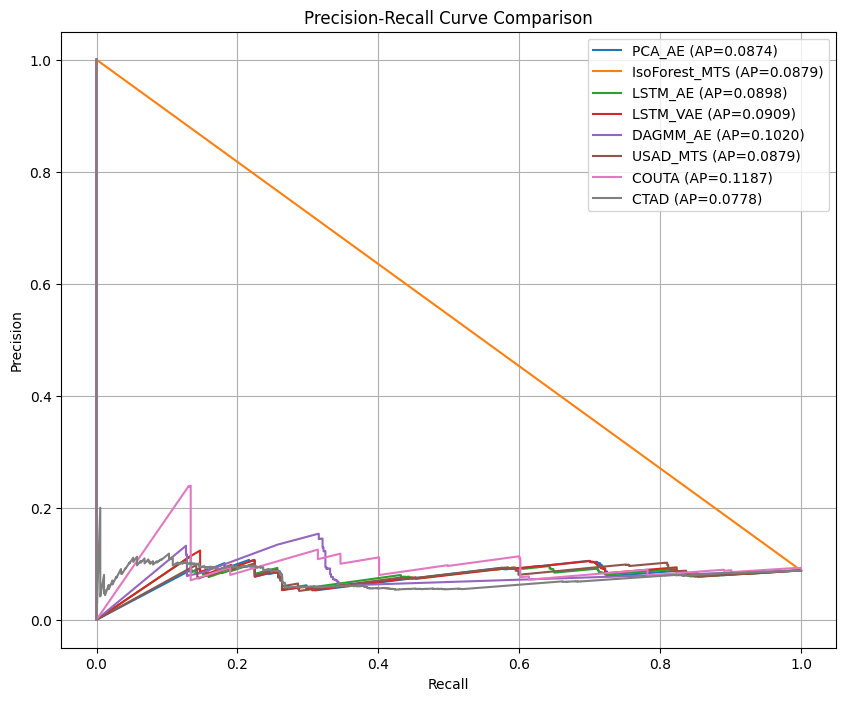

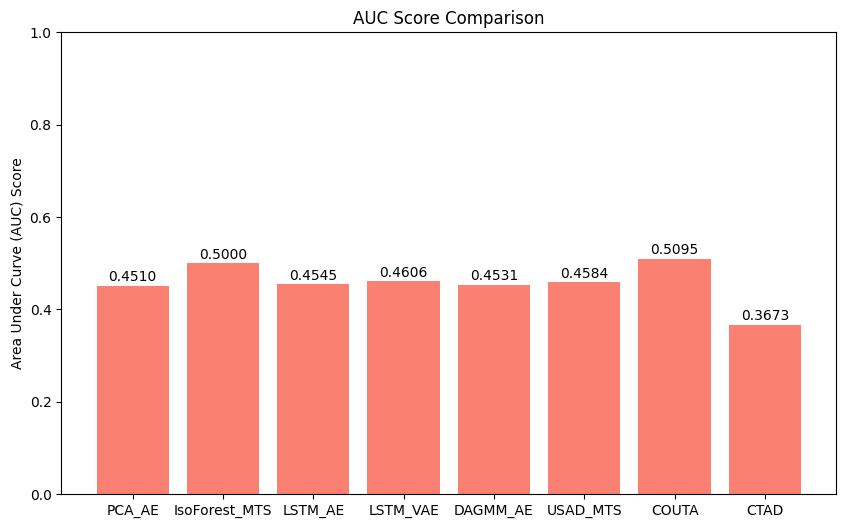

	 Rover R - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.326682 | Val Loss: 0.030356
Epoch 2
	 Train Loss: 0.311314 | Val Loss: 0.026804
Epoch 3
	 Train Loss: 0.308906 | Val Loss: 0.023396
Epoch 4
	 Train Loss: 0.301153 | Val Loss: 0.020770
Epoch 5
	 Train Loss: 0.304973 | Val Loss: 0.018507
Epoch 6
	 Train Loss: 0.295979 | Val Loss: 0.016570
Epoch 7
	 Train Loss: 0.294520 | Val Loss: 0.014906
Epoch 8
	 Train Loss: 0.295874 | Val Loss: 0.013459
Epoch 9
	 Train Loss: 0.295770 | Val Loss: 0.012157
Epoch 10
	 Train Loss: 0.297376 | Val Loss: 0.011123
Epoch 11
	 Train Loss: 0.289534 | Val Loss: 0.010144
Epoch 12
	 Train Loss: 0.286541 | Val Loss: 0.009300
Epoch 13
	 Train Loss: 0.289868 | Val Loss: 0.008562
Epoch 14
	 Train Loss: 0.290323 | Val Loss: 0.007925
Epoch 15
	 Train Loss: 0.282557 | Val Loss: 0.007373
Epoch 16
	 Train Loss: 0.288957 | Val Loss: 0.006864
Epoch 17
	 Train Loss: 0.292630 | Val Loss: 0.006455
Epoch 18
	 Train Loss:

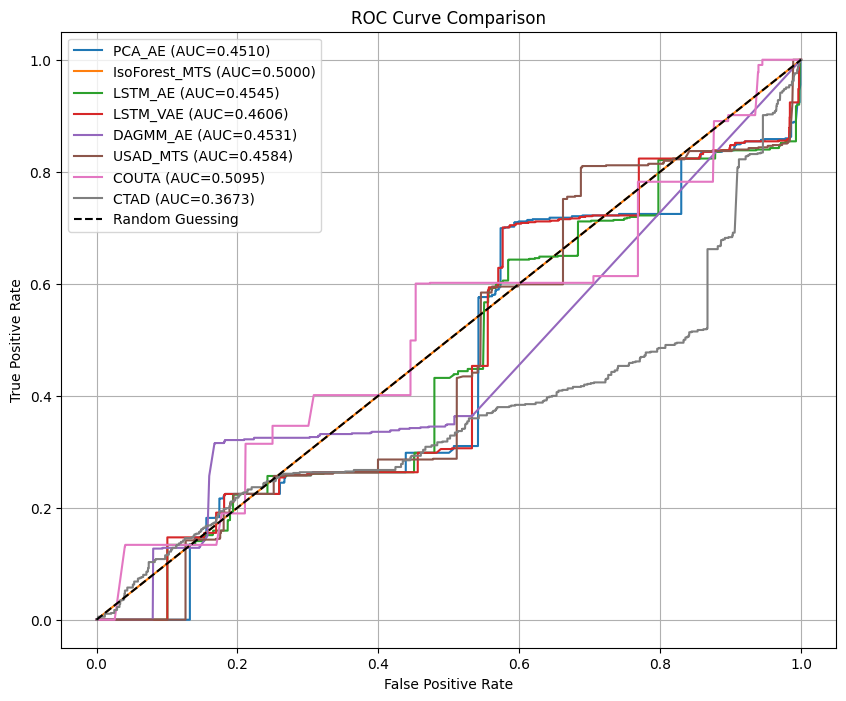

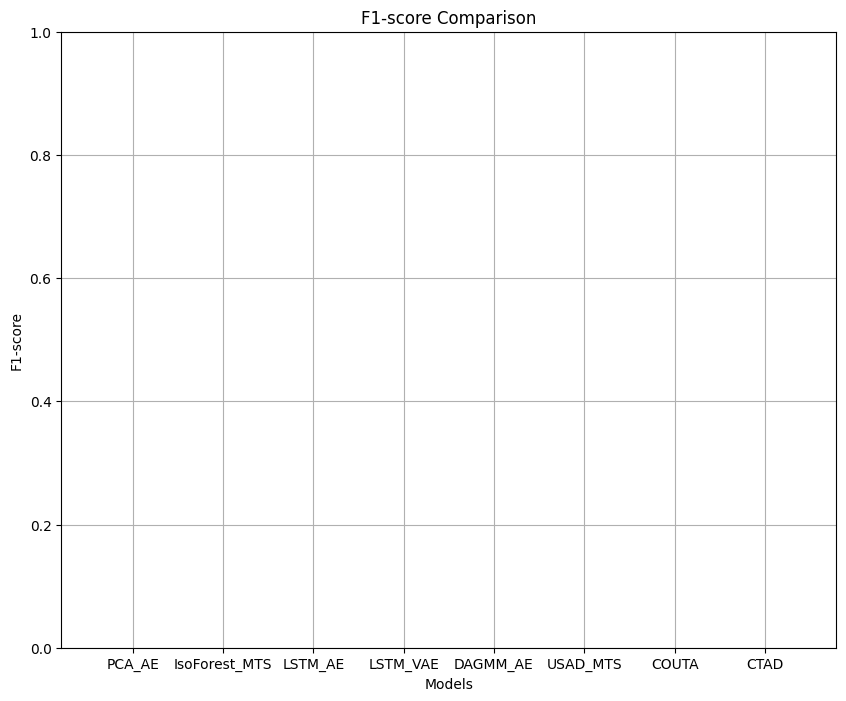

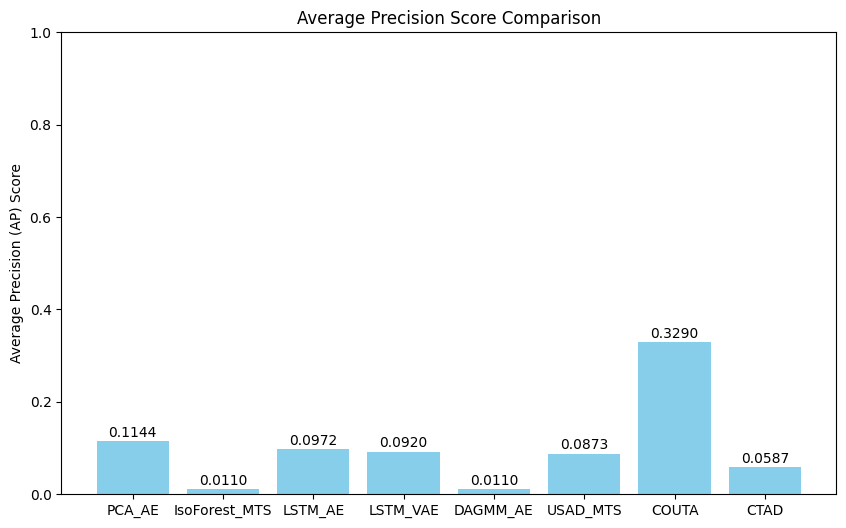

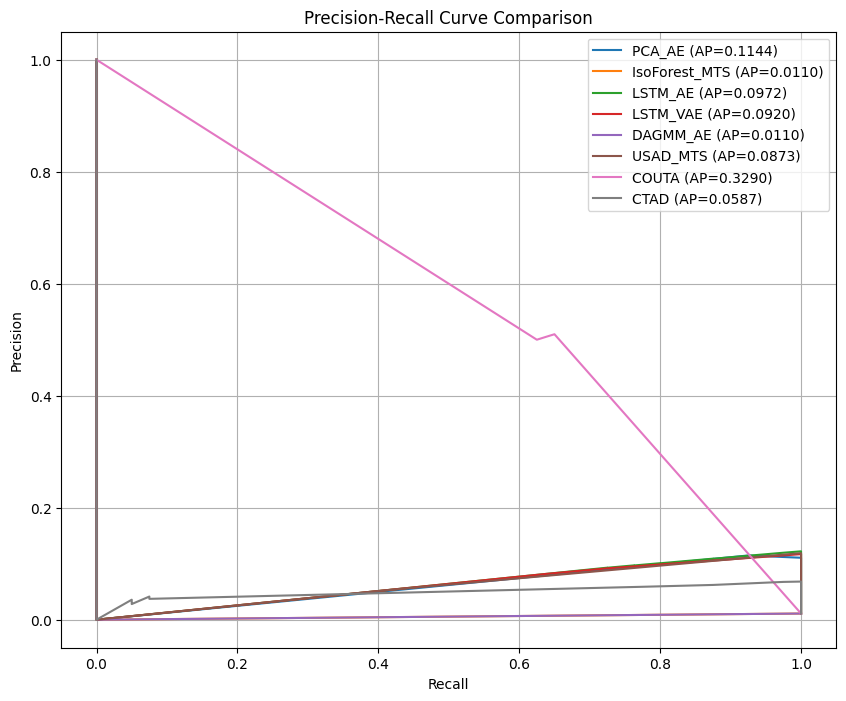

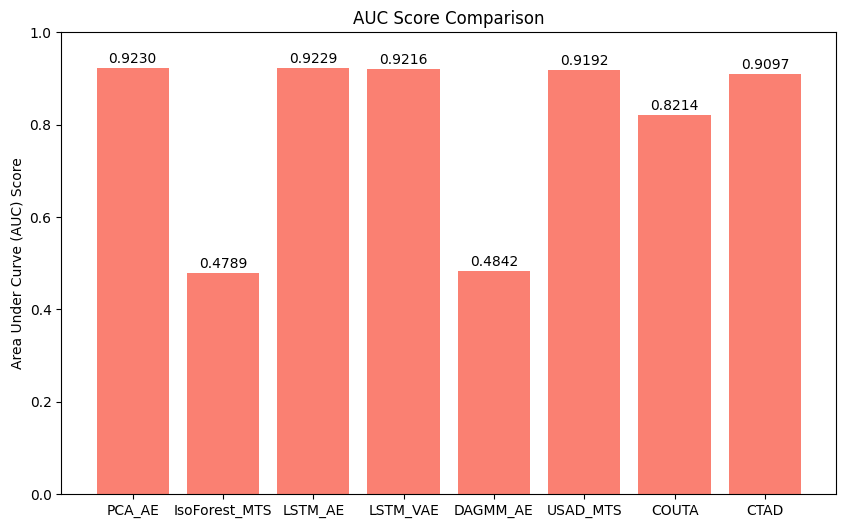

	 Rover S - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.745479 | Val Loss: 0.643012
Epoch 2
	 Train Loss: 0.740582 | Val Loss: 0.638669
Epoch 3
	 Train Loss: 0.736262 | Val Loss: 0.633988
Epoch 4
	 Train Loss: 0.731917 | Val Loss: 0.630081
Epoch 5
	 Train Loss: 0.727908 | Val Loss: 0.627134
Epoch 6
	 Train Loss: 0.724670 | Val Loss: 0.624696
Epoch 7
	 Train Loss: 0.721943 | Val Loss: 0.621714
Epoch 8
	 Train Loss: 0.719524 | Val Loss: 0.619594
Epoch 9
	 Train Loss: 0.717388 | Val Loss: 0.617716
Epoch 10
	 Train Loss: 0.715729 | Val Loss: 0.615442
Epoch 11
	 Train Loss: 0.714165 | Val Loss: 0.613770
Epoch 12
	 Train Loss: 0.712807 | Val Loss: 0.612598
Epoch 13
	 Train Loss: 0.711697 | Val Loss: 0.612466
Epoch 14
	 Train Loss: 0.710639 | Val Loss: 0.610399
Epoch 15
	 Train Loss: 0.709576 | Val Loss: 0.610216
Epoch 16
	 Train Loss: 0.708786 | Val Loss: 0.609523
Epoch 17
	 Train Loss: 0.707851 | Val Loss: 0.607909
Epoch 18
	 Train Loss:

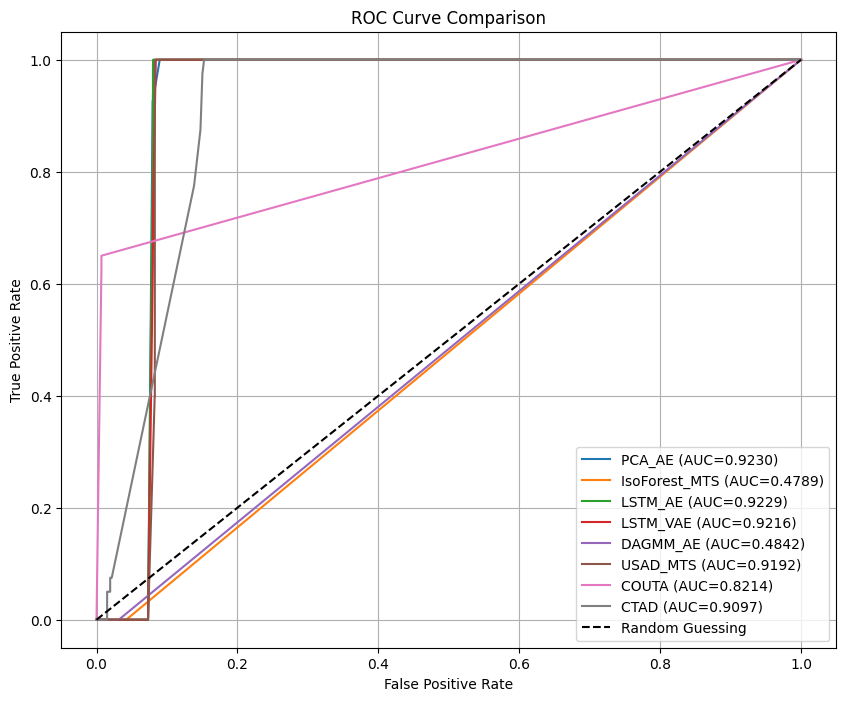

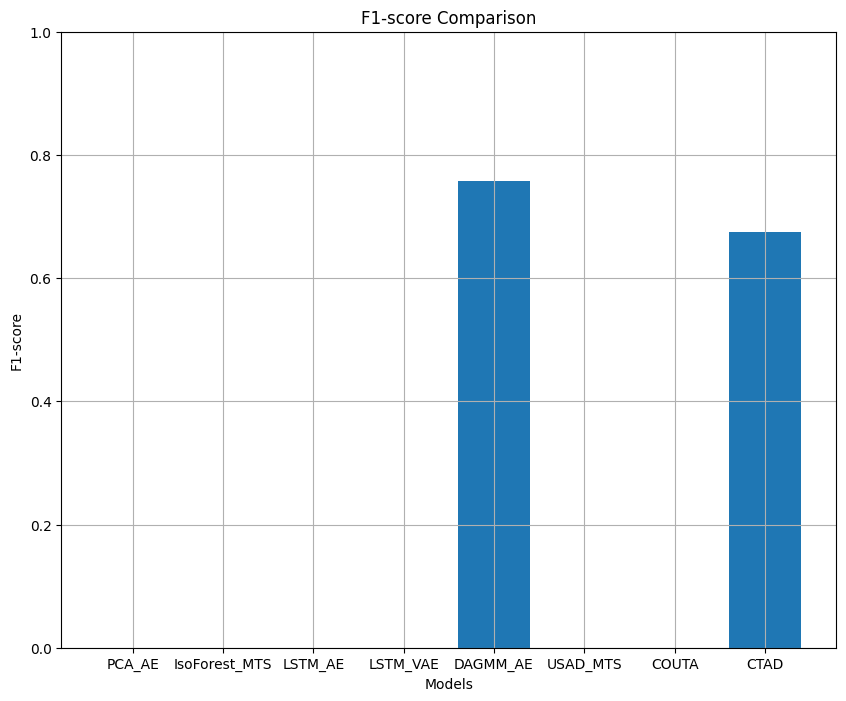

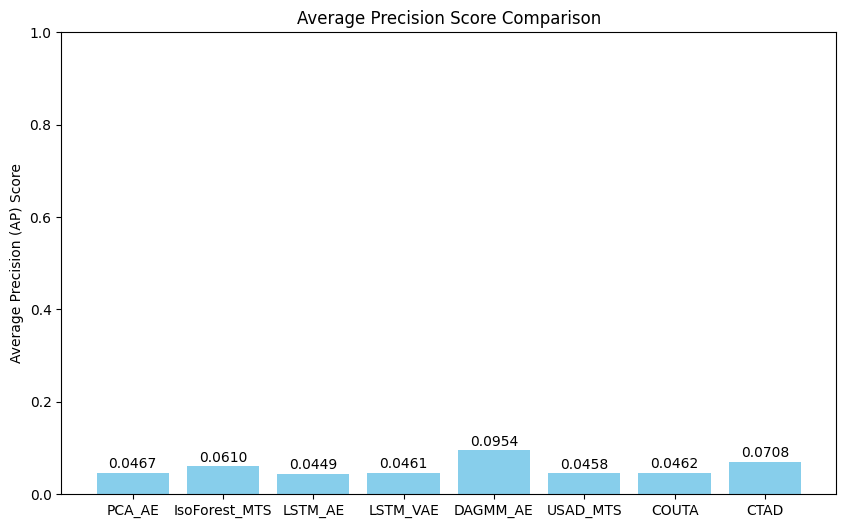

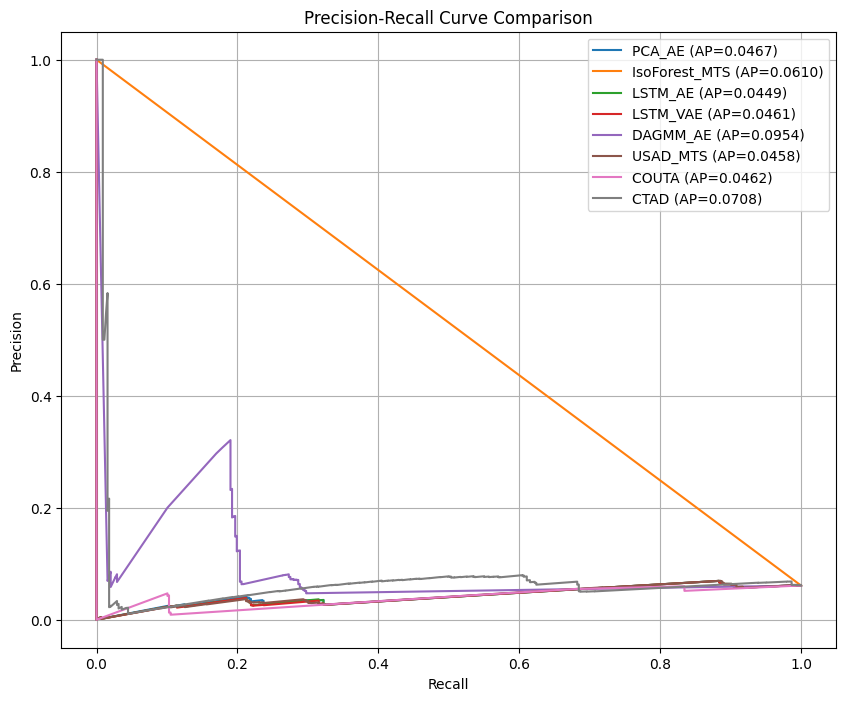

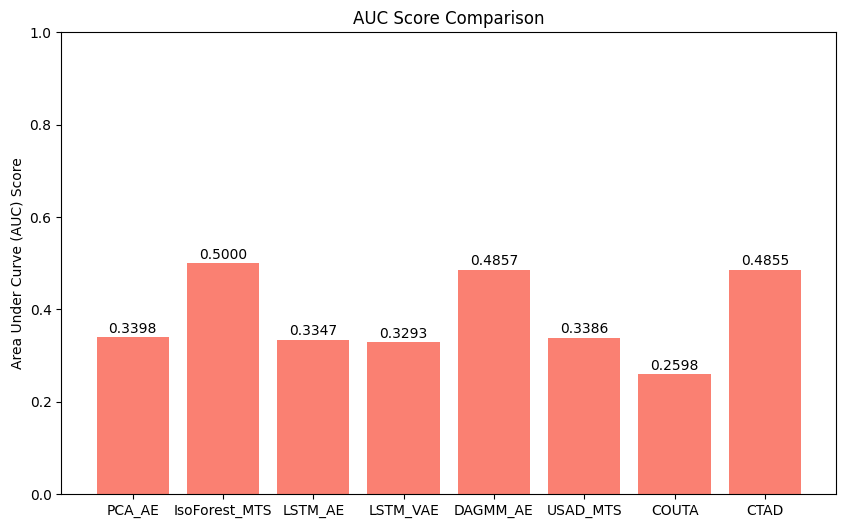

	 Rover T - Number 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.075935 | Val Loss: 0.069060
Epoch 2
	 Train Loss: 0.071335 | Val Loss: 0.064733
Epoch 3
	 Train Loss: 0.067307 | Val Loss: 0.060962
Epoch 4
	 Train Loss: 0.063560 | Val Loss: 0.056045
Epoch 5
	 Train Loss: 0.055953 | Val Loss: 0.046751
Epoch 6
	 Train Loss: 0.050268 | Val Loss: 0.042351
Epoch 7
	 Train Loss: 0.045609 | Val Loss: 0.034227
Epoch 8
	 Train Loss: 0.034051 | Val Loss: 0.023537
Epoch 9
	 Train Loss: 0.027690 | Val Loss: 0.020302
Epoch 10
	 Train Loss: 0.025101 | Val Loss: 0.017068
Epoch 11
	 Train Loss: 0.023457 | Val Loss: 0.015963
Epoch 12
	 Train Loss: 0.022110 | Val Loss: 0.015029
Epoch 13
	 Train Loss: 0.021117 | Val Loss: 0.014669
Epoch 14
	 Train Loss: 0.020437 | Val Loss: 0.013393
Epoch 15
	 Train Loss: 0.019711 | Val Loss: 0.013001
Epoch 16
	 Train Loss: 0.019228 | Val Loss: 0.012520
Epoch 17
	 Train Loss: 0.018760 | Val Loss: 0.012776
Epoch 18
	 Train Loss:

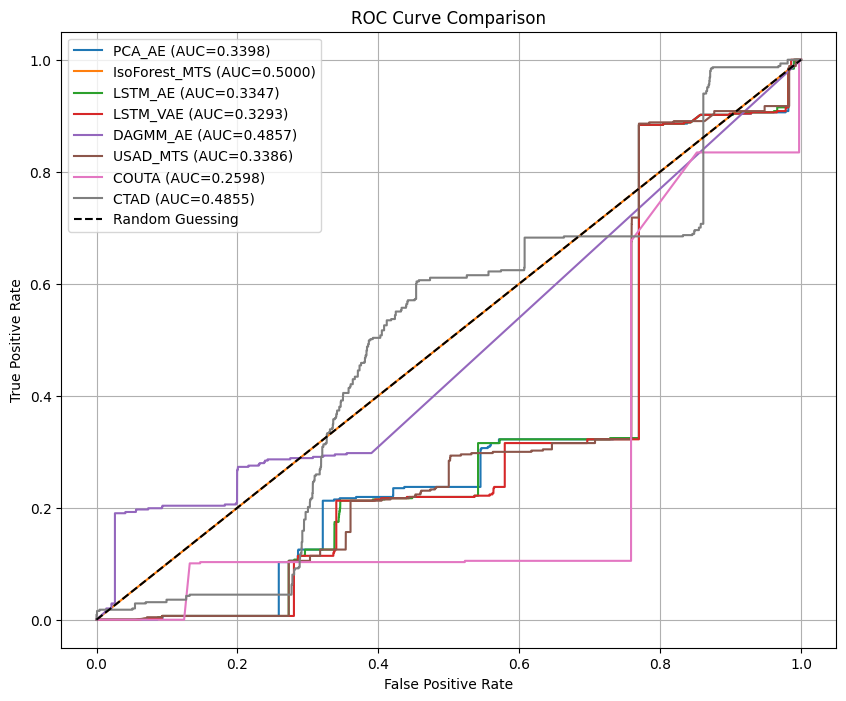

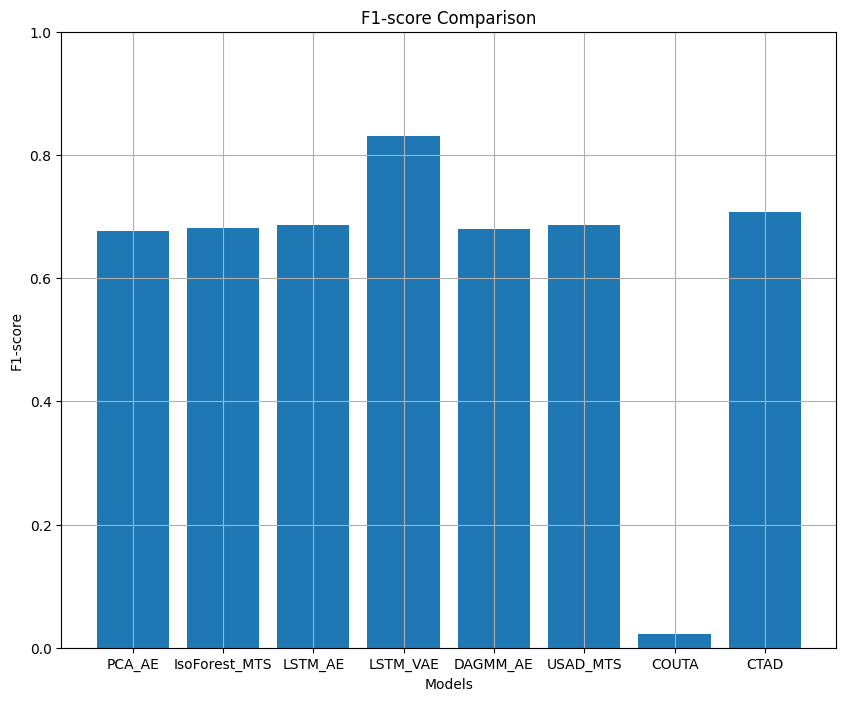

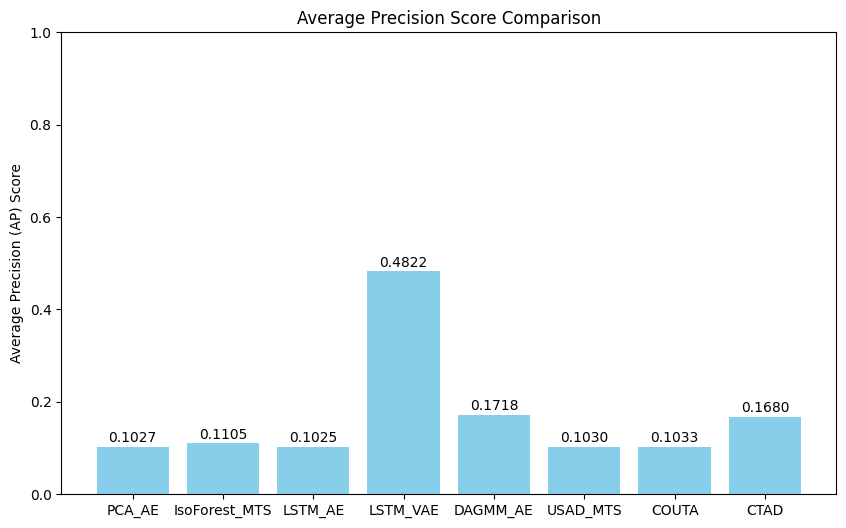

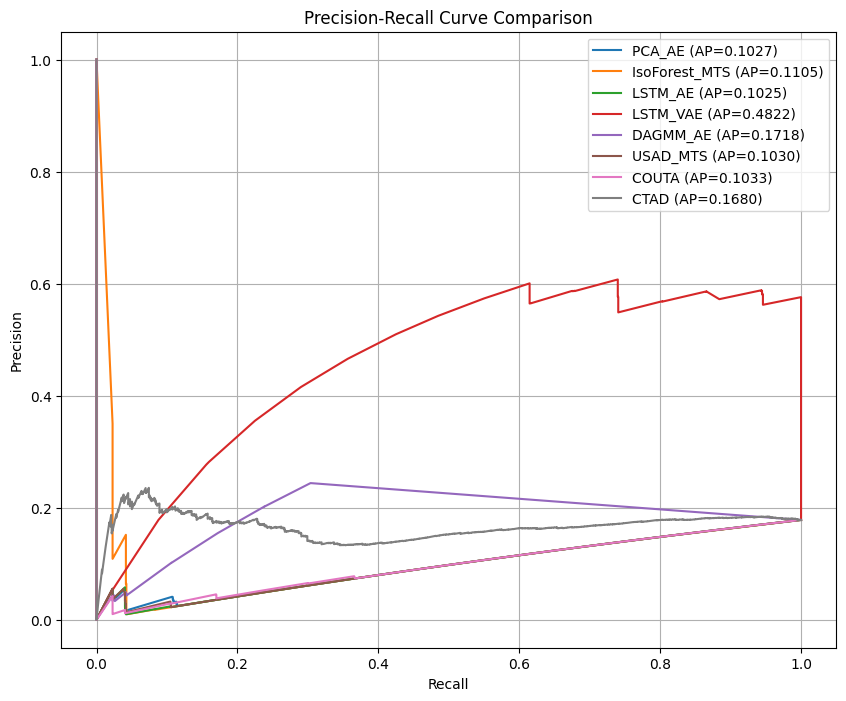

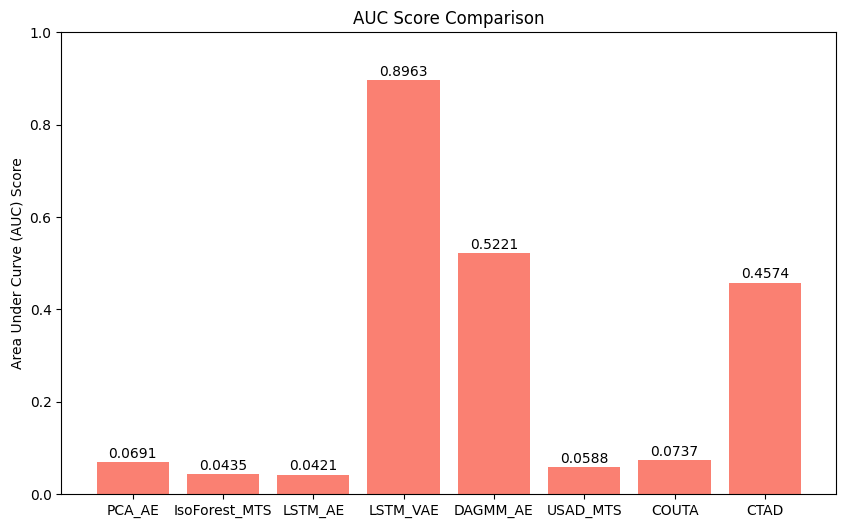

	 Rover T - Number 2
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.641419 | Val Loss: 0.071353
Epoch 2
	 Train Loss: 0.624095 | Val Loss: 0.068291
Epoch 3
	 Train Loss: 0.599892 | Val Loss: 0.065147
Epoch 4
	 Train Loss: 0.595016 | Val Loss: 0.062663
Epoch 5
	 Train Loss: 0.604079 | Val Loss: 0.060485
Epoch 6
	 Train Loss: 0.611438 | Val Loss: 0.058589
Epoch 7
	 Train Loss: 0.601505 | Val Loss: 0.056971
Epoch 8
	 Train Loss: 0.598242 | Val Loss: 0.055491
Epoch 9
	 Train Loss: 0.612918 | Val Loss: 0.054197
Epoch 10
	 Train Loss: 0.586398 | Val Loss: 0.053116
Epoch 11
	 Train Loss: 0.605153 | Val Loss: 0.052124
Epoch 12
	 Train Loss: 0.595652 | Val Loss: 0.051289
Epoch 13
	 Train Loss: 0.586697 | Val Loss: 0.050578
Epoch 14
	 Train Loss: 0.580079 | Val Loss: 0.050002
Epoch 15
	 Train Loss: 0.592312 | Val Loss: 0.049401
Epoch 16
	 Train Loss: 0.614571 | Val Loss: 0.048951
Epoch 17
	 Train Loss: 0.585205 | Val Loss: 0.048579
Epoch 18
	 Train Loss:

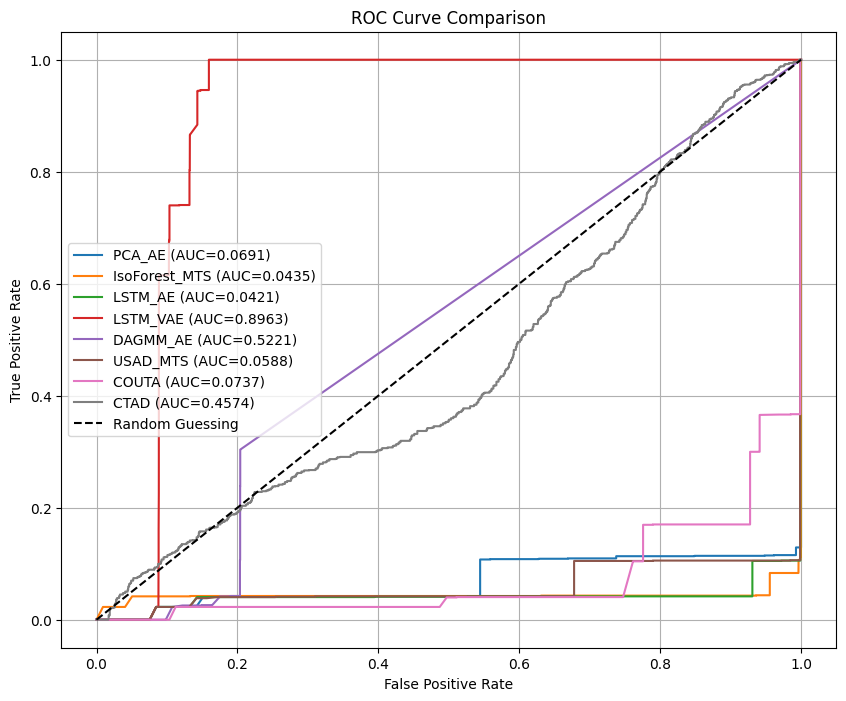

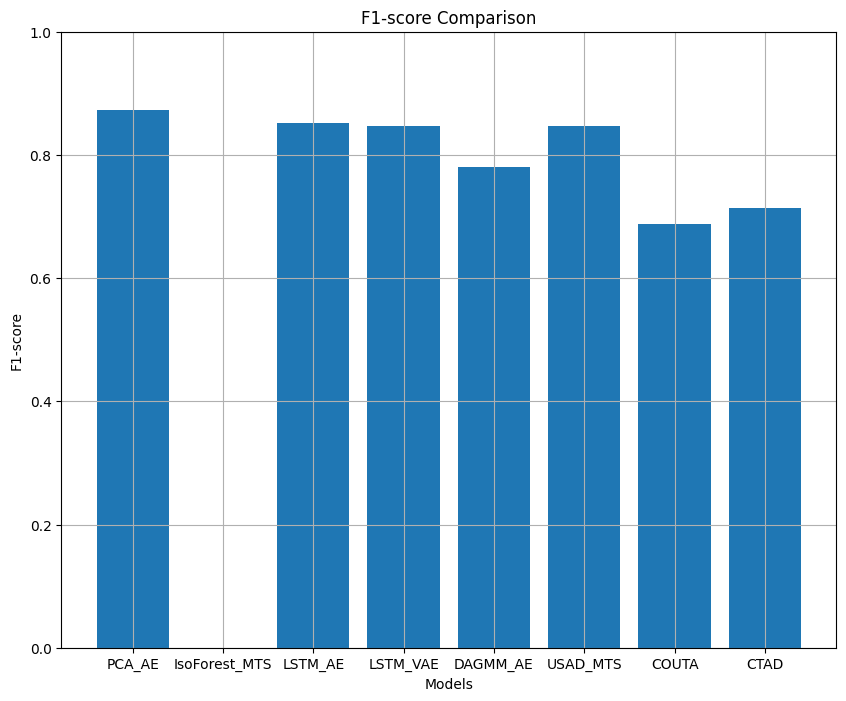

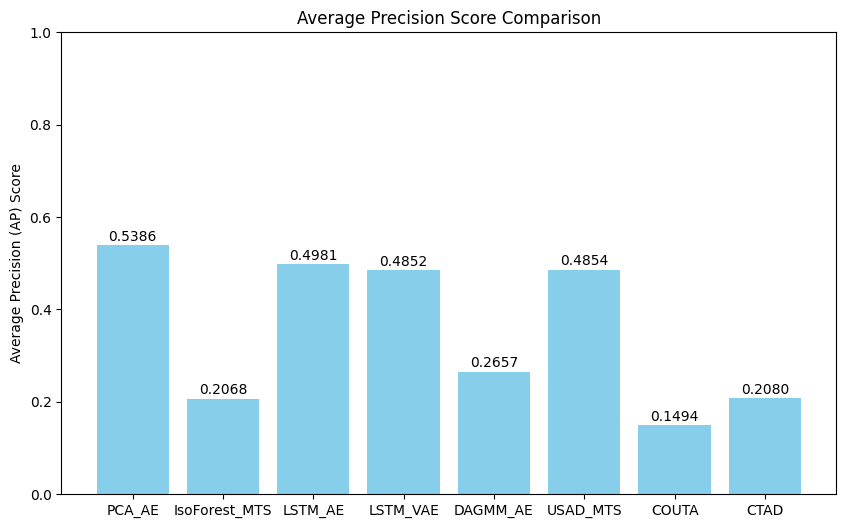

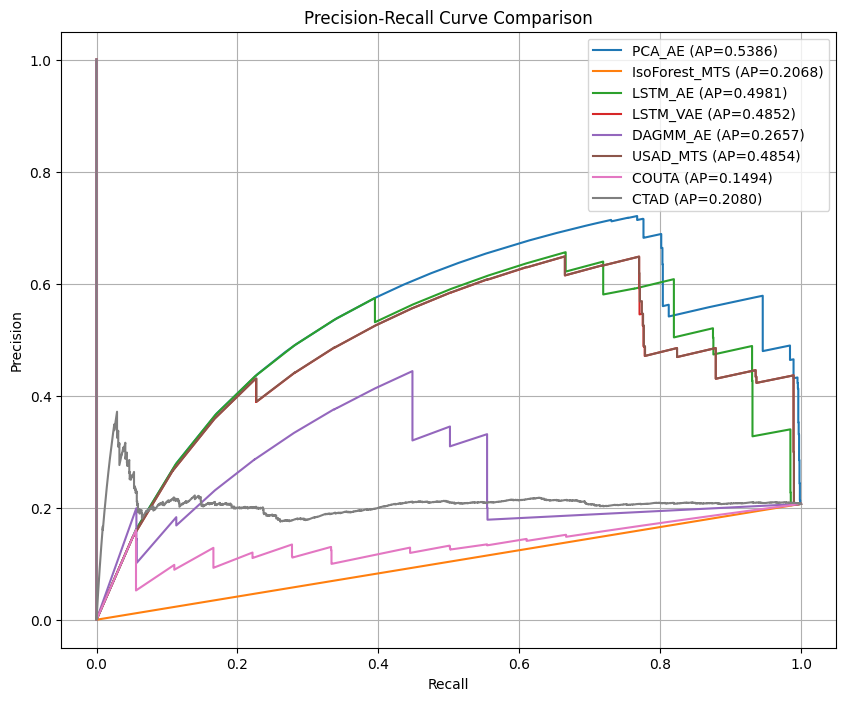

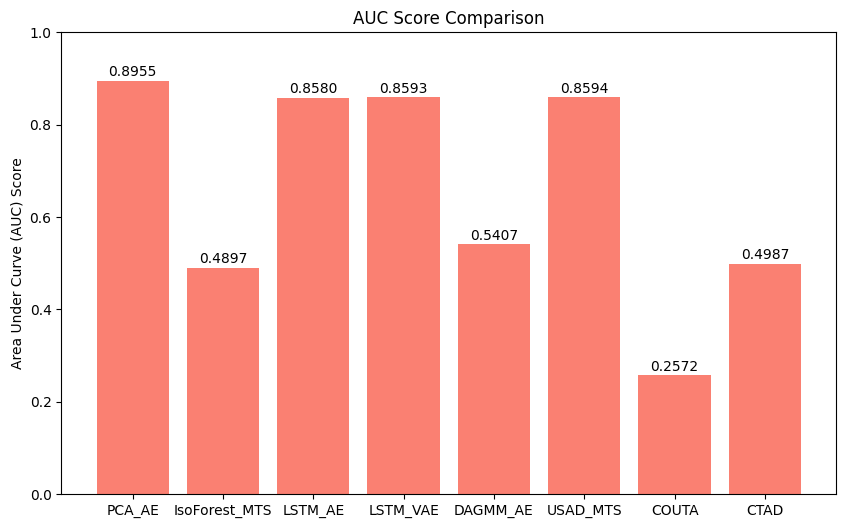

Testing models on WADI dataset:
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.487857 | Val Loss: 0.499591
Epoch 2
	 Train Loss: 0.377394 | Val Loss: 0.459425
Epoch 3
	 Train Loss: 0.344079 | Val Loss: 0.438067
Epoch 4
	 Train Loss: 0.320328 | Val Loss: 0.412439
Epoch 5
	 Train Loss: 0.298656 | Val Loss: 0.393070
Epoch 6
	 Train Loss: 0.279476 | Val Loss: 0.375532
Epoch 7
	 Train Loss: 0.263556 | Val Loss: 0.358929
Epoch 8
	 Train Loss: 0.248821 | Val Loss: 0.344192
Epoch 9
	 Train Loss: 0.236702 | Val Loss: 0.330410
Epoch 10
	 Train Loss: 0.226845 | Val Loss: 0.319232
Epoch 11
	 Train Loss: 0.218779 | Val Loss: 0.311756
Epoch 12
	 Train Loss: 0.212154 | Val Loss: 0.304036
Epoch 13
	 Train Loss: 0.206500 | Val Loss: 0.298888
Epoch 14
	 Train Loss: 0.202063 | Val Loss: 0.294489
Epoch 15
	 Train Loss: 0.197000 | Val Loss: 0.290358
Epoch 16
	 Train Loss: 0.193531 | Val Loss: 0.286106
Epoch 17
	 Train Loss: 0.190013 | Val Loss: 0.283658
Epoch 18
	 

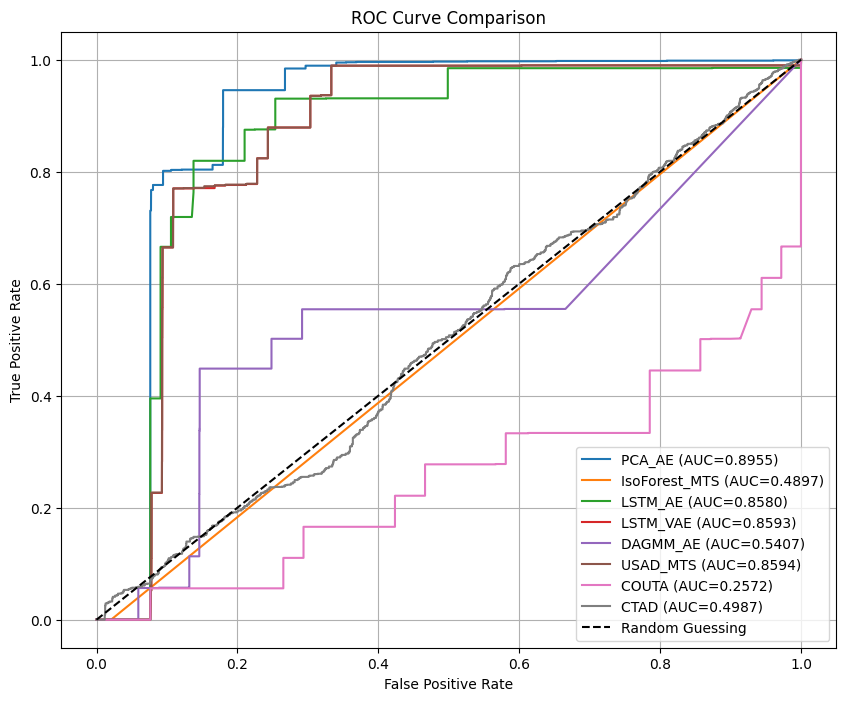

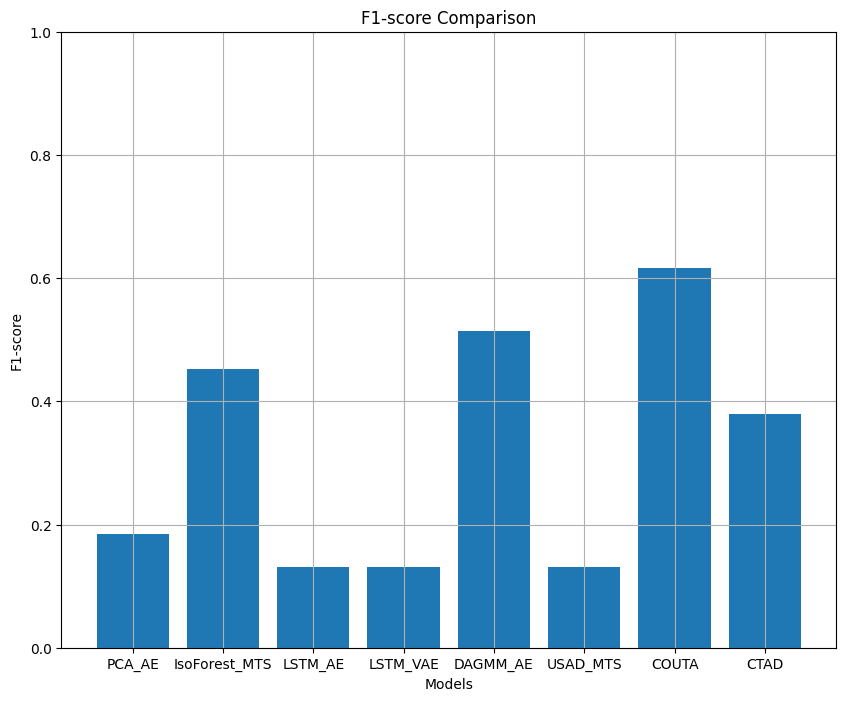

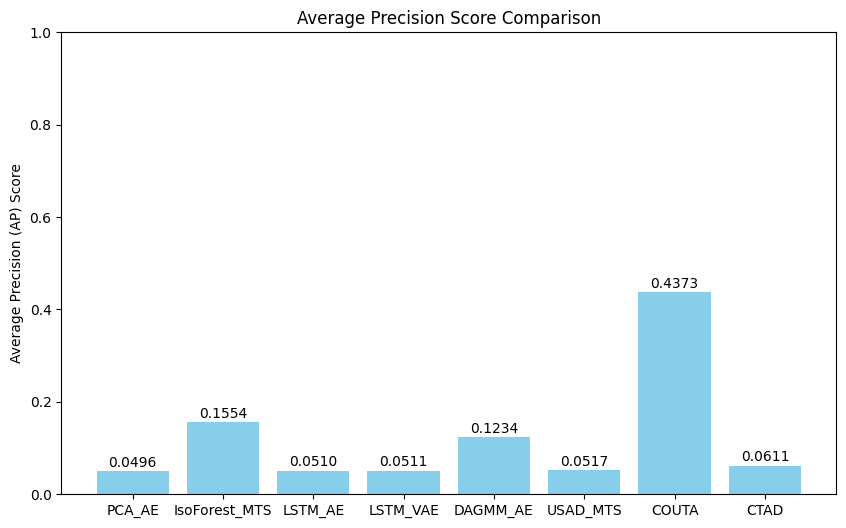

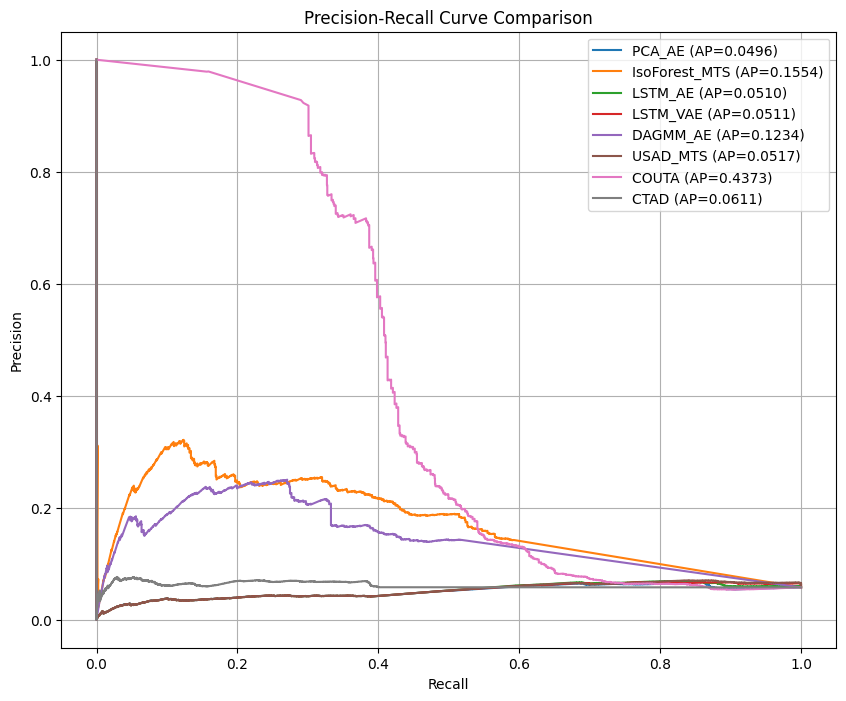

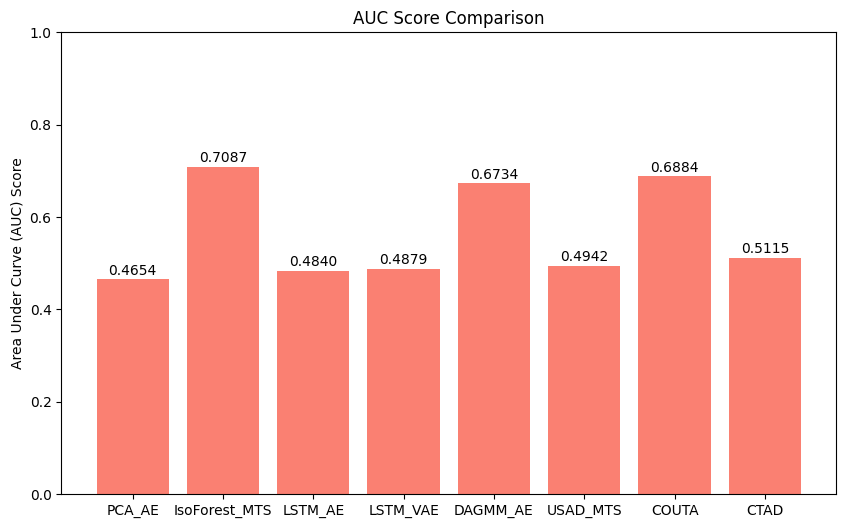

Average F1 Scores for SMD dataset:
	 PCA_AE : 0.4612
	 IsoForest_MTS : 0.3811
	 LSTM_AE : 0.4371
	 LSTM_VAE : 0.4789
	 DAGMM_AE : 0.3033
	 USAD_MTS : 0.4697
	 COUTA : 0.3967
	 CTAD : 0.4290
Average F1 Scores for PSM dataset:
	 PCA_AE : 0.7554
	 IsoForest_MTS : 0.8151
	 LSTM_AE : 0.7423
	 LSTM_VAE : 0.7520
	 DAGMM_AE : 0.9004
	 USAD_MTS : 0.7469
	 COUTA : 0.7356
	 CTAD : 0.7328
Average F1 Scores for SMAP_MSL dataset:
	 PCA_AE : 0.3664
	 IsoForest_MTS : 0.1121
	 LSTM_AE : 0.3661
	 LSTM_VAE : 0.3787
	 DAGMM_AE : 0.3894
	 USAD_MTS : 0.3652
	 COUTA : 0.4004
	 CTAD : 0.5593
Average F1 Scores for WADI dataset:
	 PCA_AE : 0.1846
	 IsoForest_MTS : 0.4524
	 LSTM_AE : 0.1307
	 LSTM_VAE : 0.1307
	 DAGMM_AE : 0.5138
	 USAD_MTS : 0.1307
	 COUTA : 0.6158
	 CTAD : 0.3791
Average ROC-AUC Scores for SMD dataset:
	 PCA_AE : 0.8759
	 IsoForest_MTS : 0.7061
	 LSTM_AE : 0.8979
	 LSTM_VAE : 0.8830
	 DAGMM_AE : 0.7172
	 USAD_MTS : 0.8966
	 COUTA : 0.8289
	 CTAD : 0.8142
Average ROC-AUC Scores for PSM dataset:

'Model Comparisons - Point Adjusted'

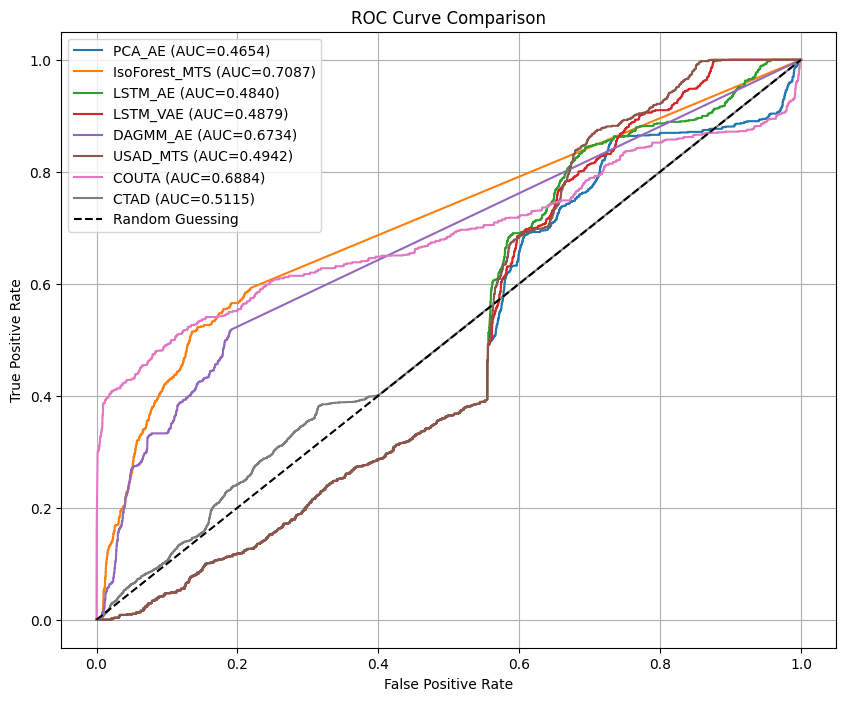

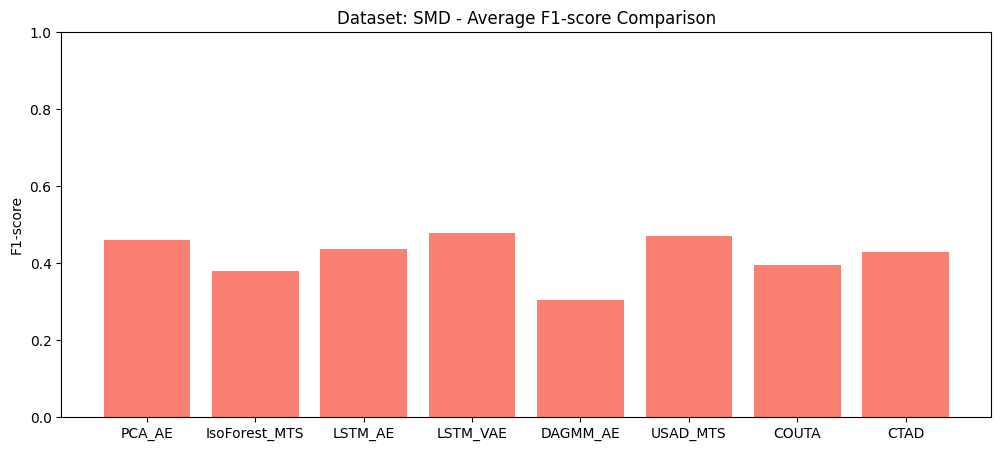

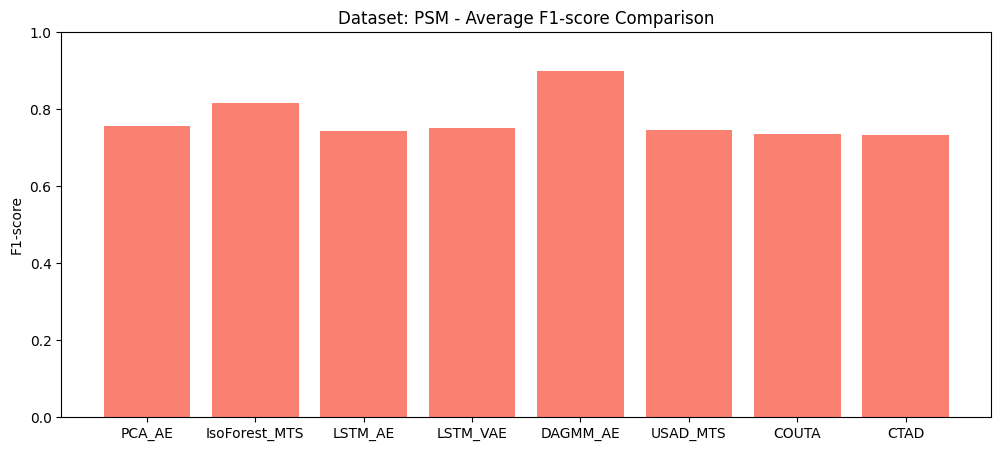

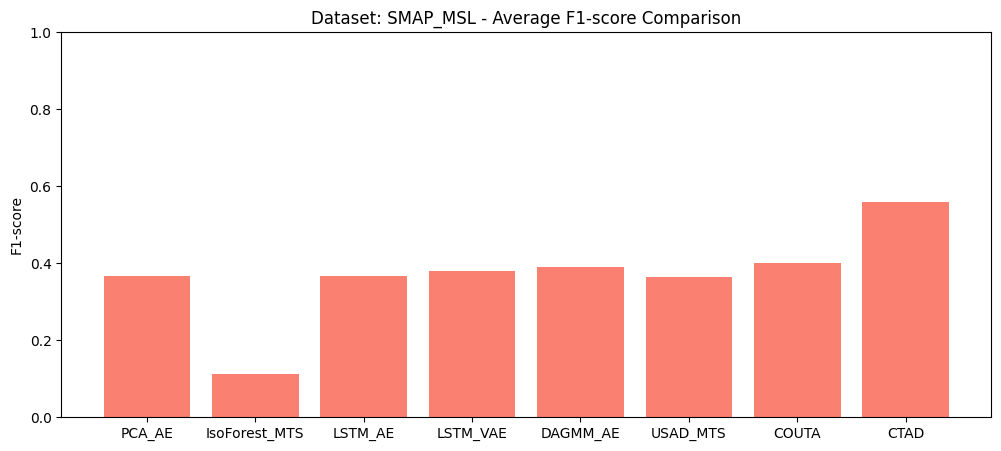

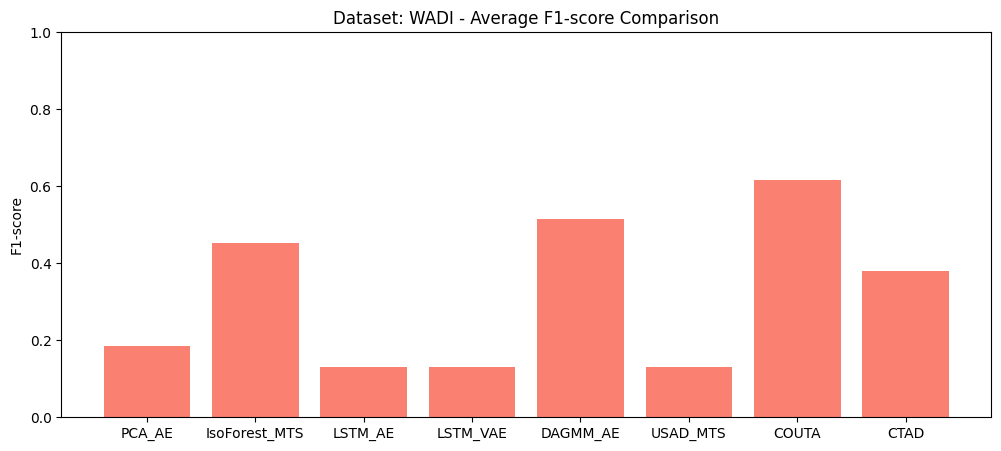

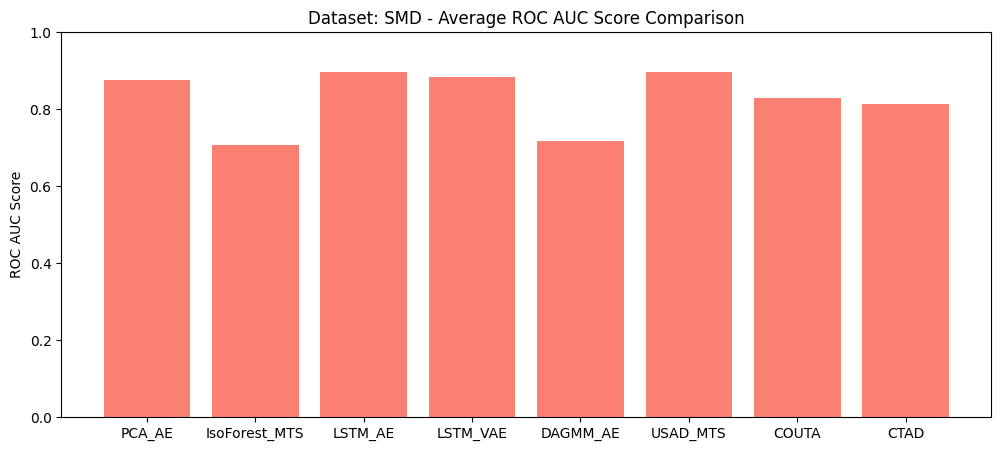

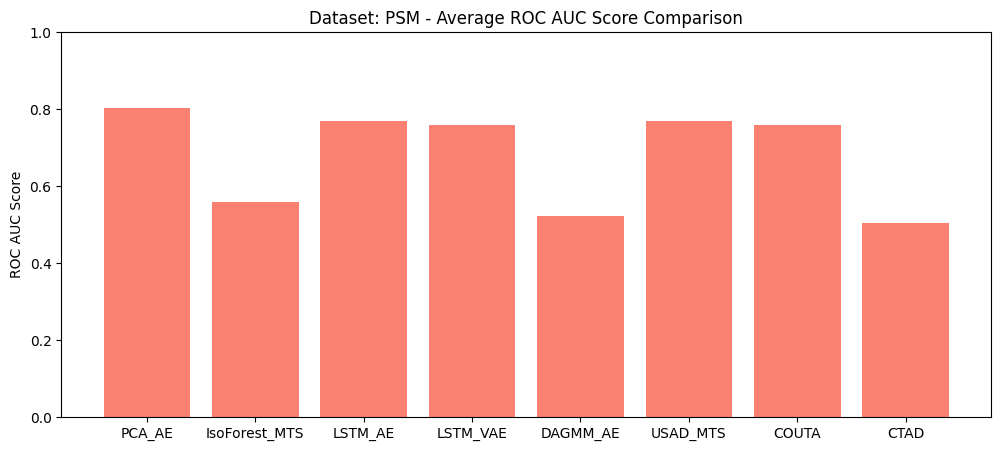

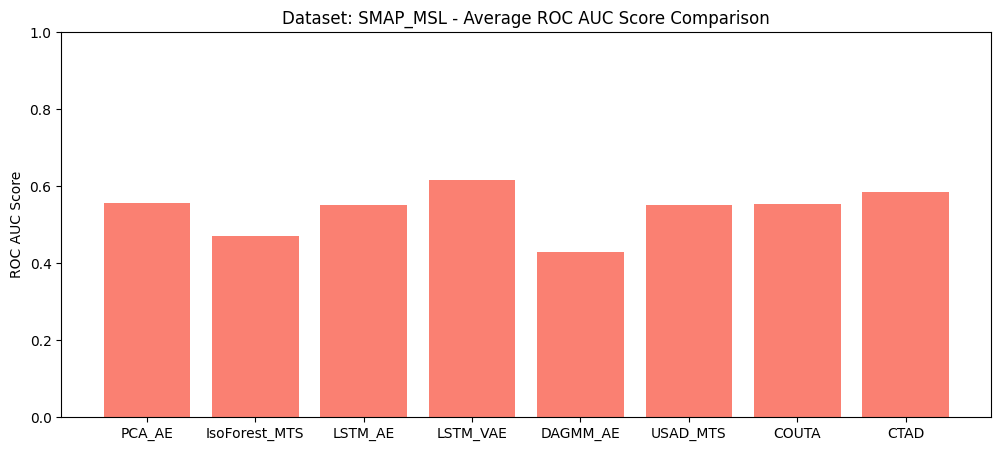

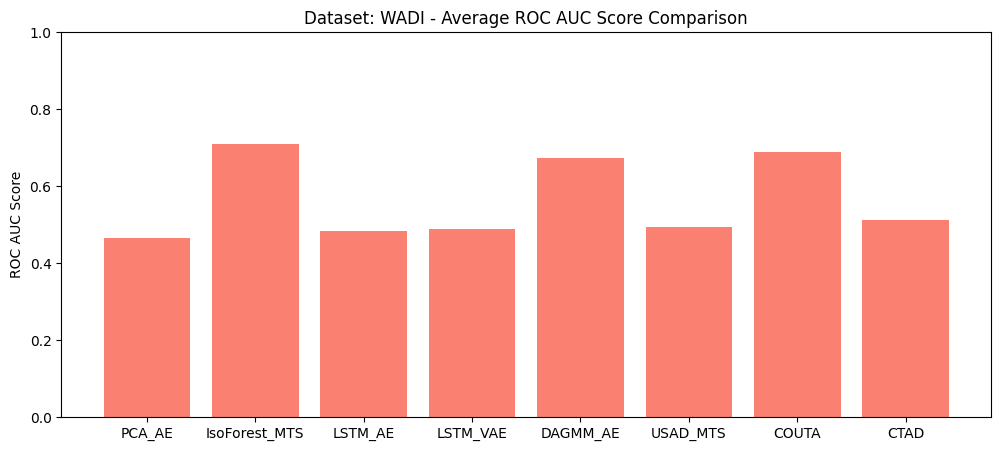

In [16]:
tf.keras.backend.clear_session() 
""" run_results(use_timestamp_level=False, use_point_adjust=False, verbose=1)
shutil.copytree('Model Comparisons', 'Model Comparisons - Window_score', dirs_exist_ok=True)
tf.keras.backend.clear_session()

run_results(use_timestamp_level=True, use_point_adjust=False, verbose=1)
shutil.copytree('Model Comparisons', 'Model Comparisons - Timestamp Score', dirs_exist_ok=True)
tf.keras.backend.clear_session() """

run_results(use_timestamp_level=True, use_point_adjust=True, verbose=1)
shutil.copytree('Model Comparisons', 'Model Comparisons - Point Adjusted', dirs_exist_ok=True)